### **Organizando os gráficos da seção de resultados**

1. Análise dos tópicos e toxicidade
2. Análise de difusão
3. Análise temporal

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import spearmanr

In [4]:
path = "data/macrotopics_pred.csv"
df_all = pd.read_csv(path)
df_all.head()

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,occurrences,toxicity,severe_toxicity,...,perspective_insult,perspective_severe_toxicity,perspective_obscene,perspective_toxicity,perspective_identity_attack,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count
0,jEKzQV5oajY,travel migrant scrap minute,Joe Marsh,2024-04-10T15:05:37Z,1057.0,152.0,32.0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",0.000659,0.000117,...,0.206683,0.021936,0.138744,0.360951,0.367026,0.038566,Others,0.000000,1.0,1
1,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,"[{'id': 60799, 'folder': 'channel_1466271872',...",0.295000,0.001137,...,0.021224,0.005379,0.008414,0.123468,0.049762,0.029415,Religion,0.000000,1.0,1
2,uaozGpSc4nc,putin layer february tucker carlson stand onio...,The Mosaic Ark,2024-02-22T07:30:05Z,330.0,8.0,6.0,"[{'id': 40486, 'folder': 'channel_1235978663',...",0.001735,0.000102,...,0.132458,0.010376,0.003292,0.229804,0.062040,0.033386,Others,0.021935,1.0,4
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,"[{'id': 449843, 'folder': 'channel_1571505334'...",0.002710,0.000104,...,0.019419,0.005112,0.001093,0.075294,0.017666,0.022509,Religion,0.005000,2.0,5
4,AKU0RokegSo,angeles rain studio city evacuate mudslide atm...,FOX 11 Los Angeles,2024-02-06T01:45:29Z,60863.0,406.0,152.0,"[{'id': 104116, 'folder': 'channel_1438734111'...",0.001515,0.000100,...,0.027841,0.004921,0.002368,0.111507,0.019375,0.028207,Environment,0.000000,2.0,2


In [ ]:
import ast
import numpy as np 

num_nulls = 0

def safe_literal_eval(value):
    global num_nulls
    if pd.isna(value):
        num_nulls += 1
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, TypeError, AttributeError):
        return []

df_all['occurrences'] = df_all['occurrences'].apply(safe_literal_eval)
print("Número de valores NaN em 'occurrences':", num_nulls)

In [ ]:
def calculate_lifetime(occurrence_list):
    dates = [item.get('date') for item in occurrence_list if item.get('date')]
    
    if not dates:
        return None 
    
    datetime_dates = pd.to_datetime(dates)
    min_date = datetime_dates.min()
    max_date = datetime_dates.max()

    if min_date == max_date:
        return 1
    
    diff_days = (max_date - min_date).days + 1 
    return diff_days


df_all['lifetime'] = df_all['occurrences'].apply(calculate_lifetime)
display(df_all[['occurrences', 'lifetime']].head())

,occurrences,lifetime
0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",1.0
1,"[{'id': 60799, 'folder': 'channel_1466271872',...",1.0
2,"[{'id': 40486, 'folder': 'channel_1235978663',...",1.0
3,"[{'id': 449843, 'folder': 'channel_1571505334'...",2.0
4,"[{'id': 104116, 'folder': 'channel_1438734111'...",2.0


In [ ]:
def contar_envios(valor):
    try:
        if isinstance(valor, list):
            return len(valor)
        
        if isinstance(valor, str):
            lista_real = ast.literal_eval(valor)
            return len(lista_real)
            
        return None 
    except:
        return None

df_all['send_count'] = df_all['occurrences'].apply(contar_envios)
df_all[['occurrences', 'send_count']].head()

,occurrences,send_count
0,"[{'id': 1416, 'folder': 'channel_1556142220', ...",1
1,"[{'id': 60799, 'folder': 'channel_1466271872',...",1
2,"[{'id': 40486, 'folder': 'channel_1235978663',...",4
3,"[{'id': 449843, 'folder': 'channel_1571505334'...",5
4,"[{'id': 104116, 'folder': 'channel_1438734111'...",2


In [ ]:
def calculate_transfer_time(row):
    occurrences = row['occurrences']

    if not occurrences:
        return None

    first_appearance_str = min(occurrences, key=lambda x: x['date'])['date']

    first_date = pd.to_datetime(first_appearance_str).tz_localize(None)
    published_at = pd.to_datetime(row['published_at']).tz_localize(None)

    diff = (first_date - published_at).days
    return max(0, diff)

df_all['transfer_time'] = df_all.apply(calculate_transfer_time, axis=1)
df_all['first_appearance'] = df_all['occurrences'].apply(lambda occ: min(occ, key=lambda x: x['date'])['date'] if occ else None)

In [ ]:
df_all.to_parquet("data/not_27.parquet", index=False)

In [ ]:
tox_cols = [
    'perspective_toxicity',
    'perspective_severe_toxicity',
    'perspective_insult',
    'perspective_obscene',
    'perspective_threat',
    'perspective_identity_attack'
]

In [ ]:
politics = ['American Politics', 'War', 'Foreign Policy', 'Crime, S and J']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

palette_map = {}

for topic in politics:
    palette_map[topic] = 'orange' 
    
for topic in non_politics:
    palette_map[topic] = 'Blue' 

interest = [
    'War',
    'American Politics',
    'Foreign Policy',
    'Crime, S and J',
    'Health',
    'Religion',
    'Hobbies'
    ,"Technology"
    ,"Environment"
    ,"Entertainment"
]

macro_colors = {
    "American Politics":             "#6AF5FF",
    "Foreign Policy":              "#76FF7F",
    "Crime, S and J:     "#FF66CC",
    "Health":                  "#522222",
    "Hobbies":       "#DA0000",
    "Religion":                       "#962EAA",
    "War":                         "#5C5C61"
    , "Technology": "#890082"
    , "Environment": "#008000"
    , "Entertainment": "#FFD700"
}

df = df_all[df_all["macrotopic_pred"].isin(interest)]
len(df)

418619

In [ ]:
"""
import numpy as np
import matplotlib.pyplot as plt

macro_colors = {
    "American Politics":             "#5FD6DE",  # era #6AF5FF
    "Foreign Policy":               "#4CBD71",  # era #76FF7F
    "Crime, Security and Justice":   "#F07AA8",  # era #FF66CC
    "Health":                       "#6A3A3A",  # era #522222
    "Hobbies":                      "#C43A3A",  # era #DA0000
    "Religion":                     "#8E5FA6",  # era #962EAA
    "War":                          "#6B6F78"   # era #5C5C61
    #, "Technology": "#7A0078"      # versão mais suave do #890082
    #, "Environment": "#2F8F4E"     # versão mais suave do #008000
    #, "Entertainment": "#E6C24A"   # versão mais suave do #FFD700
}

politics = ['American Politics', 'War', 'Foreign Policy', 'Crime, Security and Justice']
non_politics = ['Health', 'Hobbies', 'Religion', 'Entertainment', 'Technology', 'Environment']

toxicity_mean = df_all.groupby('macrotopic_pred')['perspective_toxicity'].mean()

# ordena do mais tóxico → menos tóxico
politics_sorted = sorted(politics, key=lambda g: toxicity_mean.get(g, 0), reverse=True)
non_politics_sorted = sorted(non_politics, key=lambda g: toxicity_mean.get(g, 0), reverse=True)

# colormaps bons e bem separados
cmap_pol = plt.get_cmap("Oranges")
cmap_non = plt.get_cmap("Blues")

# mais tóxico → cor mais forte
norm_pol = np.linspace(0.85, 0.35, len(politics_sorted))
norm_non = np.linspace(0.85, 0.35, len(non_politics_sorted))

macro_colors = {}

for g, n in zip(politics_sorted, norm_pol):
    macro_colors[g] = cmap_pol(n)

for g, n in zip(non_politics_sorted, norm_non):
    macro_colors[g] = cmap_non(n)
"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\n\nmacro_colors = {\n    "American Politics":             "#5FD6DE",  # era #6AF5FF\n    "Foreign Policy":               "#4CBD71",  # era #76FF7F\n    "Crime, Security and Justice":   "#F07AA8",  # era #FF66CC\n    "Health":                       "#6A3A3A",  # era #522222\n    "Hobbies":                      "#C43A3A",  # era #DA0000\n    "Religion":                     "#8E5FA6",  # era #962EAA\n    "War":                          "#6B6F78"   # era #5C5C61\n    #, "Technology": "#7A0078"      # versão mais suave do #890082\n    #, "Environment": "#2F8F4E"     # versão mais suave do #008000\n    #, "Entertainment": "#E6C24A"   # versão mais suave do #FFD700\n}\n\npolitics = [\'American Politics\', \'War\', \'Foreign Policy\', \'Crime, Security and Justice\']\nnon_politics = [\'Health\', \'Hobbies\', \'Religion\', \'Entertainment\', \'Technology\', \'Environment\']\n\ntoxicity_mean = df_all.groupby(\'macrotopic_pred\')[\'perspectiv

In [ ]:
df_exploded = df.explode('occurrences').reset_index(drop=True)
df_normalized = pd.json_normalize(df_exploded['occurrences'])
df_complete = pd.concat([
    df_exploded.drop(columns=['occurrences']), 
    df_normalized
], axis=1)
display(df_complete.head())

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,toxicity,severe_toxicity,obscene,...,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance,id,folder,date
0,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,0.29500,0.001137,0.003694,...,0.029415,Religion,0.000,1.0,1,79.0,2024-01-06,60799.0,channel_1466271872,2024-01-06
1,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,449843.0,channel_1571505334,2024-10-27
2,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,205296.0,channel_1366456452,2024-10-28
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,123625.0,channel_2091154967,2024-10-27
4,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.00271,0.000104,0.000254,...,0.022509,Religion,0.005,2.0,5,0.0,2024-10-27,462353.0,channel_1548295614,2024-10-27


___
## **RQ1 Analisando características de cada tópico**

In [12]:
import matplotlib.font_manager as fm

[f.name for f in fm.fontManager.ttflist if "Courier" in f.name]

[]

In [12]:
plt.rcParams.update({
    'font.family': 'Courier New',  
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20
}) 

sns.set_theme(
    style="white",
    font="Courier New"
)

In [13]:
df_all['macrotopic_pred'] = ['Crime, S and J' if topic == 'Crime, Security and Justice' else topic for topic in df_all['macrotopic_pred']]

findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Fon

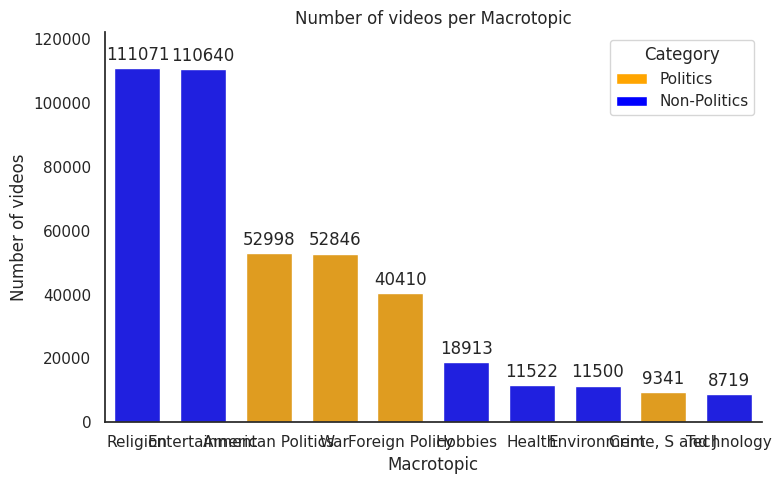

In [14]:
from matplotlib.patches import Patch

topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x='macrotopic_pred',
    y='count',
    hue='macrotopic_pred',
    data=topic_count,
    palette=palette_map,
    width=0.7,
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

sns.despine()

plt.title('Number of videos per Macrotopic')
plt.xlabel('Macrotopic')
plt.ylabel('Number of videos')

plt.xticks()
plt.yticks()

plt.ylim(0, topic_count['count'].max() * 1.1)

legend_elements = [
    Patch(facecolor='orange', label='Politics'),
    Patch(facecolor='blue',   label='Non-Politics'),
]

plt.legend(handles=legend_elements, title='Category', loc='upper right')

plt.tight_layout()
plt.savefig("gráficos/num_videos_per_macrotopic.svg", format='svg')
plt.show()

/tmp/ipykernel_982436/2704303025.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


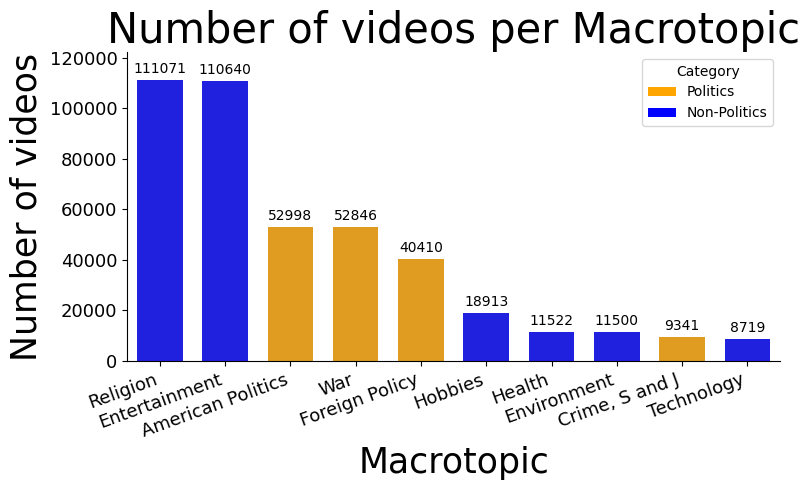

In [29]:
from matplotlib.patches import Patch

topic_count = df_all['macrotopic_pred'].value_counts().reset_index()
topic_count = topic_count[topic_count['macrotopic_pred'] != 'Others']

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x = 'macrotopic_pred',
    y = 'count',
    data = topic_count,
    palette = palette_map,
    width=0.7
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

sns.despine()

plt.title('Number of videos per Macrotopic', fontsize=titles["fontsize"])
plt.xlabel('Macrotopic',fontsize=xlabels["fontsize"])    
plt.ylabel('Number of videos',fontsize=ylabels["fontsize"])
plt.xticks(rotation=xticks["rotation"], ha='right', fontsize=xticks["fontsize"])
plt.yticks(fontsize=yticks["fontsize"]) 
plt.ylim(0, topic_count['count'].max() * 1.1) 
ax.tick_params(labelsize=13)

legend_elements = [
    Patch(facecolor='orange', label='Politics'),
    Patch(facecolor='blue',   label='Non-Politics'),
]

plt.legend(handles=legend_elements, title='Category', loc='upper right')

plt.tight_layout()
plt.savefig("gráficos/num_videos_per_macrotopic")
plt.show()

### ignore

In [12]:
import pandas as pd

# --- 1. Filtrar 'Others' e Calcular (Usando df_all) ---
# Cria uma cópia apenas com o que interessa (sem Others)
df_final = df_all[df_all['macrotopic_pred'] != 'Others'].copy()

df_mean = df_final.groupby('macrotopic_pred')[tox_cols].mean()
df_std  = df_final.groupby('macrotopic_pred')[tox_cols].std()

# Ordenar por toxicidade decrescente
df_mean = df_mean.sort_values(by='perspective_toxicity', ascending=False)
df_std = df_std.reindex(df_mean.index)

# Formatar "Média ± Desvio"
df_tabela = df_mean.round(3).astype(str) + " ± " + df_std.round(3).astype(str)

# Limpeza dos Nomes
df_tabela.index = df_tabela.index.str.replace('_', ' ').str.capitalize()
df_tabela.columns = [c.replace('perspective_', '').replace('_', ' ').capitalize() for c in df_tabela.columns]

# --- 2. Listas de Cores ---

politicos = [
    'American politics', 
    'War', 
    'Foreign policy', 
    'Crime, security and justice'
]

nao_politicos = [
    'Health', 
    'Hobbies', 
    'Religion', 
    'Entertainment', 
    'Technology',            
    'Science and technology', 
    'Environment'
]

def colorir_fundo_index(valor):
    if valor in politicos:
        return 'background-color: #2ca02c; color: white; font-weight: bold;' # Verde
    elif valor in nao_politicos:
        return 'background-color: #1f77b4; color: white; font-weight: bold;' # Azul
    return ''

# --- 3. Estilo ---
styled_table = (df_tabela.style
    .set_caption("Média e Desvio Padrão da Toxicidade (Base Completa)")
    .map_index(colorir_fundo_index, axis=0)
    .set_properties(**{
        'background-color': 'white',  
        'color': 'black',             
        'border-color': '#d3d3d3',    
        'text-align': 'center',
        'padding': '8px'
    })
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [
            ('background-color', '#1f77b4'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]},
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}
    ])
)

display(styled_table)

,Toxicity,Severe toxicity,Insult,Obscene,Threat,Identity attack
macrotopic_pred,,,,,,
"Crime, security and justice",0.1 ± 0.13,0.082 ± 0.12,0.09 ± 0.124,0.088 ± 0.127,0.084 ± 0.121,0.092 ± 0.123
War,0.098 ± 0.118,0.084 ± 0.114,0.085 ± 0.111,0.086 ± 0.117,0.088 ± 0.114,0.097 ± 0.119
American politics,0.068 ± 0.106,0.054 ± 0.097,0.063 ± 0.103,0.057 ± 0.103,0.056 ± 0.097,0.059 ± 0.099
Entertainment,0.066 ± 0.126,0.056 ± 0.122,0.062 ± 0.127,0.064 ± 0.134,0.056 ± 0.119,0.058 ± 0.121
Religion,0.055 ± 0.097,0.046 ± 0.092,0.049 ± 0.092,0.049 ± 0.095,0.046 ± 0.09,0.051 ± 0.094
Foreign policy,0.052 ± 0.089,0.043 ± 0.084,0.047 ± 0.085,0.046 ± 0.087,0.045 ± 0.083,0.049 ± 0.087
Hobbies,0.046 ± 0.089,0.037 ± 0.083,0.043 ± 0.093,0.041 ± 0.091,0.037 ± 0.082,0.038 ± 0.081
Health,0.042 ± 0.076,0.031 ± 0.066,0.036 ± 0.068,0.033 ± 0.07,0.032 ± 0.066,0.035 ± 0.068
Environment,0.037 ± 0.064,0.029 ± 0.057,0.032 ± 0.059,0.03 ± 0.06,0.03 ± 0.056,0.031 ± 0.057


/tmp/ipykernel_1440655/3435390132.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


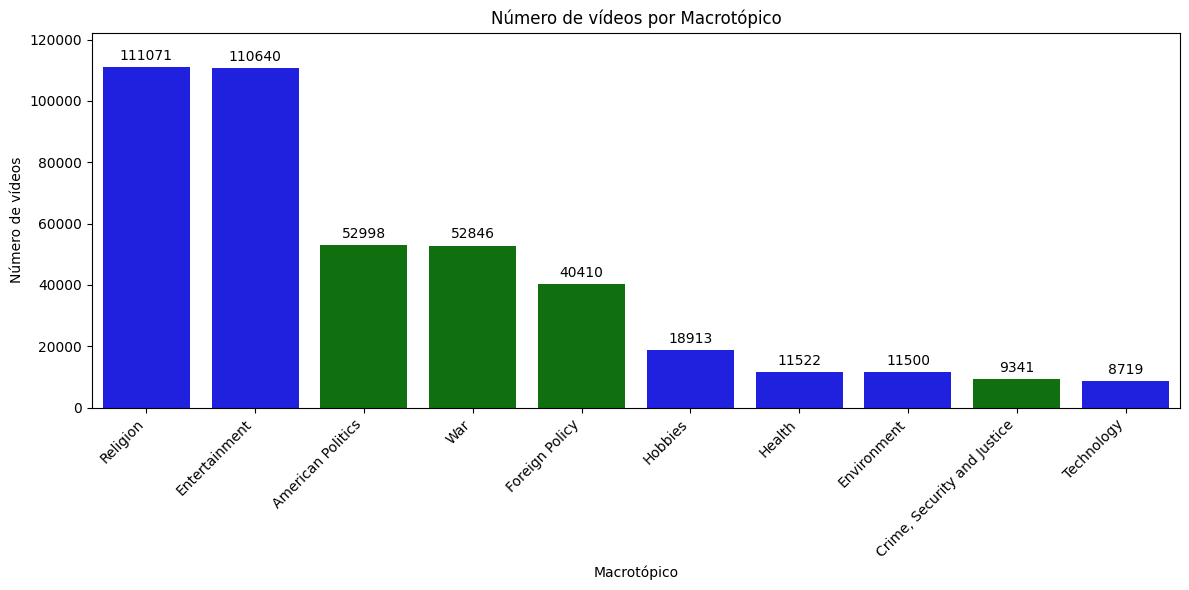

In [24]:
topic_count = df['macrotopic_pred'].value_counts().reset_index()
topic_count.columns = ['macrotopic_pred', 'count']

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x = 'macrotopic_pred',
    y = 'count',
    data = topic_count,
    palette = palette_map
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Número de vídeos por Macrotópico')
plt.xlabel('Macrotópico')
plt.ylabel('Número de vídeos')
plt.xticks(rotation=45, ha='right') 
plt.ylim(0, topic_count['count'].max() * 1.1) 

plt.tight_layout()
plt.show()


In [31]:
df_mean = df.groupby('macrotopic_pred')[tox_cols].mean()
df_std  = df.groupby('macrotopic_pred')[tox_cols].std()

df_tabela = df_mean.round(5).astype(str) + " ± " + df_std.round(5).astype(str)

df_tabela.index = (
    df_tabela.index
        .str.replace('perspective_', '')
        .str.replace('_', ' ')
        .str.capitalize()
)

display(df_tabela)

df_mean = df_mean.sort_values(by='perspective_toxicity', ascending=False)
df_std = df_std.reindex(df_mean.index)

df_tabela = df_mean.round(3).astype(str) + " ± " + df_std.round(3).astype(str)

df_tabela.index = df_tabela.index.str.replace('_', ' ').str.capitalize()
df_tabela.columns = [c.replace('perspective_', '').replace('_', ' ').capitalize() for c in df_tabela.columns]

styled_table = (df_tabela.style
    .set_caption("Média e Desvio Padrão da Toxicidade por Tópico")
    .background_gradient(axis=None, gmap=df_mean, cmap='YlOrRd') # Usa as médias para definir a cor de fundo
    .set_properties(**{
        'background-color': 'white',
        'color': 'black',
        'border-color': 'lightgrey',
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold')]}
    ])
)

display(styled_table)


,perspective_toxicity,perspective_severe_toxicity,perspective_insult,perspective_obscene,perspective_threat,perspective_identity_attack
macrotopic_pred,,,,,,
American politics,0.06823 ± 0.1058,0.05365 ± 0.09702,0.06258 ± 0.10263,0.05735 ± 0.10255,0.05557 ± 0.09733,0.05862 ± 0.09859
"Crime, security and justice",0.09987 ± 0.13034,0.08179 ± 0.11959,0.08968 ± 0.12409,0.08812 ± 0.12714,0.08356 ± 0.12115,0.09166 ± 0.12298
Entertainment,0.06635 ± 0.12645,0.05629 ± 0.12173,0.06209 ± 0.12713,0.06408 ± 0.13408,0.05575 ± 0.11885,0.05836 ± 0.12128
Environment,0.03728 ± 0.06367,0.02888 ± 0.05706,0.03152 ± 0.05854,0.03042 ± 0.06,0.02969 ± 0.05613,0.03096 ± 0.05697
Foreign policy,0.05219 ± 0.08872,0.04344 ± 0.08438,0.04706 ± 0.08528,0.04573 ± 0.08742,0.04465 ± 0.08347,0.04876 ± 0.08745
Health,0.04227 ± 0.07555,0.03149 ± 0.06619,0.03559 ± 0.06777,0.03342 ± 0.07019,0.03231 ± 0.06607,0.03476 ± 0.06827
Hobbies,0.04587 ± 0.08856,0.03682 ± 0.08348,0.04251 ± 0.0934,0.04146 ± 0.09136,0.03715 ± 0.08219,0.03782 ± 0.0812
Religion,0.05535 ± 0.09679,0.04635 ± 0.09176,0.04894 ± 0.09218,0.04861 ± 0.09507,0.04595 ± 0.08957,0.05093 ± 0.09394
Technology,0.03576 ± 0.07889,0.02846 ± 0.06982,0.03264 ± 0.07696,0.03514 ± 0.08556,0.0277 ± 0.06641,0.02907 ± 0.07184


/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Toxicity,Severe toxicity,Insult,Obscene,Threat,Identity attack
macrotopic_pred,,,,,,
"Crime, security and justice",0.1 ± 0.13,0.082 ± 0.12,0.09 ± 0.124,0.088 ± 0.127,0.084 ± 0.121,0.092 ± 0.123
War,0.098 ± 0.118,0.084 ± 0.114,0.085 ± 0.111,0.086 ± 0.117,0.088 ± 0.114,0.097 ± 0.119
American politics,0.068 ± 0.106,0.054 ± 0.097,0.063 ± 0.103,0.057 ± 0.103,0.056 ± 0.097,0.059 ± 0.099
Entertainment,0.066 ± 0.126,0.056 ± 0.122,0.062 ± 0.127,0.064 ± 0.134,0.056 ± 0.119,0.058 ± 0.121
Religion,0.055 ± 0.097,0.046 ± 0.092,0.049 ± 0.092,0.049 ± 0.095,0.046 ± 0.09,0.051 ± 0.094
Foreign policy,0.052 ± 0.089,0.043 ± 0.084,0.047 ± 0.085,0.046 ± 0.087,0.045 ± 0.083,0.049 ± 0.087
Hobbies,0.046 ± 0.089,0.037 ± 0.083,0.043 ± 0.093,0.041 ± 0.091,0.037 ± 0.082,0.038 ± 0.081
Health,0.042 ± 0.076,0.031 ± 0.066,0.036 ± 0.068,0.033 ± 0.07,0.032 ± 0.066,0.035 ± 0.068
Environment,0.037 ± 0.064,0.029 ± 0.057,0.032 ± 0.059,0.03 ± 0.06,0.03 ± 0.056,0.031 ± 0.057


In [ ]:
from scipy import stats
import pandas as pd

print("--- RESULTADOS KRUSKAL-WALLIS (BLINDADO) ---\n")

for metric in tox_cols:
    # --- AQUI ESTÁ A CORREÇÃO ---
    # Adicionamos .dropna() para garantir que só entram números reais
    grupos = [
        df[df['macrotopic_pred'] == t][metric].dropna().values 
        for t in df['macrotopic_pred'].unique()
    ]
    
    # Remove grupos vazios (caso algum tópico não tenha dados para essa métrica)
    grupos = [g for g in grupos if len(g) > 0]

    # Verifica se sobraram pelo menos 2 grupos para comparar
    if len(grupos) < 2:
        print(f"⚠️ {metric}: Dados insuficientes para comparação.")
        continue

    stat, p_value = stats.kruskal(*grupos)

    print(f"📊 {metric}")
    print(f"   H: {stat:.4f}")
    print(f"   P-Valor: {p_value:.4g}")
    
    if p_value < 0.05:
        print("   ✅ Diferença Significativa encontrada!")
    else:
        print("   ❌ Sem diferença estatística.")
    print("-" * 30)

--- RESULTADOS KRUSKAL-WALLIS (BLINDADO) ---

📊 perspective_toxicity
   H: 17076.9765
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------
📊 perspective_severe_toxicity
   H: 17286.7087
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------
📊 perspective_insult
   H: 17086.3847
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------
📊 perspective_obscene
   H: 14892.2489
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------
📊 perspective_threat
   H: 19876.7402
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------
📊 perspective_identity_attack
   H: 21687.5793
   P-Valor: 0
   ✅ Diferença Significativa encontrada!
------------------------------


/tmp/ipykernel_2071135/393915028.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = df_heat.applymap(lambda x: '*' if x < 0.05 else f'{x:.2f}')


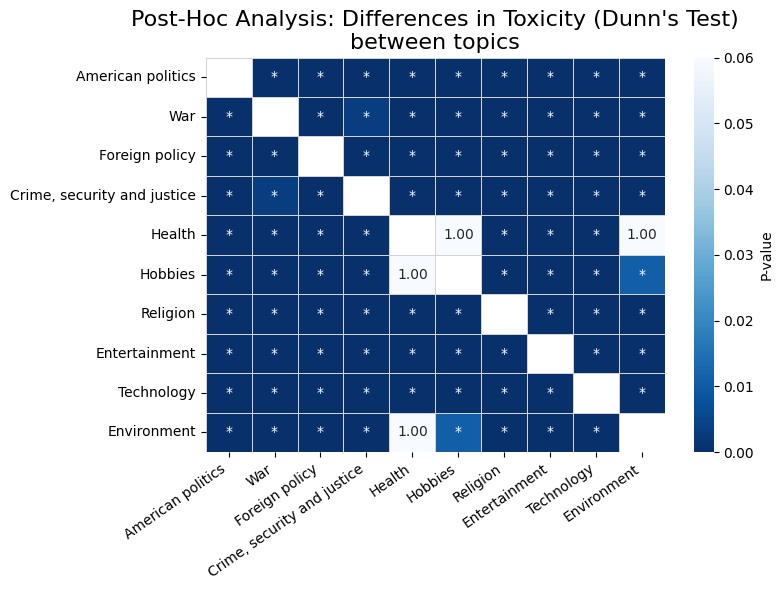

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scikit_posthocs as sp

# --- 1. Run the Test ---
# Ensure 'df' contains 'perspective_toxicity'
p_values_dunn = sp.posthoc_dunn(
    df.dropna(subset=['perspective_toxicity']), 
    val_col='perspective_toxicity', 
    group_col='macrotopic_pred', 
    p_adjust='bonferroni'
)

# --- 2. Data Cleaning ---
df_matrix = p_values_dunn.copy()
df_matrix.index = df_matrix.index.str.replace('_', ' ').str.capitalize()
df_matrix.columns = [c.replace('_', ' ').capitalize() for c in df_matrix.columns]

desired_order = politics + non_politics
desired_order = [t for t in desired_order if t in df_matrix.index]

df_heat = df_matrix.loc[desired_order, desired_order]

# --- 4. Create Annotation Mask (CHANGED HERE) ---
# Logic: 
# If p < 0.05 -> Show '*'
# If p >= 0.05 -> Show the number (formatted to 2 decimals)
annot_labels = df_heat.applymap(lambda x: '*' if x < 0.05 else f'{x:.2f}')

# --- 5. Create Diagonal Mask ---
mask = np.eye(len(df_heat), dtype=bool)

# --- 6. Plotting ---
plt.figure(figsize=(8, 6))

sns.heatmap(
    df_heat,            # Data for color
    mask=mask,
    annot=annot_labels, # Custom text (* or Number)
    fmt='',             # Treat as raw string
    cmap="Blues_r",     # Dark Blue = Significant (Low p-value)
    vmin=0,             
    vmax=0.06,          # Focus color gradient on significant values
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={'label': 'P-value'}
)

plt.title("Post-Hoc Analysis: Differences in Toxicity (Dunn's Test)\nbetween topics", fontsize=16)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [34]:
import pandas as pd

# --- 1. Cálculo das Médias e Desvios (Código original) ---
# Garante que está usando o DF completo
df_mean = df.groupby('macrotopic_pred')[tox_cols].mean()
df_std  = df.groupby('macrotopic_pred')[tox_cols].std()

# Ordenar por toxicidade (Decrescente)
df_mean = df_mean.sort_values(by='perspective_toxicity', ascending=False)
df_std = df_std.reindex(df_mean.index)

# Formatar "Média ± Desvio"
df_tabela = df_mean.round(3).astype(str) + " ± " + df_std.round(3).astype(str)

# Limpeza dos Nomes (Remove underscores e Capitaliza)
df_tabela.index = df_tabela.index.str.replace('_', ' ').str.capitalize()
df_tabela.columns = [c.replace('perspective_', '').replace('_', ' ').capitalize() for c in df_tabela.columns]

# --- 2. Definição das Cores e Listas (ATUALIZADAS) ---

politicos = [
    'American politics', 
    'War', 
    'Foreign policy', 
    'Crime, security and justice'
]

# Adicionei os novos tópicos aqui
nao_politicos = [
    'Health', 
    'Hobbies', 
    'Religion', 
    'Entertainment', # Novo
    'Technology',    # Novo (verifique se no seu banco está apenas 'Technology')
    'Environment'    # Novo
]

def colorir_fundo_index(valor):
    """Pinta o FUNDO do nome do tópico (Índice)"""
    if valor in politicos:
        return 'background-color: #2ca02c; color: white; font-weight: bold;' # Verde
    elif valor in nao_politicos:
        return 'background-color: #1f77b4; color: white; font-weight: bold;' # Azul
    return ''

# --- 3. Aplicação do Estilo ---
styled_table = (df_tabela.style
    .set_caption("Média e Desvio Padrão da Toxicidade por Tópico (Completo)")
    
    # 1. Aplica cores no Índice (Nomes dos tópicos)
    .map_index(colorir_fundo_index, axis=0)
    
    # 2. Força Fundo BRANCO e letra PRETA nos dados (Números)
    .set_properties(**{
        'background-color': 'white',  
        'color': 'black',             
        'border-color': '#d3d3d3',    
        'text-align': 'center',
        'padding': '8px'
    })
    
    # 3. Estilo do Cabeçalho (Azul)
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [
            ('background-color', '#1f77b4'), 
            ('color', 'white'), 
            ('font-weight', 'bold'),
            ('text-align', 'center')
        ]},
        {'selector': 'caption', 'props': [
            ('font-size', '14px'), 
            ('font-weight', 'bold'),
            ('color', 'black')
        ]}
    ])
)

display(styled_table)

,Toxicity,Severe toxicity,Insult,Obscene,Threat,Identity attack
macrotopic_pred,,,,,,
"Crime, security and justice",0.1 ± 0.13,0.082 ± 0.12,0.09 ± 0.124,0.088 ± 0.127,0.084 ± 0.121,0.092 ± 0.123
War,0.098 ± 0.118,0.084 ± 0.114,0.085 ± 0.111,0.086 ± 0.117,0.088 ± 0.114,0.097 ± 0.119
American politics,0.068 ± 0.106,0.054 ± 0.097,0.063 ± 0.103,0.057 ± 0.103,0.056 ± 0.097,0.059 ± 0.099
Entertainment,0.066 ± 0.126,0.056 ± 0.122,0.062 ± 0.127,0.064 ± 0.134,0.056 ± 0.119,0.058 ± 0.121
Religion,0.055 ± 0.097,0.046 ± 0.092,0.049 ± 0.092,0.049 ± 0.095,0.046 ± 0.09,0.051 ± 0.094
Foreign policy,0.052 ± 0.089,0.043 ± 0.084,0.047 ± 0.085,0.046 ± 0.087,0.045 ± 0.083,0.049 ± 0.087
Hobbies,0.046 ± 0.089,0.037 ± 0.083,0.043 ± 0.093,0.041 ± 0.091,0.037 ± 0.082,0.038 ± 0.081
Health,0.042 ± 0.076,0.031 ± 0.066,0.036 ± 0.068,0.033 ± 0.07,0.032 ± 0.066,0.035 ± 0.068
Environment,0.037 ± 0.064,0.029 ± 0.057,0.032 ± 0.059,0.03 ± 0.06,0.03 ± 0.056,0.031 ± 0.057


### boxplot

/tmp/ipykernel_982436/1979016336.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


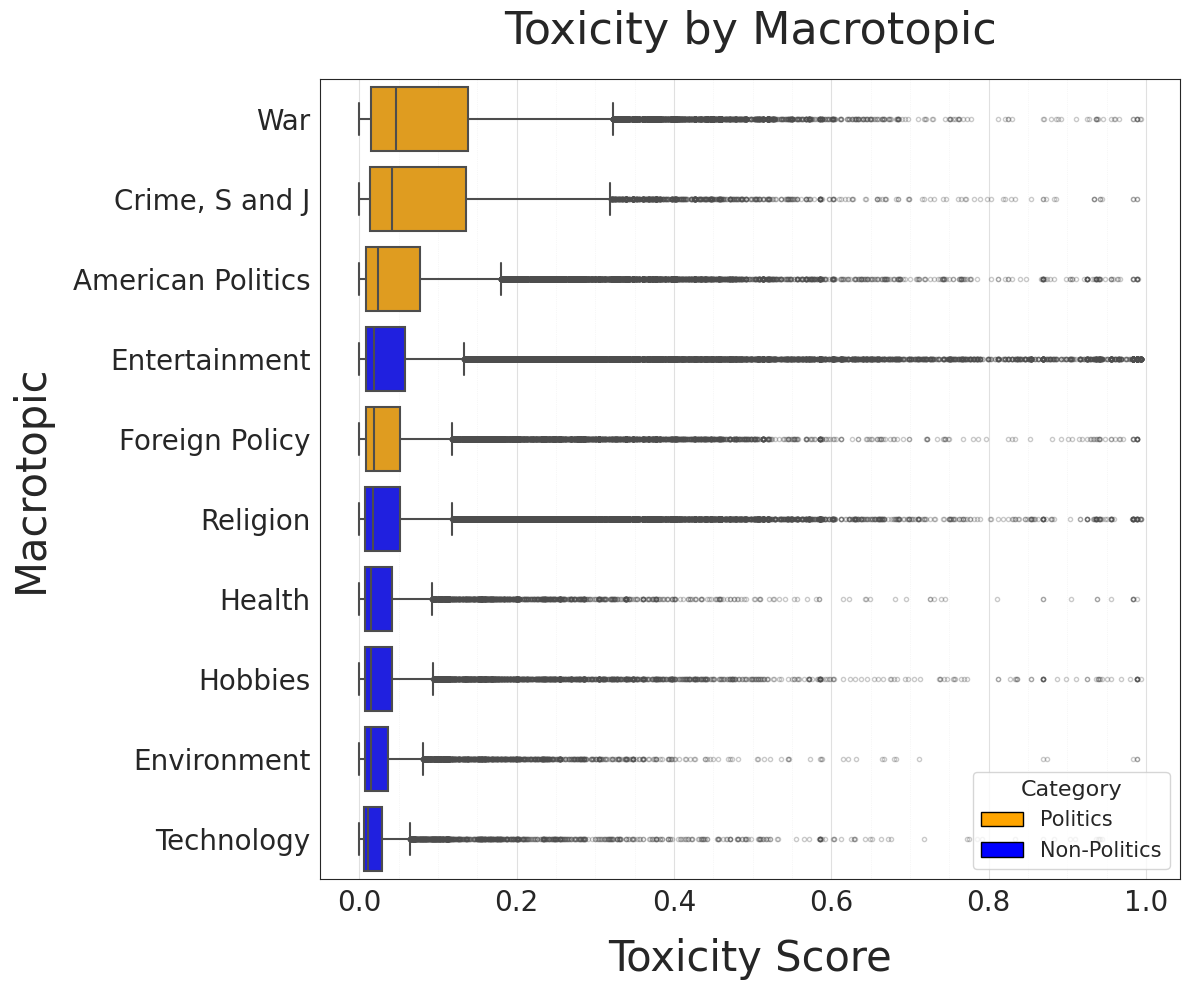

In [62]:
ordem_decrescente = df.groupby('macrotopic_pred')['perspective_toxicity'].median().sort_values(ascending=False).index

# --- 3. IMPLEMENTAÇÃO DO BOXPLOT PADRONIZADO ---
plt.figure(figsize=(12, 10)) # Aumentado para acomodar labels grandes
sns.set_style("white")

# Invertemos x e y para ficar horizontal e aplicamos a ordem
ax = sns.boxplot(
    x='perspective_toxicity', 
    y='macrotopic_pred', 
    data=df, 
    palette=palette_map, 
    order=ordem_decrescente,
    linewidth=1.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

# --- 4. GRADE VERTICAL (Seguindo o padrão técnico anterior) ---
ax.minorticks_on()
ax.grid(True, which='major', axis='x', linestyle='-', linewidth=0.8, color='#d3d3d3', alpha=0.7)
ax.grid(True, which='minor', axis='x', linestyle=':', linewidth=0.5, color='#e0e0e0', alpha=0.5)
ax.set_axisbelow(True)

# --- 5. TÍTULOS E EIXOS (Usando o dicionário) ---
plt.title('Toxicity by Macrotopic', **chart_config["titles"])
plt.xlabel('Toxicity Score', **chart_config["xlabels"])
plt.ylabel('Macrotopic', **chart_config["ylabels"])

# Ticks dos eixos (Sem rotação, pois no Y horizontal a leitura é direta)
plt.xticks(**chart_config["xticks"])
plt.yticks(**chart_config["yticks"])

# --- 6. LEGENDA ---
legend_elements = [
    Patch(facecolor='orange', label='Politics', edgecolor='black'),
    Patch(facecolor='blue',   label='Non-Politics', edgecolor='black'),
]
plt.legend(handles=legend_elements, title='Category', loc='lower right', 
           frameon=True, 
           fontsize=chart_config["legend"]["fontsize"], 
           title_fontsize=chart_config["legend"]["title_fontsize"])

plt.tight_layout()

# Salvando em formato vetorial conforme conversamos
plt.savefig("gráficos/boxplot_toxicity_horizontal.svg", format='svg')
plt.show()

/tmp/ipykernel_2907340/1587160672.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='macrotopic_pred',


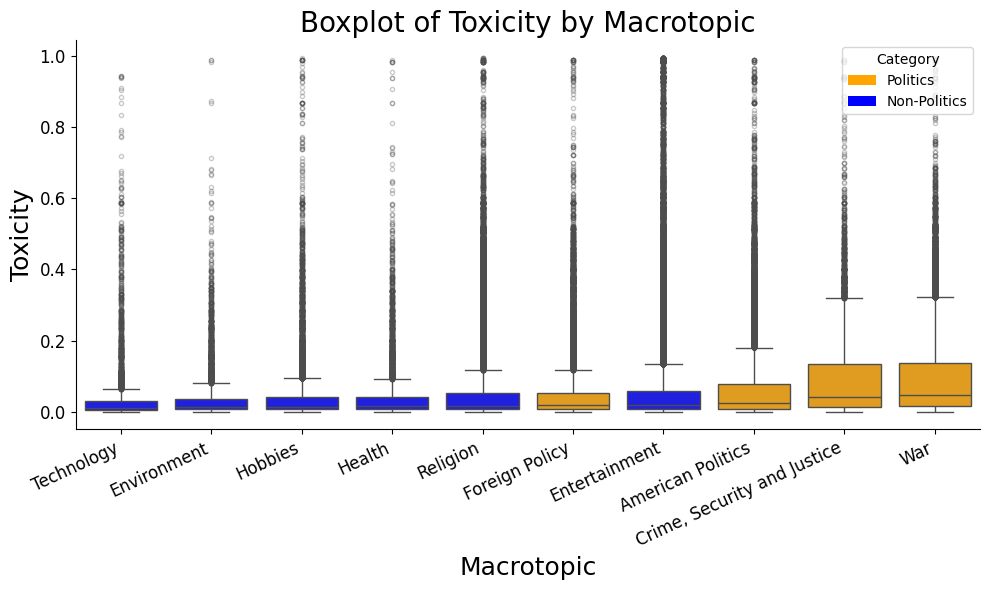

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ordem_crescente = df.groupby('macrotopic_pred')['perspective_toxicity'].median().sort_values().index

plt.figure(figsize=(10, 6))

sns.boxplot(x='macrotopic_pred', 
            y='perspective_toxicity', 
            data=df, 
            palette=palette_map, 
            order=ordem_crescente,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))

plt.title('Boxplot of Toxicity by Macrotopic', fontsize=20)
plt.xlabel('Macrotopic',fontsize=18)
plt.ylabel('Toxicity', fontsize=18)

sns.despine()

legend_elements = [
    Patch(facecolor='orange', label='Politics'),
    Patch(facecolor='blue',   label='Non-Politics'),
]

plt.legend(handles=legend_elements, title='Category', loc='upper right')

plt.xticks(rotation=25, ha='right', size=12) 
plt.yticks(size=12)
plt.tight_layout()
plt.savefig("gráficos/boxplot_toxicity_by_macrotopic") 
plt.show()

In [ ]:
stats = df.groupby('macrotopic_pred')['perspective_toxicity'].describe()
tabela_final = stats.T
display(tabela_final.round(3))

macrotopic_pred,American Politics,"Crime, Security and Justice",Foreign Policy,Health,Hobbies,Religion,War
count,52998.000,9341.000,40410.000,11522.000,18913.000,111071.000,52846.000
mean,0.068,0.100,0.052,0.042,0.046,0.055,0.098
std,0.106,0.130,0.089,0.076,0.089,0.097,0.118
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.009,0.014,0.008,0.007,0.007,0.008,0.015
50%,0.023,0.041,0.019,0.015,0.015,0.017,0.047
75%,0.078,0.136,0.052,0.041,0.042,0.052,0.138
max,0.989,0.989,0.989,0.988,0.994,0.994,0.994


### AAA

American Politics Foreign Policy 1.1344066349051939e-131
American Politics Environment 4.094143767634726e-226
American Politics Health 5.513530653609741e-193
American Politics Hobbies 4.3893841067424745e-248
American Politics Religion 2.0581602880892954e-295
American Politics Technology 0.0
Crime, Security and Justice American Politics 5.6937223312494755e-176
Crime, Security and Justice Foreign Policy 0.0
Crime, Security and Justice Environment 0.0
Crime, Security and Justice Health 0.0
Crime, Security and Justice Hobbies 0.0
Crime, Security and Justice Religion 0.0
Crime, Security and Justice Technology 0.0
Foreign Policy Environment 4.420228230774271e-60
Foreign Policy Health 1.7671294933674777e-46
Foreign Policy Hobbies 2.7919442348323967e-49
Foreign Policy Religion 1.4192620513589319e-12
Foreign Policy Technology 4.291561217362917e-178
War American Politics 0.0
War Crime, Security and Justice 0.00012825247506006082
War Foreign Policy 0.0
War Environment 0.0
War Health 0.0
War Hobbi

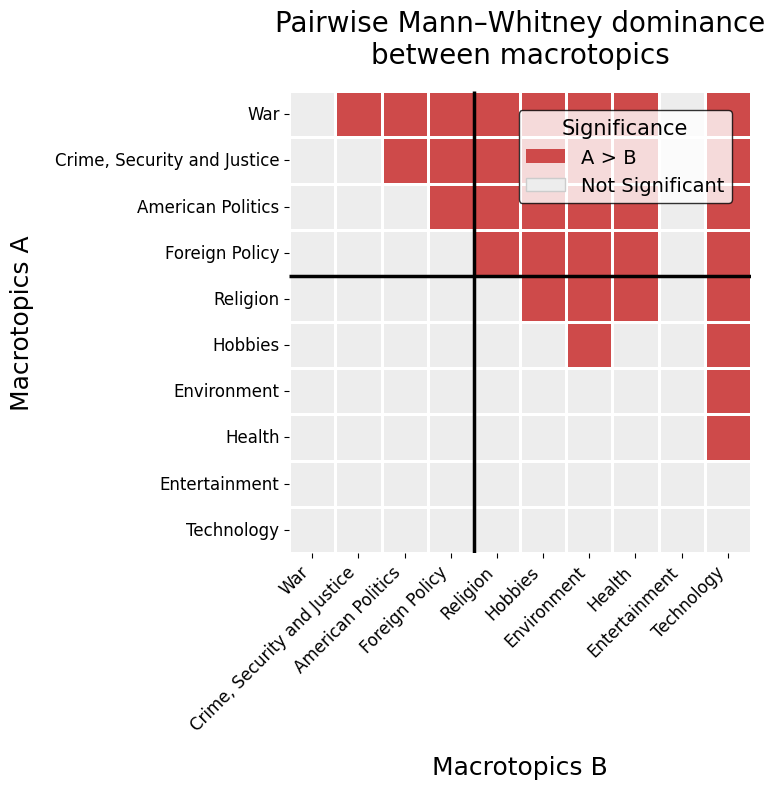

In [14]:
from scipy.stats import mannwhitneyu

toxicity_per_topic={}


for idx,df_group in df.groupby('macrotopic_pred'):
    toxicity_per_topic[idx]=df_group['perspective_toxicity']

comparison_per_topic={}
mannwithney_test_pairwise=np.zeros((len(toxicity_per_topic),len(toxicity_per_topic)))
ordered_topics=sorted(politics)+sorted(non_politics)
for i,idx1 in enumerate(ordered_topics):
    for j,idx2 in enumerate(ordered_topics):
        if idx1==idx2:
            continue
        test=mannwhitneyu(toxicity_per_topic[idx1].to_list(),toxicity_per_topic[idx2].to_list(),alternative='greater').pvalue
        if test<0.05/81: #Bonferroni Correction: every topic is compared with all the others:  
            print(idx1,idx2,test)
            mannwithney_test_pairwise[i,j]=1
mannwithney_test_pairwise=pd.DataFrame(mannwithney_test_pairwise,index=ordered_topics,columns=ordered_topics)

dominance_score = mannwithney_test_pairwise.sum(axis=1).sort_values(ascending=False)
ordered = dominance_score.index

print("Ranking de Dominância (mais tóxicos no topo):")
print(dominance_score)

import seaborn as sns 
from matplotlib.colors import ListedColormap

color_not_sig = '#EDEDED'
color_sig = '#CE4A4A'
custom_cmap = ListedColormap([color_not_sig, color_sig])

ffig, ax = plt.subplots(figsize=(8, 8)) 

# 2. Heatmap
sns.heatmap(
    mannwithney_test_pairwise.loc[ordered, ordered],
    linewidths=0.8,
    linecolor='white',
    cbar=False,
    square=True,      
    ax=ax,
    cmap=custom_cmap
)

# 3. Linhas Divisórias
ax.vlines(4, 0, 10, linestyle='solid', color='black', linewidth=2.5)
ax.hlines(4, 0, 10, linestyle='solid', color='black', linewidth=2.5)

# Títulos e Labels
ax.set_title("Pairwise Mann–Whitney dominance\nbetween macrotopics", fontsize=20, pad=20)
ax.set_xlabel("Macrotopics B", labelpad=15, fontsize=18)
ax.set_ylabel("Macrotopics A", labelpad=15, fontsize=18)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
plt.setp(ax.get_yticklabels(), fontsize=12)

# 4. Legenda "Dentro" ou ao lado da matriz
legend_elements = [
    Patch(facecolor=color_sig, label='A > B'),
    Patch(facecolor=color_not_sig, edgecolor='#CCCCCC', label='Not Significant')
]

# loc='upper left' com bbox_to_anchor=(1.02, 1) coloca a legenda FORA, à direita.
# loc='upper right' com bbox_to_anchor=(0.98, 0.98) coloca a legenda DENTRO, no canto superior direito.
ax.legend(
    handles=legend_elements,
    loc='upper right', 
    bbox_to_anchor=(0.98, 0.98), # Coordenadas internas (x, y) de 0 a 1
    ncol=1,
    frameon=True,       # Moldura ajuda a destacar se estiver sobreposta
    facecolor='white',  # Fundo branco para a legenda não ficar transparente
    edgecolor='black',
    fontsize=14,
    title="Significance",
    title_fontsize=15
)

plt.tight_layout()
plt.show()

___
## **RQ2 Analisando a Difusão de vídeos políticos pelo Telegram**

In [17]:
interest = ['War','American Politics','Foreign Policy','Crime, Security and Justice','Health','Religion','Hobbies'
    #,"Technology","Environment","Entertainment"
    ]
df = df_all[df_all["macrotopic_pred"].isin(interest)]
df_complete = df_complete[df_complete["macrotopic_pred"].isin(interest)]

#### *Correlação de Spearman*

In [39]:
def spearman_by_topic(df_topic, col_pivo ,cols):
    results = {}

    for col in cols:
        tmp = df_topic[[col_pivo, col]].dropna()

        rho, p = spearmanr(tmp[col_pivo], tmp[col])

        results[col] = {
            'spearman_rho': rho,
            'p_value': p,
            'n': len(tmp)
        }

    return results

In [40]:
def apply_spearman_correlation(df, col_pivo, cols):
    all_results = []

    for topic, df_topic in df.groupby('macrotopic_pred'):
        topic_results = spearman_by_topic(df_topic, col_pivo, cols)

        for metric, values in topic_results.items():
            all_results.append({
                'macrotopic_pred': topic,
                'metric': metric,
                'spearman_rho': values['spearman_rho'],
                'p_value': values['p_value'], 
                'n': values['n']
            })

    results_df = pd.DataFrame(all_results)

    # Tabela 1: Força da Correlação (Rho)
    pivot_rho = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='spearman_rho'
    ).sort_index()
    
    # Tabela 2: Significância Estatística (P-valor)
    pivot_p = results_df.pivot(
        index='macrotopic_pred', columns='metric', values='p_value'
    ).sort_index()

    return pivot_rho, pivot_p

In [60]:
def plot_heatmap(
    pivot, title, p_values=None, vmin=-1, vmax=1,
    xlabel="Perspective API Metric", ylabel="Macrotopic",
    yticks=True, xticks=True, cbar_label="Spearman ρ",
    ax=None, cbar=True, cbar_ax=None
):

    pivot_plot = pivot.copy()
    pivot_plot.columns = [
        col.replace('perspective_', '').replace('_', ' ')
        for col in pivot_plot.columns
    ]

    mask = None
    annot_data = True
    fmt_str = ".2f"

    if p_values is not None:
        p_val_plot = p_values.copy()
        p_val_plot.columns = pivot_plot.columns

        # p >= 0.05 será mascarado (inclui o caso p == 0.05)
        mask = p_val_plot >= 0.05

        # anotação só com o valor (sem asterisco)
        annot_data = pivot_plot.round(2).astype(str)

        # remove texto das células mascaradas
        for r in pivot_plot.index:
            for c in pivot_plot.columns:
                if mask.loc[r, c]:
                    annot_data.loc[r, c] = ""

        fmt_str = ""

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # colormap com cor para células mascaradas
    cmap = sns.color_palette("RdBu_r", as_cmap=True)
    cmap.set_bad(color="#f2f2f2")

    sns.heatmap(
        pivot_plot,
        annot=annot_data,
        fmt=fmt_str,
        cmap=cmap,
        center=0,
        vmin=vmin,
        vmax=vmax,
        mask=mask,
        linewidths=0.01,
        yticklabels=yticks,
        xticklabels=xticks,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        annot_kws={"color": "black", "fontsize": 14},
        cbar_kws={"label": cbar_label}
    )

    ax.set_title(title, fontsize=18)
    #ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='x', rotation=45, labelsize=12)
    ax.tick_params(axis='y', rotation=0, labelsize=12)

    if ax is None:
        plt.tight_layout()
        plt.show()


#### **1. toxicidade x métricas**

In [65]:
df_analise_canal = df_complete.groupby("video_id").agg({
    "folder": "nunique",
    "perspective_toxicity": "mean",
    "perspective_identity_attack": "mean",
    "perspective_insult": "mean",
    "perspective_obscene": "mean",
    "perspective_severe_toxicity": "mean",
    "perspective_threat": "mean",
    "macrotopic_pred": "first",
}).reset_index()

In [66]:
ordem_desejada = [
    "War",
    "Crime, Security and Justice",
    "American Politics",
    "Foreign Policy",
    "Religion",
    "Hobbies",
    "Health"
]


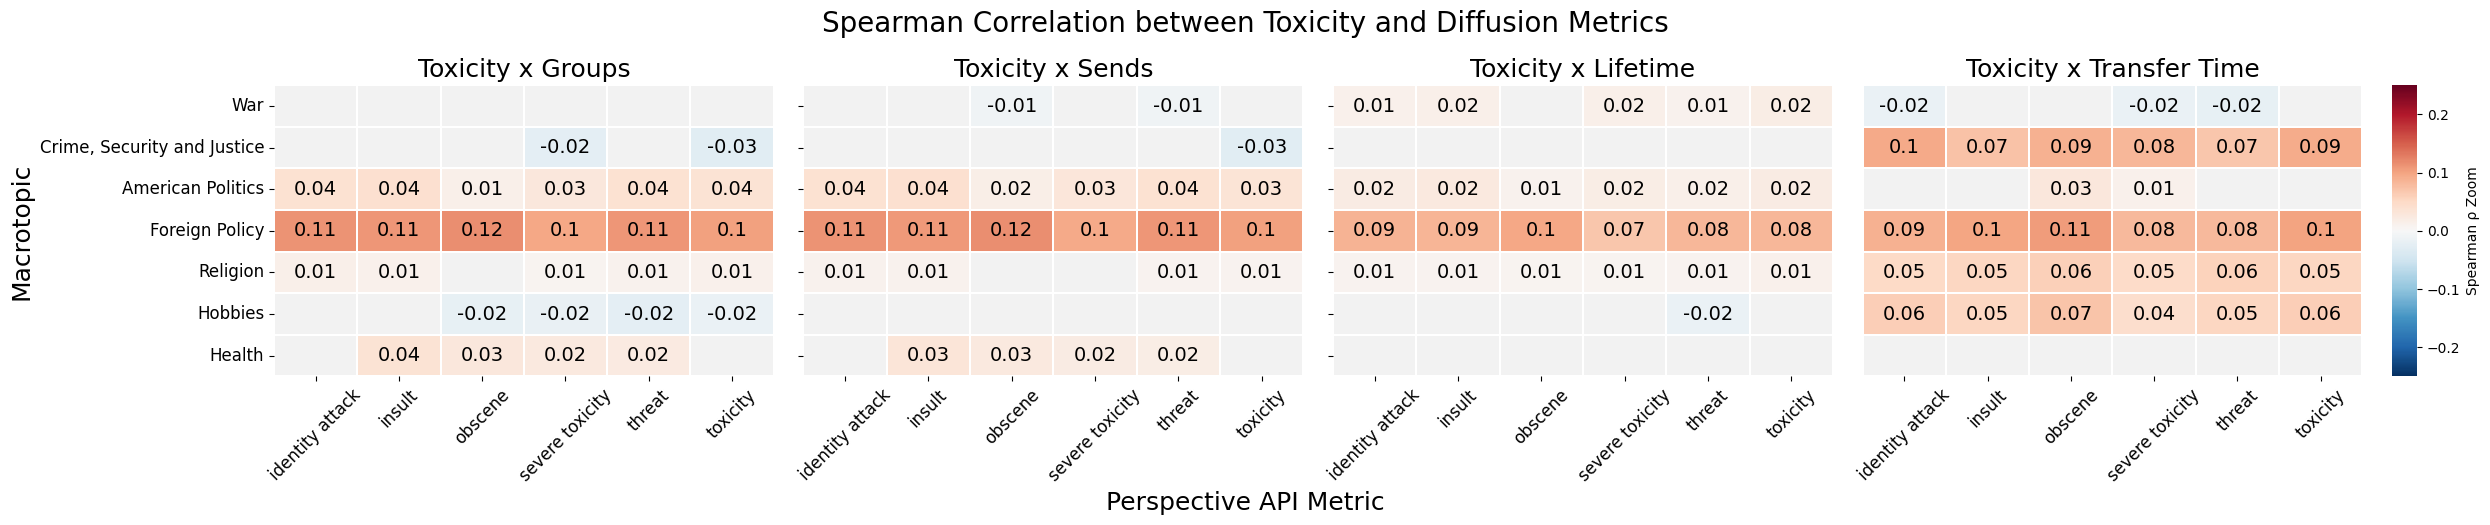

In [67]:
fig, axs = plt.subplots(1, 5, figsize=(25, 5), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.05]})

fig.suptitle('Spearman Correlation between Toxicity and Diffusion Metrics', fontsize=20)

# --- GRÁFICO 1: GROUPS (Grupos/Canais) - Eixo 0 ---
rho, p_vals = apply_spearman_correlation(df_analise_canal, 'folder', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Toxicity x Groups', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[0],       # <--- Eixo 0
    cbar=False
)

# --- GRÁFICO 2: SENDS (Envios) - Eixo 1 ---
rho, p_vals = apply_spearman_correlation(df, 'send_count', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Toxicity x Sends', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[1],       # <--- Eixo 1
    cbar=False,
    ylabel=""        
)

# --- GRÁFICO 3: LIFETIME (Tempo de Vida) - Eixo 2 ---
rho, p_vals = apply_spearman_correlation(df, 'lifetime', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Toxicity x Lifetime', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[2],       # <--- Eixo 2
    cbar=False,       
    cbar_label="Spearman ρ Zoom",
    ylabel=""     
)

# --- GRÁFICO 4: Transfer Time 
rho, p_vals = apply_spearman_correlation(df, 'transfer_time', tox_cols)
rho = rho.reindex(ordem_desejada)
p_vals = p_vals.reindex(ordem_desejada)

plot_heatmap(
    rho, 'Toxicity x Transfer Time', p_values=p_vals,
    vmin=-0.25, vmax=0.25, 
    ax=axs[3],       
    cbar=True,       
    cbar_ax=axs[4],  
    cbar_label="Spearman ρ Zoom",
    yticks=False,
    ylabel=""     
)


# Ajustes cosméticos finais para remover os textos do eixo Y dos gráficos 2 e 3
axs[1].tick_params(labelleft=False)
axs[2].tick_params(labelleft=False)

fig.text(0.5, -0.02, 'Perspective API Metric', ha='center', fontsize=18)

plt.tight_layout()
plt.show()

### Gráficos cumulativos

In [18]:
df_resumo = df_complete.groupby('video_id').agg({
    'lifetime': 'first',               
    'send_count': 'first',            
    'folder': 'nunique',
    'transfer_time': 'first',                   
    'macrotopic_pred': 'first',             
    'perspective_toxicity': 'mean'         
}).reset_index()

df_resumo.columns = ['video_id', 'lifetime', 'send_count', 'channels', 'transfer_time', 'macrotopic_pred', 'perspective_toxicity']
display(df_resumo.head())

,video_id,lifetime,send_count,channels,transfer_time,macrotopic_pred,perspective_toxicity
0,---HJCJANEk,1.0,1,1,1937.0,Religion,0.023995
1,--0HDiV4Wrk,1.0,1,1,85.0,Foreign Policy,0.005799
2,--0WrRVhu20,1.0,10,9,0.0,"Crime, Security and Justice",0.008402
3,--0jTye5wh4,1.0,1,1,0.0,Religion,0.007362
4,--0o49GFj4U,1.0,1,1,0.0,Religion,0.004463


In [19]:
print(df_resumo['macrotopic_pred'].value_counts())
len(df_resumo)

macrotopic_pred
Religion                       111071
American Politics               52998
War                             52846
Foreign Policy                  40410
Hobbies                         18913
Health                          11522
Crime, Security and Justice      9341
Name: count, dtype: int64


297101

In [20]:
# 1. Printar a distribuição por tópico (como você já estava fazendo)
print("Distribuição por tópico (envio único):")
print(df_resumo['macrotopic_pred'][df_resumo['send_count'] == 1].value_counts())

print("-" * 30)

# 2. Printar a quantidade TOTAL apenas uma vez
total_envio_unico = len(df_resumo[df_resumo['send_count'] == 1])
print(f"Total de vídeos com apenas 1 envio: {total_envio_unico}")

print(f"Vídeos que foram enviados mais de uma vez: {len(df_resumo) - total_envio_unico}")

Distribuição por tópico (envio único):
macrotopic_pred
Religion                       64947
War                            33570
Foreign Policy                 28580
American Politics              24819
Hobbies                        13985
Health                          6740
Crime, Security and Justice     4094
Name: count, dtype: int64
------------------------------
Total de vídeos com apenas 1 envio: 176735
Vídeos que foram enviados mais de uma vez: 120366


78% dos vídeos são enviados apenas 1 vez, portanto tendo o alcance equivalente independente do tópico

In [21]:
df_resumo['Politics']=df_resumo['macrotopic_pred'].apply(lambda x: x in politics)
df_politics=df_resumo[df_resumo['Politics']]
df_non_politics=df_resumo[~df_resumo['Politics']]

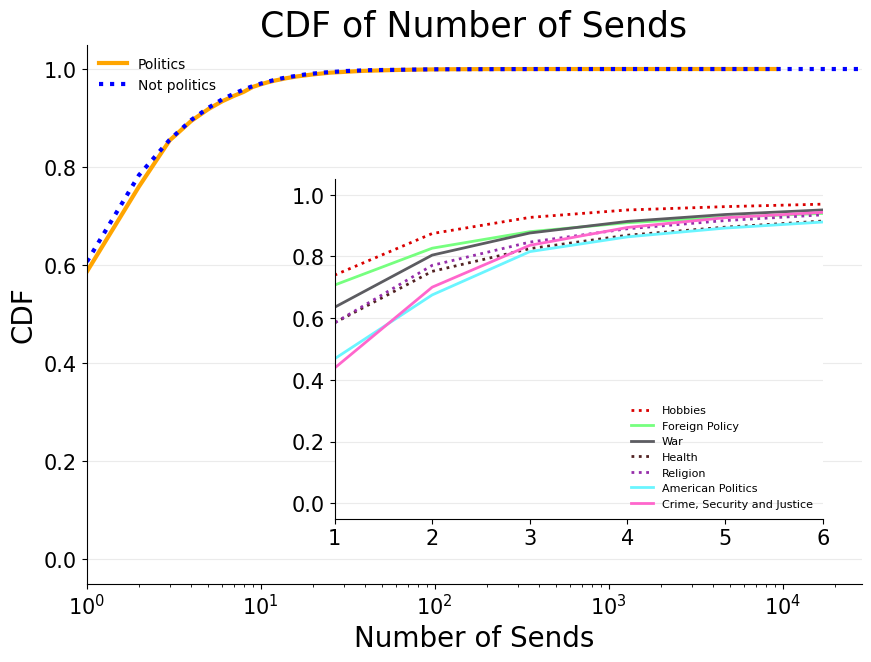

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

value = 'send_count'

# Politics
x_sorted = df_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])

ax.plot(xs, y, 'orange', linestyle='solid', linewidth=3, label='Politics')

# Not politics
x_sorted = df_non_politics[value].sort_values().values
n = len(x_sorted)
xs = np.unique(x_sorted)
y = np.array([(x_sorted <= v).sum() / n for v in xs])

ax.plot(xs, y, 'blue', linestyle='dotted', linewidth=3, label='Not politics')

ax.set_xscale('log')
ax.set_xlim(1, df_resumo[value].max() + 1)
ax.set_xlabel('Number of Sends', fontsize=20)
ax.set_ylabel('CDF', fontsize=20)
ax.tick_params(labelsize=15)

ax.legend(loc='upper left', frameon=False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# =======================
# INSET – CDF por macrotopic 
# =======================

axin = ax.inset_axes([0.32, 0.12, 0.63, 0.63])

ponto_ordenacao = 1

ordem_series = df_resumo.groupby('macrotopic_pred')[value].apply(
    lambda x: (x <= ponto_ordenacao).mean()
)

# do maior para o menor (quem tem mais massa em x=1 aparece primeiro)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()

for idx in hue_order_list:

    df_group = df_resumo[df_resumo['macrotopic_pred'] == idx]
    x_sorted = df_group[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([(x_sorted <= v).sum() / n for v in xs])

    linestyle = 'solid' if idx in politics else 'dotted'
    axin.plot(
        xs,
        y,
        color=macro_colors[idx],
        linewidth=2,
        linestyle=linestyle,
        label=idx
    )

axin.set_xlim(1, 6)

axin.set_xlabel('')
axin.set_ylabel('')
axin.tick_params(labelsize=15)

axin.spines['right'].set_visible(False)
axin.spines['top'].set_visible(False)

axin.legend(
    fontsize=8,
    frameon=False,
    loc='lower right'
)

ax.grid(True, axis='y', which='both', alpha=0.25)
axin.grid(True, axis='y', which='both', alpha=0.25)

ax.set_title('CDF of Number of Sends', fontsize=25)

plt.savefig("gráficos/cdf_sends")
plt.show()

In [23]:
palette_cat = {'politics': 'green', 'non-politics': 'blue'}

ValueError: Could not interpret value `categoria_politica` for `hue`. An entry with this name does not appear in `data`.

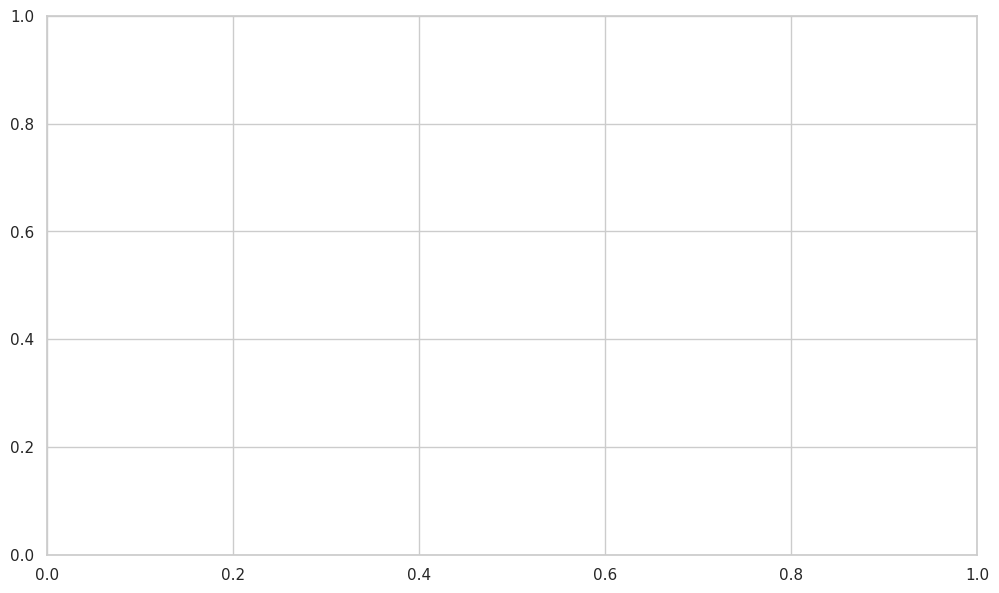

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Single Figure Configuration ---
fig, ax = plt.subplots(figsize=(12, 7))

# ==============================================================================
# MAIN PLOT: Grouped by Category
# ==============================================================================
sns.ecdfplot(
    data=df_resumo,
    x='send_count',
    hue='categoria_politica',
    palette=palette_cat,
    linewidth=3.0,
    ax=ax
)

ax.set_xscale('log')  
ax.set_title('Number of Sends Grouped: Politics vs. Non-Politics', fontsize=16)
ax.set_xlabel('Number of Sends', fontsize=14)
ax.set_ylabel('Cumulative Proportion', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)

sns.move_legend(ax, "upper left", title='Category', frameon=True)

# ==============================================================================
# INSET PLOT (The Detail Zoom)
# ==============================================================================

# Create floating axes.
ax_inset = ax.inset_axes([0.25, 0.15, 0.65, 0.65])

# --- LÓGICA DE ORDENAÇÃO ATUALIZADA (Baseada em x=1) ---
ponto_ordenacao = 1  # <--- Definimos que queremos ordenar pelo valor em X=1

# Calcula a proporção acumulada (altura da linha) exatamente em x=1
ordem_series = df_resumo.groupby('macrotopic_pred')['send_count'].apply(
    lambda x: (x <= ponto_ordenacao).mean()
)

# Ordena do maior para o menor (Topo visual -> Fundo visual)
hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()
# -------------------------------------------------------

# Plot DETAILED data
sns.ecdfplot(
    data=df_resumo,
    x='send_count',
    hue='macrotopic_pred',
    palette=macro_colors,
    hue_order=hue_order_list, # <--- Aplica a ordem calculada em x=1
    linewidth=2,
    ax=ax_inset,
    legend=True
)

# Configuração do Zoom (Mantivemos a visualização até 6 como no anterior)
ax_inset.set_xlim(0, 6) 
ax_inset.set_ylim(0.4, 1.02)

# Inset Cosmetics (English)
ax_inset.set_title('Zoom: Detailed by Topic (0-6 Sends)', fontsize=11)
ax_inset.set_xlabel('') 
ax_inset.set_ylabel('')
ax_inset.tick_params(axis='both', which='major', labelsize=9)
ax_inset.grid(True, linestyle=':', alpha=0.7)
ax_inset.set_facecolor('white') 

# Inset Legend Adjustment
sns.move_legend(
    ax_inset, 
    "lower right",          
    bbox_to_anchor=(1, 0),  
    title="Macrotopic",             
    frameon=True,           
    labelspacing=0.3,       
    handlelength=1.0        
)

plt.tight_layout()
plt.show()

Portanto a massa dos vídeos tem um poder de difusão similar, uma característica de 1 envio, 1 canal, 1 dia
Vamos analisar agora os vídeos com quantidade de envio maior do que 2 para ver se quando um vídeo é repetido isso difere

In [67]:
df_resumo = df_resumo[df_resumo['send_count'] > 1].copy()
len(df_resumo)

120361

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Data Configuration ---
if 'categoria_politica' not in df_resumo.columns:
    df_analise = df_resumo.copy()
    df_analise['categoria_politica'] = df_analise['macrotopic_pred'].apply(classificar_topico)
    df_plot = df_analise[df_analise['categoria_politica'].isin(['politics', 'non-politics'])]
else:
    df_plot = df_resumo[df_resumo['categoria_politica'].isin(['politics', 'non-politics'])]

# --- 2. Helper Function to Plot Single Graph with Zoom ---
def plot_single_with_zoom(ax, x_col, xlim_main, xlim_zoom, labels):
    
    # --- MAIN PLOT: By Category ---
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='categoria_politica',
        palette=palette_cat, linewidth=3, ax=ax
    )
    
    # Main Axis Config
    ax.set_xlim(0, xlim_main) 
    ax.set_title(labels['title'], fontsize=12)
    ax.set_xlabel(labels['xlabel'], fontsize=12)
    ax.set_ylabel(labels['ylabel'], fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    sns.move_legend(ax, "upper left", title='Category', frameon=True)

    # --- THE INSET (ZOOM) ---
    ax_inset = ax.inset_axes([0.25, 0.15, 0.7, 0.55])
    
    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA (SORT BY X-LIMIT) ---
    # 1. Calcula a proporção acumulada (eixo Y) exatamente no limite do zoom (xlim_zoom)
    ordem_series = df_plot.groupby('macrotopic_pred')[x_col].apply(
        lambda x: (x <= xlim_zoom).mean()
    )
    
    # 2. Ordena do maior para o menor (Topo visual -> Fundo visual)
    hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()
    # --------------------------------------------------------

    # Plots the DETAILED data inside the Inset using the calculated order
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='macrotopic_pred',
        palette=macro_colors, 
        hue_order=hue_order_list,  # <--- APLICA A ORDEM AQUI
        linewidth=2, ax=ax_inset, legend=True
    )
    
    # Zoom Configuration
    # Nota: Começando do 0 ou 1 dependendo da sua preferência visual (seu código tinha 1)
    ax_inset.set_xlim(0, xlim_zoom) 
    
    # Ajuste cosmético do Inset
    ax_inset.set_title(f"Zoom: Topics (0-{xlim_zoom})", fontsize=9)
    ax_inset.set_xlabel('')
    ax_inset.set_ylabel('')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, linestyle=':', alpha=0.7)
    ax_inset.set_facecolor('white')
    
    # Ajuste da Legenda do Inset
    sns.move_legend(
        ax_inset, 
        "lower right",          
        bbox_to_anchor=(1, 0),  
        title=None,             
        frameon=True,           
        fontsize='small',    
        labelspacing=0.2,       
        handlelength=1.0        
    )


# --- 3. Generating the Grid (1 Row x 3 Columns) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# ==============================================================================
# COLUMN 1: NUMBER OF SENDS
# ==============================================================================
plot_single_with_zoom(
    ax=axes[0],
    x_col='send_count',
    xlim_main=50,   
    xlim_zoom=5,    # Ordenará a legenda baseada em quem está mais alto em x=5
    labels={
        'title': 'Virality by Category (+ Topic Zoom)',
        'xlabel': 'Number of Sends',
        'ylabel': 'Cumulative Proportion'
    }
)

# ==============================================================================
# COLUMN 2: REACH
# ==============================================================================
plot_single_with_zoom(
    ax=axes[1],
    x_col='groups',
    xlim_main=50,
    xlim_zoom=5,    # Ordenará a legenda baseada em quem está mais alto em x=5
    labels={
        'title': 'Reach by Category (+ Topic Zoom)',
        'xlabel': 'Number of Unique Groups',
        'ylabel': '' 
    }
)

# ==============================================================================
# COLUMN 3: LIFETIME
# ==============================================================================
plot_single_with_zoom(
    ax=axes[2],
    x_col='lifetime',
    xlim_main=None, 
    xlim_zoom=20,   # Ordenará a legenda baseada em quem está mais alto em x=20
    labels={
        'title': 'Lifetime by Category (+ Topic Zoom)',
        'xlabel': 'Lifetime',
        'ylabel': ''
    }
)

plt.tight_layout()
plt.show()

NameError: name 'classificar_topico' is not defined

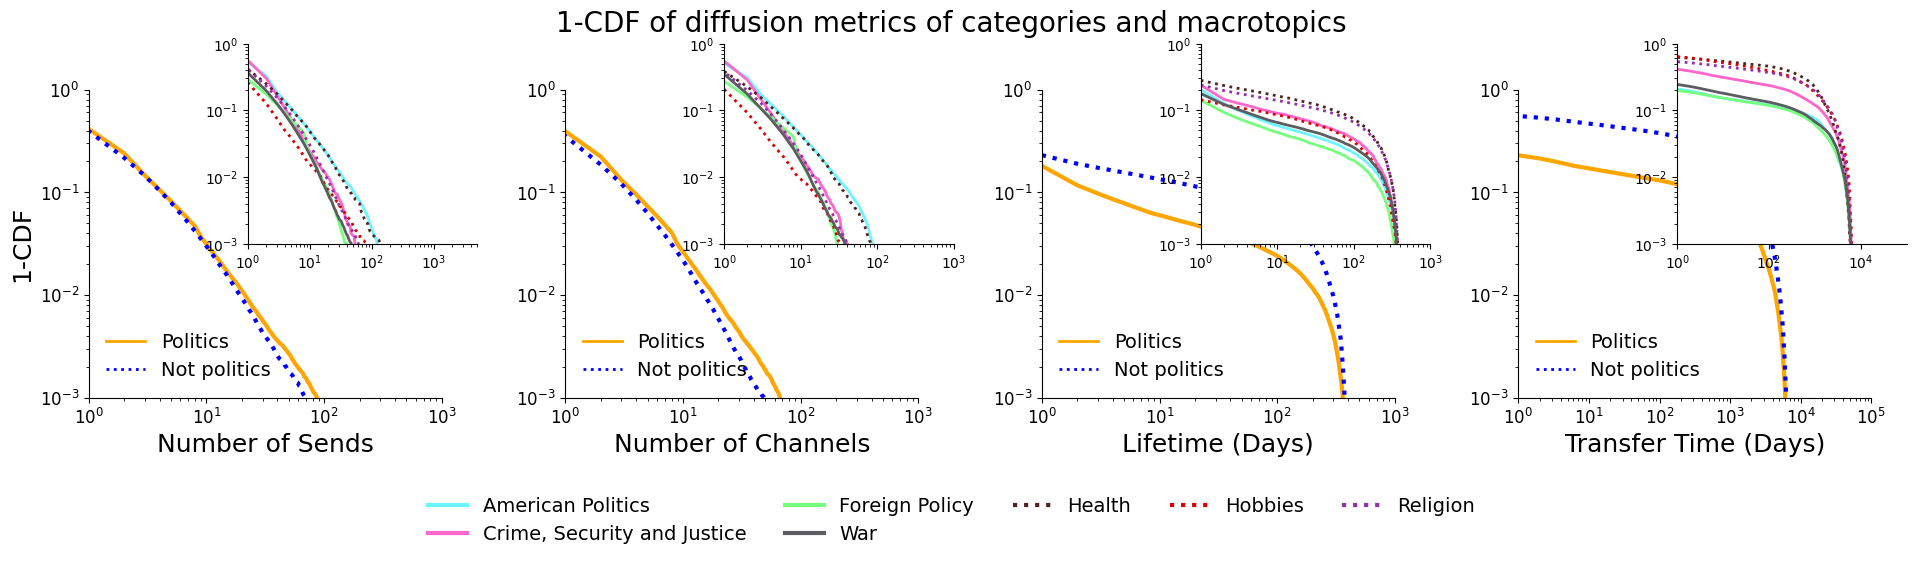

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from collections import Counter
from matplotlib.lines import Line2D

fig, axs = plt.subplots(figsize=(23, 4),ncols=4)
fig.subplots_adjust(wspace=0.35)

to_plot=['send_count','channels','lifetime','transfer_time']

macros_used = sorted(df_resumo['macrotopic_pred'].unique())

axins=[]

for ax,value in zip(axs,to_plot):
    
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs
            , y
            ,'orange'
            ,linestyle='solid'
            ,linewidth=3)
    
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)
    xs = np.unique(x_sorted)
    y = np.array([1-((x_sorted <= v).sum()) / n for v in xs])

    ax.plot(xs 
            , y
            ,'blue'
            ,linestyle='dotted'
            ,linewidth=3)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    legend_elements = [
        Line2D([0], [0], color='orange', lw=2, linestyle='-',
               label='Politics'),
        Line2D([0], [0], color='blue', lw=2, linestyle='dotted',
               label='Not politics')
    ]
    
     
    ax.legend( handles=legend_elements,
        fontsize=14,
        frameon=False,
        loc='lower left')

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    axin = inset_axes(
        ax,
        width="65%",     # dimensione relativa
        height="65%",
        loc='upper right',
        borderpad=0,
        bbox_to_anchor=(0.1, 0.15, 1, 1),  # x > 1 
        bbox_transform=ax.transAxes
    )

    for idx,df_group in df_resumo.groupby('macrotopic_pred'):
        lines=[]
        linestyle = 'solid' if idx in politics else 'dotted'

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)
        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])
        line = axin.plot(xs,
                        y,
                        label=idx,
                        c=macro_colors[idx],
                        linewidth=2,
                        linestyle=linestyle)

        lines.append(line)

        
    axin.set_xscale('log')
    axin.set_yscale('log')

    axin.spines['right'].set_visible(False)
    axin.spines['top'].set_visible(False)
    
    axins.append(axin)

ordered_macros = (
    [m for m in macros_used if m in politics] +
    [m for m in macros_used if m not in politics]
)
legend_elements = [
    Line2D([0], [0], color=macro_colors[idx], lw=3, linestyle='solid' if idx in politics else 'dotted',
           label=idx)
        for idx in ordered_macros]

axs[0].set_xlim(1,1000)
axs[0].set_ylim(1e-3,1)
axs[0].set_xlabel('Number of Sends',fontsize=18)
axs[0].set_ylabel('1-CDF',fontsize=18)
axins[0].set_xlim(1,5000)
axins[0].set_ylim(1e-3,1)


axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-3,1)
axs[1].set_xlabel('Number of Channels',fontsize=18)
axins[1].set_xlim(1,1000)
axins[1].set_ylim(1e-3,1)


axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-3,1)
axs[2].set_xlabel('Lifetime (Days)',fontsize=18)
axins[2].set_xlim(1,1000)
axins[2].set_ylim(1e-3,1)

axs[3].set_xlim(1, 100000) 
axs[3].set_ylim(1e-3, 1)
axs[3].set_xlabel('Transfer Time (Days)',fontsize=18)
axins[3].set_xlim(1,100000)
axins[3].set_ylim(1e-3,1)

fig.suptitle(
    '1-CDF of diffusion metrics of categories and macrotopics',
    fontsize=20,
    y=1.08
)
fig.legend(handles=legend_elements,
            loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.3)
)
    
plt.savefig("gráficos/ecdf_category_topic.png", bbox_inches='tight')

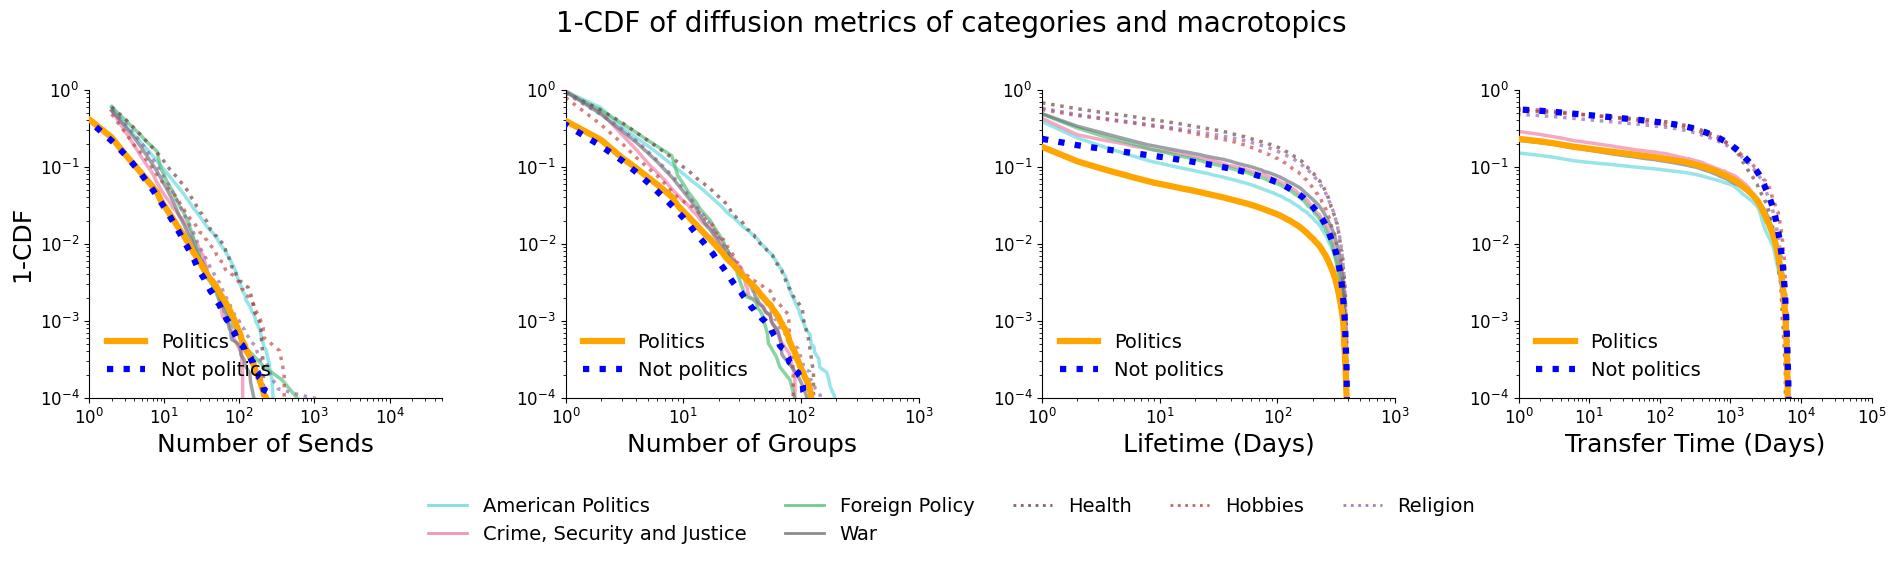

In [38]:
from matplotlib.lines import Line2D

fig, axs = plt.subplots(figsize=(23, 4), ncols=4)
fig.subplots_adjust(wspace=0.35)

to_plot = ['send_count','groups','lifetime','transfer_time']
macros_used = sorted(df_resumo['macrotopic_pred'].unique())

for ax, value in zip(axs, to_plot):

    # -------------------------------
    # Macrotópicos (apagados)
    # -------------------------------
    for idx, df_group in df_resumo.groupby('macrotopic_pred'):

        linestyle = 'solid' if idx in politics else 'dotted'

        x_sorted = df_group[value].sort_values().values
        n = len(x_sorted)

        if n == 0:
            continue

        xs = np.unique(x_sorted)
        y  = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

        ax.plot(
            xs, y,
            color=macro_colors[idx],
            linewidth=2.5,
            linestyle=linestyle,
            alpha=0.65,
            zorder=1
        )

    # -------------------------------
    # Categoria: politics (forte)
    # -------------------------------
    x_sorted = df_politics[value].sort_values().values
    n = len(x_sorted)

    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color='orange',
        linestyle='solid',
        linewidth=4.5,
        alpha=1.0,
        zorder=3
    )

    # -------------------------------
    # Categoria: non-politics (forte)
    # -------------------------------
    x_sorted = df_non_politics[value].sort_values().values
    n = len(x_sorted)

    xs = np.unique(x_sorted)
    y = np.array([1 - (x_sorted <= v).sum() / n for v in xs])

    ax.plot(
        xs, y,
        color='blue',
        linestyle='dotted',
        linewidth=4.5,
        alpha=1.0,
        zorder=3
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    # legenda local só das categorias
    legend_elements = [
        Line2D([0], [0], color='orange', lw=4.5, linestyle='-',
               label='Politics'),
        Line2D([0], [0], color='blue', lw=4.5, linestyle='dotted',
               label='Not politics')
    ]

    ax.legend(
        handles=legend_elements,
        fontsize=14,
        frameon=False,
        loc='lower left'
    )

    ax.tick_params(axis='both', labelsize=12)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


# -------------------------------
# Limites e labels
# -------------------------------
axs[0].set_xlim(1,50000)
axs[0].set_ylim(1e-4,1)
axs[0].set_xlabel('Number of Sends', fontsize=18)
axs[0].set_ylabel('1-CDF', fontsize=18)

axs[1].set_xlim(1,1000)
axs[1].set_ylim(1e-4,1)
axs[1].set_xlabel('Number of Groups', fontsize=18)

axs[2].set_xlim(1,1000)
axs[2].set_ylim(1e-4,1)
axs[2].set_xlabel('Lifetime (Days)', fontsize=18)

axs[3].set_xlim(1,100000)
axs[3].set_ylim(1e-4,1)
axs[3].set_xlabel('Transfer Time (Days)', fontsize=18)


# -------------------------------
# Legenda geral dos macrotópicos
# -------------------------------
ordered_macros = (
    [m for m in macros_used if m in politics] +
    [m for m in macros_used if m not in politics]
)

legend_elements = [
    Line2D(
        [0], [0],
        color=macro_colors[idx],
        lw=2,
        linestyle='solid' if idx in politics else 'dotted',
        label=idx,
        alpha=0.8
    )
    for idx in ordered_macros
]

fig.suptitle(
    '1-CDF of diffusion metrics of categories and macrotopics',
    fontsize=20,
    y=1.08
)

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=5,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.3)
)

plt.savefig("gráficos/ecdf_category_topic.png", bbox_inches='tight')
plt.show()

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Data Preparation ---
if 'categoria_politica' not in df_resumo.columns:
    df_analise = df_resumo[df_resumo['send_count'] > 1].copy()
    df_analise['categoria_politica'] = df_analise['macrotopic_pred'].apply(classificar_topico)
    df_plot = df_analise[df_analise['categoria_politica'].isin(['politics', 'non-politics'])].copy()
else:
    df_plot = df_resumo[df_resumo['send_count'] > 1].copy()
    df_plot = df_plot[df_plot['categoria_politica'].isin(['politics', 'non-politics'])]

# Métricas
df_plot['taxa_espalhamento'] = df_plot['groups'] / df_plot['send_count']
df_plot['velocidade_expansao'] = df_plot['groups'] / df_plot['lifetime']
df_plot['intensidade_disparo'] = df_plot['send_count'] / df_plot['lifetime']

# --- 2. Helper Function ---
# Adicionamos o argumento 'sort_at_x'
def plot_single_with_zoom(ax, x_col, xlim_main, xlim_zoom, labels, xini_zoom=0, zoom_pos="lower right", sort_at_x=None):
    
    # Se não passar sort_at_x, usa o limite do zoom como padrão
    if sort_at_x is None:
        sort_at_x = xlim_zoom

    # --- MAIN PLOT ---
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='categoria_politica',
        palette=palette_cat, linewidth=3, ax=ax
    )
    
    ax.set_xlim(0, xlim_main)
    ax.set_title(labels['title'], fontsize=12)
    ax.set_xlabel(labels['xlabel'], fontsize=12)
    ax.set_ylabel(labels['ylabel'], fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    legend_loc = "lower right" if zoom_pos == "upper left" else "upper left"
    sns.move_legend(ax, legend_loc, title='Category', frameon=True)

    # --- INSET CONFIGURATION ---
    if zoom_pos == "upper left":
        inset_bounds = [0.1, 0.50, 0.65, 0.40] 
    else: 
        inset_bounds = [0.3, 0.15, 0.6, 0.45] 

    ax_inset = ax.inset_axes(inset_bounds)
    
    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Calcula a altura da linha exatamente no ponto 'sort_at_x' escolhido
    ordem_series = df_plot.groupby('macrotopic_pred')[x_col].apply(
        lambda x: (x <= sort_at_x).mean()
    )
    hue_order_list = ordem_series.sort_values(ascending=False).index.tolist()
    # ----------------------------------------

    # --- INSET PLOT ---
    sns.ecdfplot(
        data=df_plot, x=x_col, hue='macrotopic_pred',
        palette=macro_colors, 
        hue_order=hue_order_list,  # <--- Aplica a ordem calculada
        linewidth=2, ax=ax_inset, legend=True
    )
    
    ax_inset.set_xlim(xini_zoom, xlim_zoom)
    
    # Cosmetics
    ax_inset.set_title(f"Zoom: Topics ({xini_zoom}-{xlim_zoom})", fontsize=9)
    ax_inset.set_xlabel('')
    ax_inset.set_ylabel('')
    ax_inset.tick_params(axis='both', labelsize=8)
    ax_inset.grid(True, linestyle=':', alpha=0.7)
    ax_inset.set_facecolor('white')

    inset_legend_loc = "upper left" if zoom_pos == "upper left" else "lower right"
    bbox = (0, 1) if zoom_pos == "upper left" else (1, 0)
    
    sns.move_legend(
        ax_inset, inset_legend_loc, bbox_to_anchor=bbox,      
        frameon=True, title=None, fontsize='small',    
        labelspacing=0.2, handlelength=1.0        
    )

# --- 3. Generate Grid ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6)) 

# ==============================================================================
# COL 1: EFFICIENCY -> ZOOM UPPER LEFT (Ordenado em 0.7)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[0],
    x_col='taxa_espalhamento',
    xlim_main=1.1,      
    xini_zoom = 0.4,
    xlim_zoom=1,      
    zoom_pos="upper left",
    sort_at_x=0.7,   # <--- AQUI: Ordena baseado no valor em 0.7
    labels={
        'title': 'Spread Efficiency by Category (+ Topic Zoom)',
        'xlabel': 'Rate (Groups / Sends)',
        'ylabel': 'Cumulative Proportion'
    }
)

# ==============================================================================
# COL 2: EXPLOSIVENESS -> ZOOM LOWER RIGHT (Ordenado em 1.0)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[1],
    x_col='velocidade_expansao',
    xlim_main=10,       
    xlim_zoom=5,
    sort_at_x=1.0,   # <--- AQUI: Ordena baseado no valor em 1.0
    zoom_pos="lower right",
    labels={
        'title': 'Expansion Speed by Category (+ Topic Zoom)',
        'xlabel': 'New Groups / Day',
        'ylabel': ''
    }
)

# ==============================================================================
# COL 3: PRESSURE -> ZOOM LOWER RIGHT (Ordenado em 1.0)
# ==============================================================================
plot_single_with_zoom(
    ax=axes[2],
    x_col='intensidade_disparo',
    xlim_main=10,       
    xlim_zoom=5,
    sort_at_x=1.0,   # <--- AQUI: Ordena baseado no valor em 1.0
    zoom_pos="lower right",
    labels={
        'title': 'Firing Pressure by Category (+ Topic Zoom)',
        'xlabel': 'Sends / Day',
        'ylabel': ''
    }
)

plt.tight_layout()
plt.show()

NameError: name 'classificar_topico' is not defined

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def fit_line_with_ci(ax, x, y, ci=95, n_boot=1000, x_grid=None, **line_kwargs):
    # pulizia
    m = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x)[m]
    y = np.asarray(y)[m]

    # griglia x
    if x_grid is None:
        x_grid = np.linspace(x.min(), x.max(), 200)

    # fit "centrale" (OLS)
    b1, b0 = np.polyfit(x, y, 1)          # y = b1*x + b0
    y_hat = b1 * x_grid + b0

    # bootstrap della retta
    rng = np.random.default_rng(0)
    preds = np.empty((n_boot, len(x_grid)))

    n = len(x)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)       # resample con replacement
        xb = x[idx]
        yb = y[idx]
        bb1, bb0 = np.polyfit(xb, yb, 1)
        preds[i] = bb1 * x_grid + bb0

    lo = np.percentile(preds, (100 - ci) / 2, axis=0)
    hi = np.percentile(preds, 100 - (100 - ci) / 2, axis=0)

    # plot shadow + linea
    ax.fill_between(x_grid, lo, hi, alpha=0.2)
    ax.plot(x_grid, y_hat, **line_kwargs)

    return b1, b0


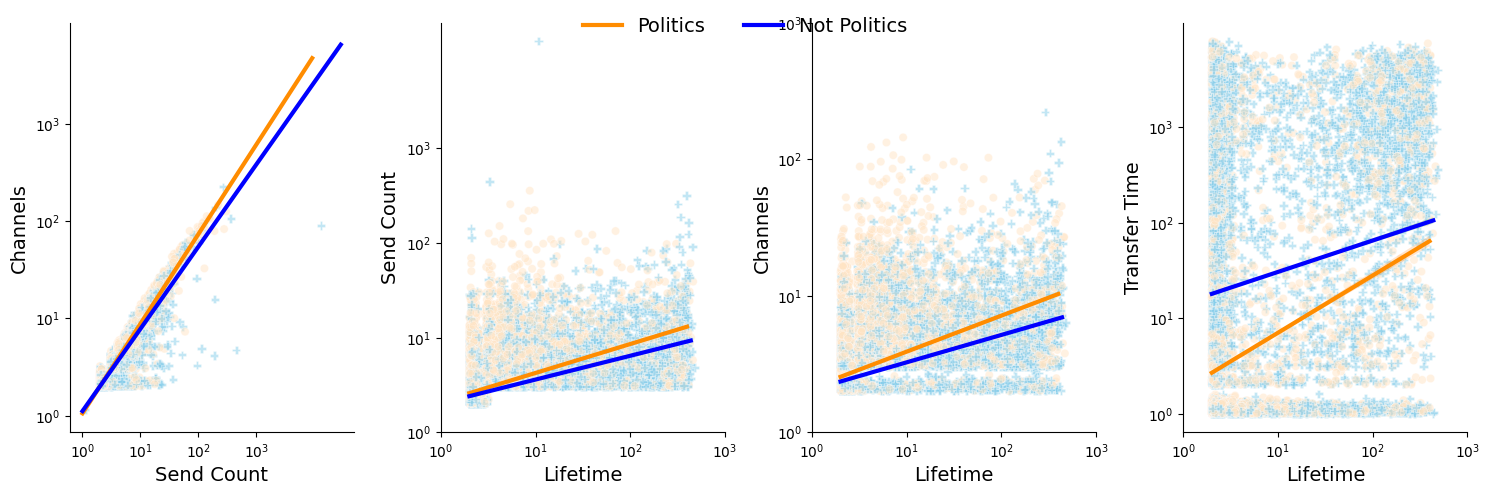

In [ ]:
pairs = [
    ('send_count', 'channels'),
    ('lifetime', 'send_count'),
    ('lifetime', 'channels'),
    ('lifetime', 'transfer_time')
]

sigma = 0.05

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):

    df_resumo_logged = np.log10(df_resumo[[xcol, ycol]]+1).iloc[::10]
    df_politics_logged = np.log10(df_politics[[xcol, ycol]]+1)
    df_non_politics_logged = np.log10(df_non_politics[[xcol, ycol]]+1)

    # mesmo jitter que você usa
    df_resumo_logged += np.abs(
        np.random.normal(0, sigma, size=df_resumo_logged.shape)
    )

    sns.scatterplot(
        data=df_resumo_logged,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::10],
        style=df_resumo['Politics'].iloc[::10],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.5,
        sizes=1,
        palette=['skyblue','bisque'],
        markers={True:'o', False:'P'},
        legend=False
    )

    fit_line_with_ci(
        ax,
        df_politics_logged[xcol].to_numpy(),
        df_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='darkorange',
        lw=3
    )

    fit_line_with_ci(
        ax,
        df_non_politics_logged[xcol].to_numpy(),
        df_non_politics_logged[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='blue',
        lw=3
    )

    # ticks no MESMO formato do seu gráfico
    ax.set_xticks(range(4), [rf'$10^{i}$' for i in range(4)])
    ax.set_yticks(range(4), [rf'$10^{i}$' for i in range(4)])

    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=14)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# legenda única
legend_elements = [
    Line2D([0], [0], color='darkorange', lw=3, label='Politics'),
    Line2D([0], [0], color='blue', lw=3, label='Not Politics')
]

fig.legend(
    handles=legend_elements,
    fontsize=14,
    frameon=False,
    loc='upper center',
    ncol=2
)

plt.tight_layout()
plt.show()


/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.values, **kwargs)
/home/uselection/miniconda3/envs/rapids-24.08/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log10
  result = func(self.val

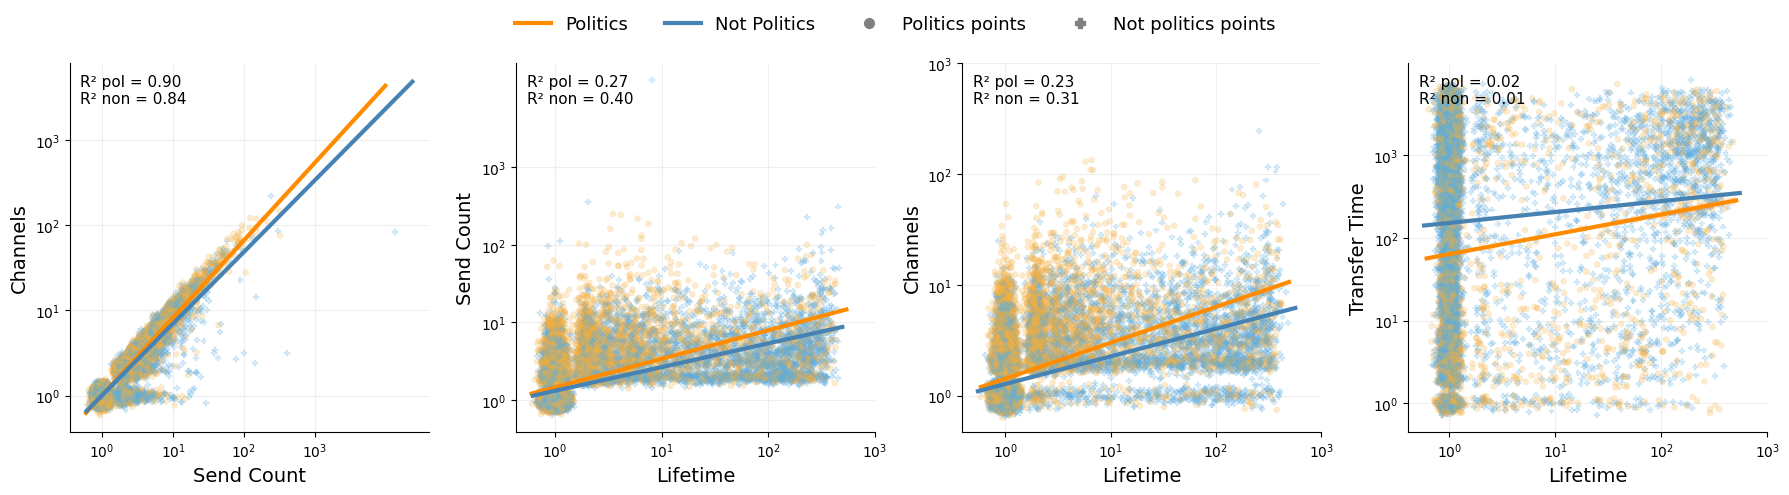

In [ ]:
pairs = [
    ('send_count', 'channels'),
    ('lifetime', 'send_count'),
    ('lifetime', 'channels'),
    ('lifetime', 'transfer_time')
]

sigma = 0.05

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=False, sharey=False)

for ax, (xcol, ycol) in zip(axes, pairs):

    df_all = np.log10(df_resumo[[xcol, ycol]]).iloc[::10].copy()
    pol = np.log10(df_politics[[xcol, ycol]])
    non = np.log10(df_non_politics[[xcol, ycol]])

    # limpa valores inválidos do log
    pol = pol.replace([np.inf, -np.inf], np.nan).dropna()
    non = non.replace([np.inf, -np.inf], np.nan).dropna()

    # jitter consistente (após limpar)
    df_all += np.random.normal(0, sigma, df_all.shape)
    pol    += np.random.normal(0, sigma, pol.shape)
    non    += np.random.normal(0, sigma, non.shape)

    sns.scatterplot(
        data=df_all,
        x=xcol,
        y=ycol,
        hue=df_resumo['Politics'].iloc[::10],
        style=df_resumo['Politics'].iloc[::10],
        hue_order=[False, True],
        style_order=[False, True],
        ax=ax,
        alpha=0.25,
        s=18,
        palette=['#5DADE2', '#F5B041'],
        markers={True: 'o', False: 'P'},
        legend=False,
        edgecolor=None,
        zorder=1
    )

    # regressões
    fit_line_with_ci(
        ax,
        pol[xcol].to_numpy(),
        pol[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='darkorange',
        lw=3,
        zorder=3
    )

    fit_line_with_ci(
        ax,
        non[xcol].to_numpy(),
        non[ycol].to_numpy(),
        ci=99,
        n_boot=1000,
        color='steelblue',
        lw=3,
        zorder=3
    )

    # R² simples
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score

    r2_pol = r2_score(
        pol[ycol],
        LinearRegression().fit(pol[[xcol]], pol[ycol]).predict(pol[[xcol]])
    )

    r2_non = r2_score(
        non[ycol],
        LinearRegression().fit(non[[xcol]], non[ycol]).predict(non[[xcol]])
    )

    ax.text(
        0.03, 0.97,
        f'R² pol = {r2_pol:.2f}\nR² non = {r2_non:.2f}',
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=11
    )

    # ticks no mesmo formato
    ax.set_xticks(range(4), [rf'$10^{i}$' for i in range(4)])
    ax.set_yticks(range(4), [rf'$10^{i}$' for i in range(4)])

    ax.set_xlabel(xcol.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel(ycol.replace('_', ' ').title(), fontsize=14)

    ax.grid(True, which='major', alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)


legend_elements = [
    Line2D([0], [0], color='darkorange', lw=3, label='Politics'),
    Line2D([0], [0], color='steelblue', lw=3, label='Not Politics'),
    Line2D([0], [0], marker='o', color='gray', linestyle='None',
           markersize=7, label='Politics points'),
    Line2D([0], [0], marker='P', color='gray', linestyle='None',
           markersize=7, label='Not politics points')
]

fig.legend(
    handles=legend_elements,
    fontsize=13,
    frameon=False,
    loc='upper center',
    ncol=4
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### Estudo aprofundado dos canais

In [ ]:
import pandas as pd

# 2. Agrupamento (Seu código original)
df_folders = df_complete.groupby('folder').agg({
    'video_id': list,             
    'macrotopic_pred': list,       
    'perspective_toxicity': list   
}).reset_index()

# Conta ocorrências
df_folders['occurrences'] = df_folders['video_id'].apply(len)

# Define tópico dominante
df_folders['dominant_topic'] = df_folders['macrotopic_pred'].apply(
    lambda x: max(set(x), key=x.count) if len(x) > 0 else None
)

def classify_category(topic_list):
    # Conta quantos tópicos da lista são políticos
    politic_count = sum(1 for topic in topic_list if topic in politics)
    
    # O resto é não político
    n_politic_count = len(topic_list) - politic_count
    
    # Lógica de maioria
    if politic_count >= n_politic_count:
        return "Politics"
    else:
        return "Non-Politics"

df_folders['category'] = df_folders['macrotopic_pred'].apply(classify_category)


df_folders = df_folders[[
    'folder', 
    'category',       
    'occurrences', 
    'dominant_topic', 
    'video_id', 
    'macrotopic_pred', 
    'perspective_toxicity'
]]

print(f"Canais processados: {len(df_folders)}")
display(df_folders.head())

Canais processados: 10262


,folder,category,occurrences,dominant_topic,video_id,macrotopic_pred,perspective_toxicity
0,channel_1001310691,Politics,2,War,"[lKK_YLquO-g, LvJv0KJ71Tw]","[War, War]","[0.019477395, 0.033101376]"
1,channel_1002274566,Non-Politics,31,Health,"[f_rSZPbsAOU, aw9-4BnvCQU, D2rjUsENX-A, 9BGzo2...","[Hobbies, Religion, Health, Religion, Religion...","[0.008213525, 0.0060272217, 0.012756908, 0.002..."
2,channel_1002292300,Non-Politics,1,Religion,[LoZm7Mm54vM],[Religion],[0.078392304]
3,channel_1002338106,Non-Politics,2,Religion,"[XwQDEzpnYkk, QPUzlU1HspY]","[Religion, Religion]","[0.024378212, 0.012641981]"
4,channel_1002628191,Politics,44,War,"[5uc00cuUfLo, NI7SuYAHf6o, MPEJbACUHzc, MPEJbA...","[War, War, Religion, Religion, War, Religion, ...","[0.47119883, 0.30256465, 0.07016616, 0.0701661..."


In [ ]:
df_unique_videos = df_complete.drop_duplicates(subset=['folder', 'video_id']).copy()

df_folders_unique = df_unique_videos.groupby('folder').agg({
    'video_id': list,             
    'macrotopic_pred': list,       
    'perspective_toxicity': list   
}).reset_index()

df_folders_unique['occurrences'] = df_folders_unique['video_id'].apply(len)

df_folders_unique['dominant_topic'] = df_folders_unique['macrotopic_pred'].apply(
    lambda x: max(set(x), key=x.count) if len(x) > 0 else None
)

def classify_category(topic_list):
    politic_count = sum(1 for topic in topic_list if topic in politics)
    n_politic_count = len(topic_list) - politic_count
    
    return "Politics" if politic_count > n_politic_count else "Non-Politics"

df_folders_unique['category'] = df_folders_unique['macrotopic_pred'].apply(classify_category)

df_folders_unique = df_folders_unique[[
    'folder', 
    'category',
    'occurrences', 
    'dominant_topic', 
    'video_id', 
    'macrotopic_pred', 
    'perspective_toxicity'
]]


print(f"Total de Canais: {len(df_folders_unique)}")
print(f"Total de Envios (Dataset Original): {df_folders['occurrences'].sum()}")
print(f"Total de Vídeos Únicos (Novo Dataset): {df_folders_unique['occurrences'].sum()}")
print(f"Redução de volume: {df_folders['occurrences'].sum() - df_folders_unique['occurrences'].sum()} envios repetidos removidos.")


Total de Canais: 10262
Total de Envios (Dataset Original): 851211
Total de Vídeos Únicos (Novo Dataset): 684996
Redução de volume: 166215 envios repetidos removidos.


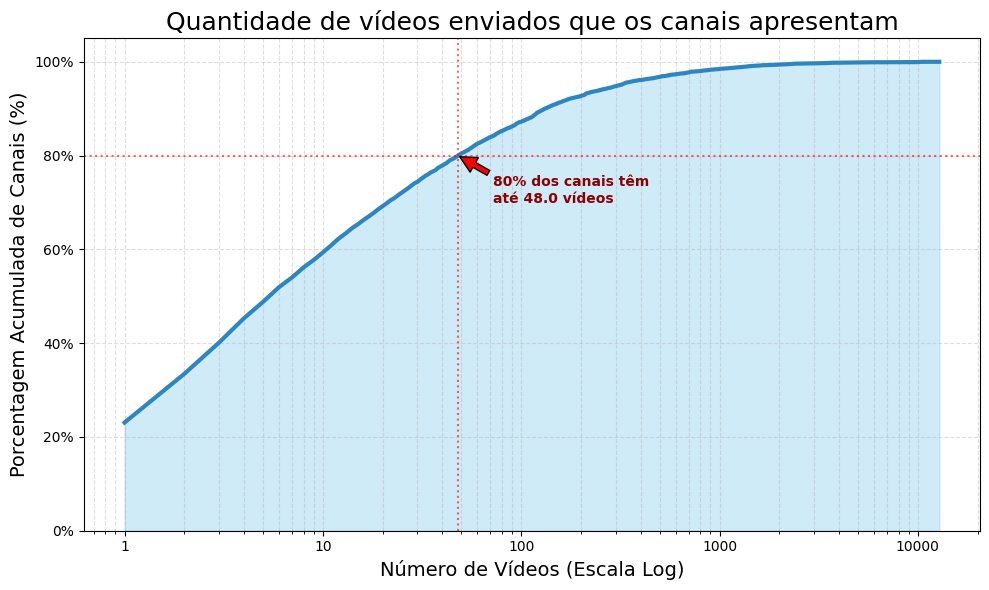

--- Marcos Cumulativos ---
50% dos canais têm até: 5.0 vídeos
80% dos canais têm até: 48.0 vídeos
95% dos canais têm até: 313.0 vídeos


,Num_Videos,Porcentagem,Acumulado
0,1,23.065679,23.065679
1,2,10.378094,33.443773
2,3,6.694601,40.138375
3,4,5.164685,45.303060
4,5,3.517833,48.820893
...,...,...,...
690,10195,0.009745,99.961021
691,10341,0.009745,99.970766
692,10348,0.009745,99.980511
693,10387,0.009745,99.990255


In [ ]:
from matplotlib.ticker import PercentFormatter, ScalarFormatter

# --- 1. PREPARAÇÃO DOS DADOS (Acumulado) ---
# Conta % de cada quantidade
df_dist = df_folders['occurrences'].value_counts(normalize=True).sort_index() * 100
df_dist = df_dist.reset_index()
df_dist.columns = ['Num_Videos', 'Porcentagem']
df_dist['Acumulado'] = df_dist['Porcentagem'].cumsum()

# --- 2. PLOTAGEM ---
plt.figure(figsize=(10, 6))

# Gráfico de Linha Preenchida (Area Plot) fica visualmente melhor para acumulados
plt.fill_between(df_dist['Num_Videos'], df_dist['Acumulado'], color="skyblue", alpha=0.4)
sns.lineplot(data=df_dist,x='Num_Videos',y='Acumulado',color='#2E86C1',linewidth=3)

# --- 3. FORMATAÇÃO ---
plt.xscale('log') # Log no X para ver os detalhes do começo
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.title('Quantidade de vídeos enviados que os canais apresentam', fontsize=18)
plt.ylabel('Porcentagem Acumulada de Canais (%)', fontsize=14)
plt.xlabel('Número de Vídeos (Escala Log)', fontsize=14)

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.ylim(0, 105) # Garante que vai até 100%

# --- 4. LINHAS DE REFERÊNCIA (Para Análise) ---
# Vamos encontrar onde cruzamos 80% e 90% dos canais
# (Isso ajuda a dizer: "90% dos canais têm menos de X vídeos")

# Função auxiliar para achar o valor mais próximo
def find_nearest(array, value):         
    idx = (np.abs(array - value)).argmin()
    return idx

# Marco de 80%
idx_80 = find_nearest(df_dist['Acumulado'].values, 80)
val_80 = df_dist.iloc[idx_80]['Num_Videos']
pct_80 = df_dist.iloc[idx_80]['Acumulado']

plt.axhline(pct_80, color='red', linestyle=':', alpha=0.6)
plt.axvline(val_80, color='red', linestyle=':', alpha=0.6)

plt.annotate(f'80% dos canais têm\naté {val_80} vídeos', 
             xy=(val_80, pct_80), 
             xytext=(val_80 * 1.5, pct_80 - 10),
             arrowprops=dict(facecolor='red', shrink=0.05),
             color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

print("--- Marcos Cumulativos ---")
print(f"50% dos canais têm até: {df_dist.iloc[find_nearest(df_dist['Acumulado'].values, 50)]['Num_Videos']} vídeos")
print(f"80% dos canais têm até: {val_80} vídeos")
print(f"95% dos canais têm até: {df_dist.iloc[find_nearest(df_dist['Acumulado'].values, 95)]['Num_Videos']} vídeos")

df_dist

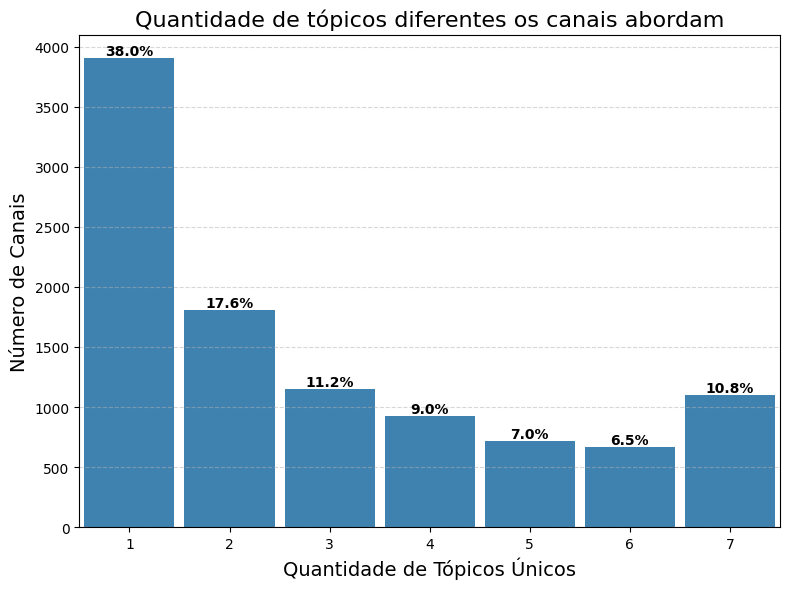

--- Estatísticas de Diversidade de Conteúdo ---
Canais Monotemáticos (Apenas 1 assunto): 3902 (38.0%)
Média de tópicos por canal: 2.92


In [ ]:
df_folders['num_unique_topics'] = df_folders['macrotopic_pred'].apply(lambda x: len(set(x)))

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=df_folders, 
    x='num_unique_topics', 
    color='#2E86C1',
    width=0.9           
)

total = len(df_folders)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Quantidade de tópicos diferentes os canais abordam', fontsize=16)
plt.xlabel('Quantidade de Tópicos Únicos', fontsize=14)
plt.ylabel('Número de Canais', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- 4. ESTATÍSTICAS REAIS ---
print("--- Estatísticas de Diversidade de Conteúdo ---")
monotematicos = len(df_folders[df_folders['num_unique_topics'] == 1])
print(f"Canais Monotemáticos (Apenas 1 assunto): {monotematicos} ({monotematicos/total:.1%})")
print(f"Média de tópicos por canal: {df_folders['num_unique_topics'].mean():.2f}")

<Figure size 1400x800 with 0 Axes>

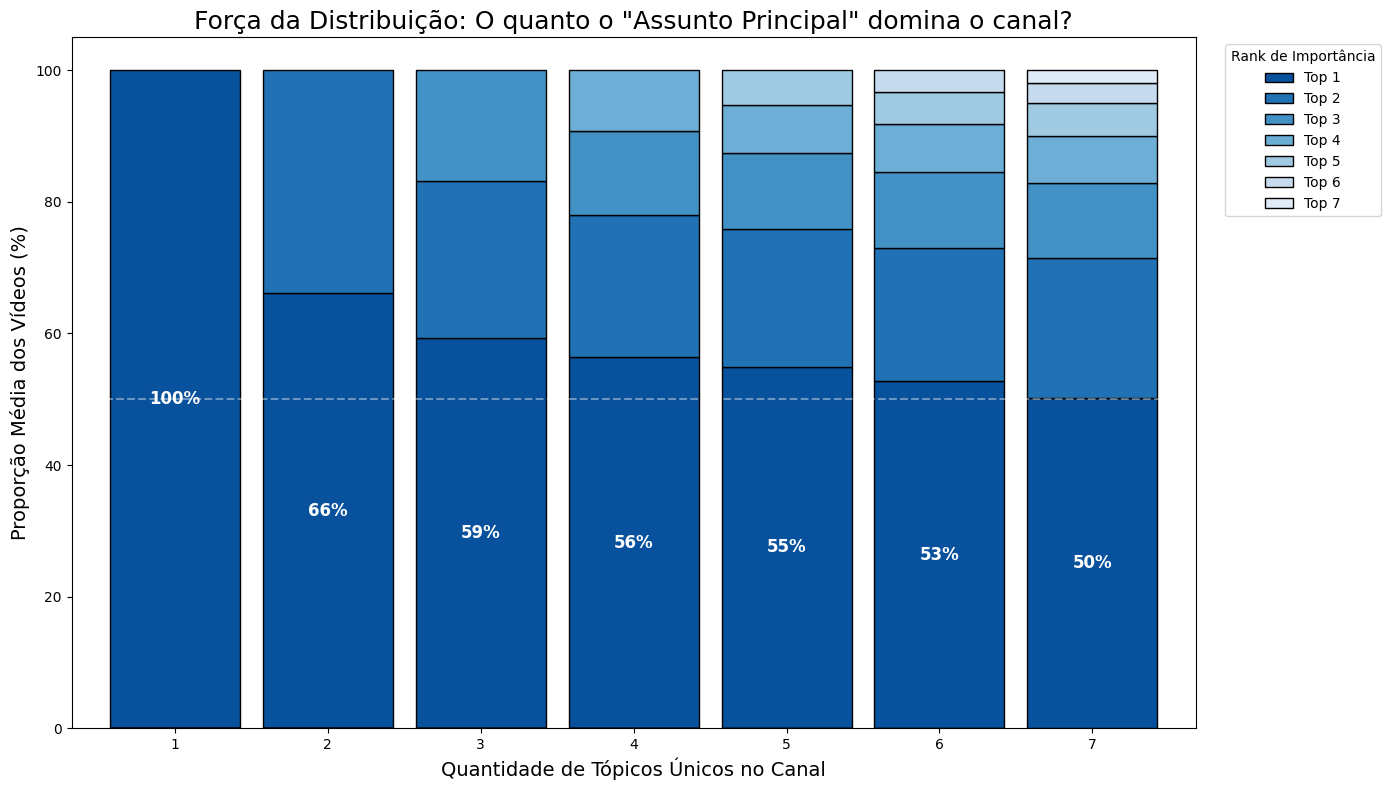

--- Tabela de Dominância (Top 1 vs O Resto) ---


,Top 1,Top 2,Top 3,Outros
num_unique_topics,,,,
1,100.0,NaN,NaN,0.0
2,66.1,33.9,NaN,0.0
3,59.4,23.9,16.8,0.0
4,56.4,21.6,12.7,9.2
5,54.9,20.9,11.7,12.5
6,52.7,20.2,11.6,15.5
7,50.2,21.2,11.3,17.2


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. PREPARAÇÃO DOS DADOS ---

# [CORREÇÃO CRÍTICA]: Garante que a coluna 'num_unique_topics' existe antes de usar
df_folders_unique['num_unique_topics'] = df_folders_unique['macrotopic_pred'].apply(lambda x: len(set(x)))

def get_topic_ranks(topic_list):
    if not isinstance(topic_list, list) or not topic_list:
        return []
    
    # Conta a frequência e normaliza
    counts = pd.Series(topic_list).value_counts(normalize=True)
    return counts.values

# Aplica a função
ranks_series = df_folders_unique['macrotopic_pred'].apply(get_topic_ranks)

# Cria o DataFrame de Ranks expandido
df_ranks = pd.DataFrame(ranks_series.tolist())

# Renomeia colunas (Top 1, Top 2...)
df_ranks.columns = [f'Top {i+1}' for i in range(df_ranks.shape[1])]

# Adiciona a coluna de agrupamento (agora garantimos que ela existe)
# Usamos .values para garantir que o numpy array seja atribuído sem problemas de índice
df_ranks['num_unique_topics'] = df_folders_unique['num_unique_topics'].values

# --- 2. CÁLCULO DA MÉDIA POR GRUPO ---

# Agrupa e calcula média
df_distribution = df_ranks.groupby('num_unique_topics').mean() * 100

# Limpeza: Remove colunas que são totalmente vazias (ex: Top 50 que ninguém tem)
df_distribution = df_distribution.dropna(axis=1, how='all')

# Filtro estético: Mantemos apenas até o Top 10 para o gráfico não ficar ilegível
# (Opcional, mas recomendado se tiver muitos tópicos irrelevantes)
df_distribution = df_distribution.iloc[:, :10]

# --- 3. VISUALIZAÇÃO ---

# Cores: Azul escuro para o Top 1, ficando mais claro
colors = sns.color_palette("Blues_r", n_colors=len(df_distribution.columns))

plt.figure(figsize=(14, 8))

ax = df_distribution.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8),
    color=colors,
    edgecolor='black',
    width=0.85
)

plt.title('Força da Distribuição: O quanto o "Assunto Principal" domina o canal?', fontsize=18)
plt.xlabel('Quantidade de Tópicos Únicos no Canal', fontsize=14)
plt.ylabel('Proporção Média dos Vídeos (%)', fontsize=14)
plt.xticks(rotation=0)

# Legenda fora do gráfico
plt.legend(title="Rank de Importância", bbox_to_anchor=(1.02, 1), loc='upper left')

# Linha de referência visual
plt.axhline(50, color='white', linestyle='--', alpha=0.4)

# Adicionar rótulos APENAS na barra "Top 1" (A barra base, azul escura)
# Isso limpa a visualização
for c in ax.containers:
    # O label do container corresponde ao nome da coluna ('Top 1', 'Top 2'...)
    if c.get_label() == 'Top 1':
        ax.bar_label(c, fmt='%.0f%%', label_type='center', color='white', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 4. VISÃO TABULAR ---
print("--- Tabela de Dominância (Top 1 vs O Resto) ---")
summary = df_distribution.iloc[:, :3].copy() # Mostra Top 1, 2 e 3
summary['Outros'] = 100 - summary.sum(axis=1) # O que sobrou
display(summary.round(1))

<Figure size 1600x1000 with 0 Axes>

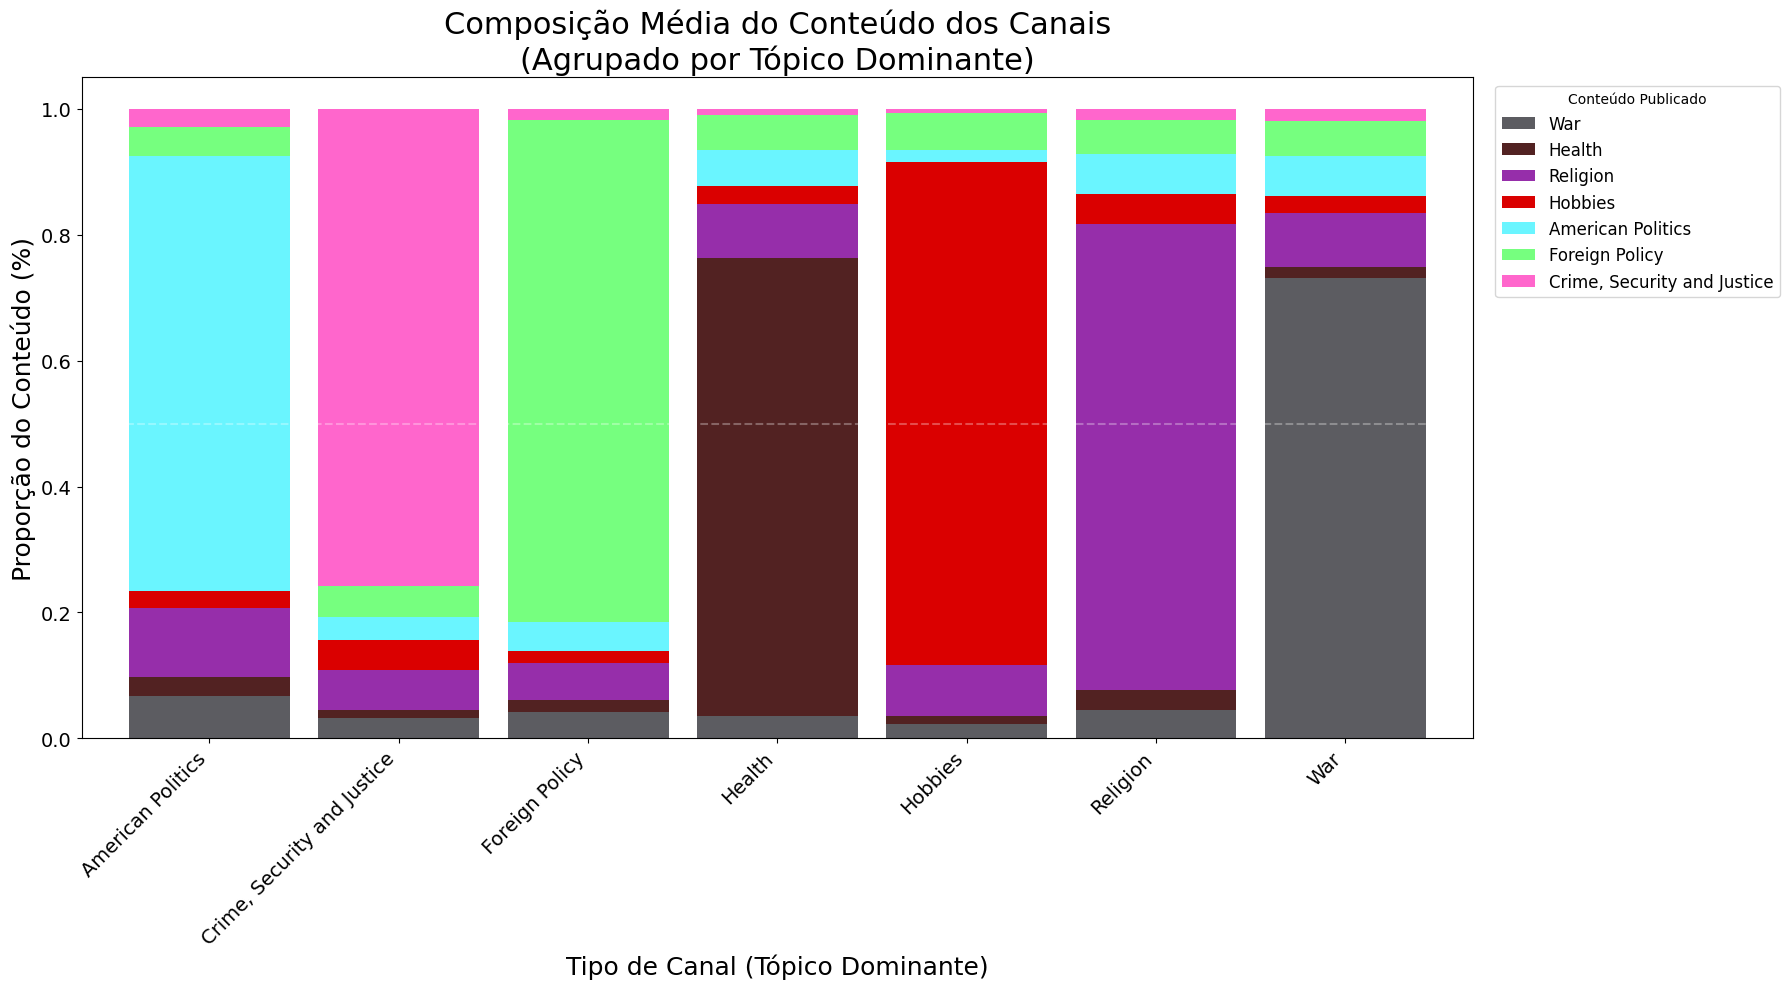

Tabela de 'Contaminação' de Temas (Quem fala sobre o quê?):


/tmp/ipykernel_985092/3288929497.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(grouped_composition.applymap(lambda x: f"{x:.1%}" if x > 0.05 else "-"))


,War,Health,Religion,Hobbies,American Politics,Foreign Policy,"Crime, Security and Justice"
Dominant Group,,,,,,,
American Politics,6.7%,-,11.0%,-,69.1%,-,-
"Crime, Security and Justice",-,-,6.3%,-,-,-,75.8%
Foreign Policy,-,-,5.9%,-,-,79.8%,-
Health,-,72.9%,8.5%,-,5.7%,5.6%,-
Hobbies,-,-,8.0%,79.9%,-,5.9%,-
Religion,-,-,74.0%,-,6.2%,5.4%,-
War,73.1%,-,8.6%,-,6.2%,5.6%,-


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. EXPANDIR A LISTA EM PORCENTAGENS ---

# Função para transformar a lista ['Politics', 'Politics', 'War'] em {'Politics': 0.66, 'War': 0.33}
def get_topic_percentages(topic_list):
    if not topic_list:
        return {}
    
    total = len(topic_list)
    # Conta ocorrências
    counts = pd.Series(topic_list).value_counts()
    # Normaliza para % (0 a 1)
    return (counts / total).to_dict()

# Aplica a função em cada linha
# Isso cria uma série de dicionários
topic_dicts = df_folders_unique['macrotopic_pred'].apply(get_topic_percentages)

# Transforma a série de dicionários em um DataFrame expandido
# (Cada tópico vira uma coluna, preenchida com 0 onde não aparece)
df_composition = pd.DataFrame(list(topic_dicts)).fillna(0)

# Adiciona o Tópico Dominante (para podermos agrupar)
# Certifique-se que df_folders e df_composition estão alinhados pelo índice (reset_index ajuda)
df_composition['Dominant Group'] = df_folders_unique['dominant_topic'].values

# --- 2. AGRUPAR E CALCULAR A MÉDIA ---

# Agrupa pelos canais do mesmo tipo e tira a média da composição deles
# Ex: Pega todos os canais de "Religion" e vê quanto eles falam de "Politics" em média
grouped_composition = df_composition.groupby('Dominant Group').mean()
 
# --- 3. PLOTAGEM (BARRAS EMPILHADAS) ---

# Garante que a ordem das cores bate com as colunas do dataframe agrupado
plot_colors = [macro_colors.get(col, '#333333') for col in grouped_composition.columns]

plt.figure(figsize=(16, 10))

# O plot do Pandas já faz o empilhamento automático
ax = grouped_composition.plot(
    kind='bar', 
    stacked=True, 
    figsize=(18, 10),
    color=plot_colors,
    width=0.85
)

plt.title('Composição Média do Conteúdo dos Canais\n(Agrupado por Tópico Dominante)', fontsize=22)
plt.xlabel('Tipo de Canal (Tópico Dominante)', fontsize=18)
plt.ylabel('Proporção do Conteúdo (%)', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(fontsize=14)

# Legenda externa para não poluir
plt.legend(title="Conteúdo Publicado", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

# Adiciona linha de 50% para referência visual
plt.axhline(0.5, color='white', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- 4. VISÃO NUMÉRICA (Opcional) ---
print("Tabela de 'Contaminação' de Temas (Quem fala sobre o quê?):")
# Mostra valores acima de 5% apenas para limpar a visão
display(grouped_composition.applymap(lambda x: f"{x:.1%}" if x > 0.05 else "-"))

Clusterização concluída sem erros!


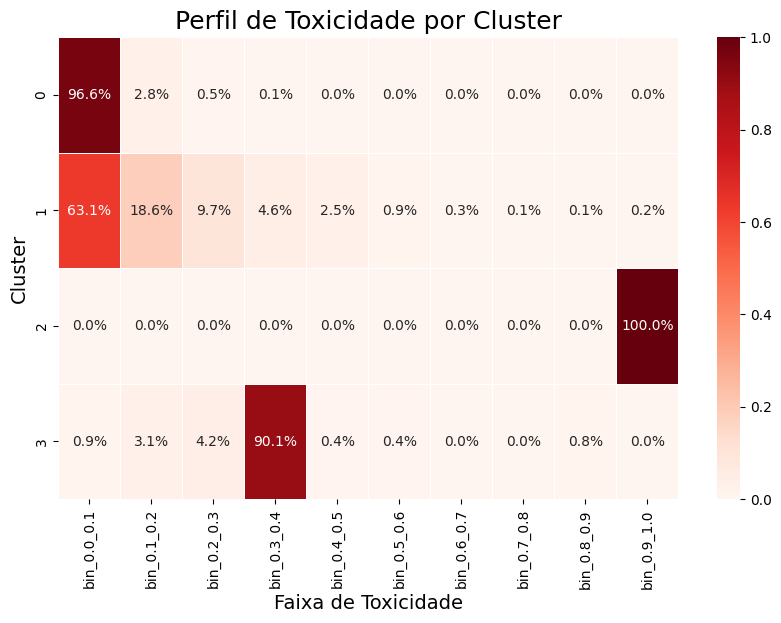

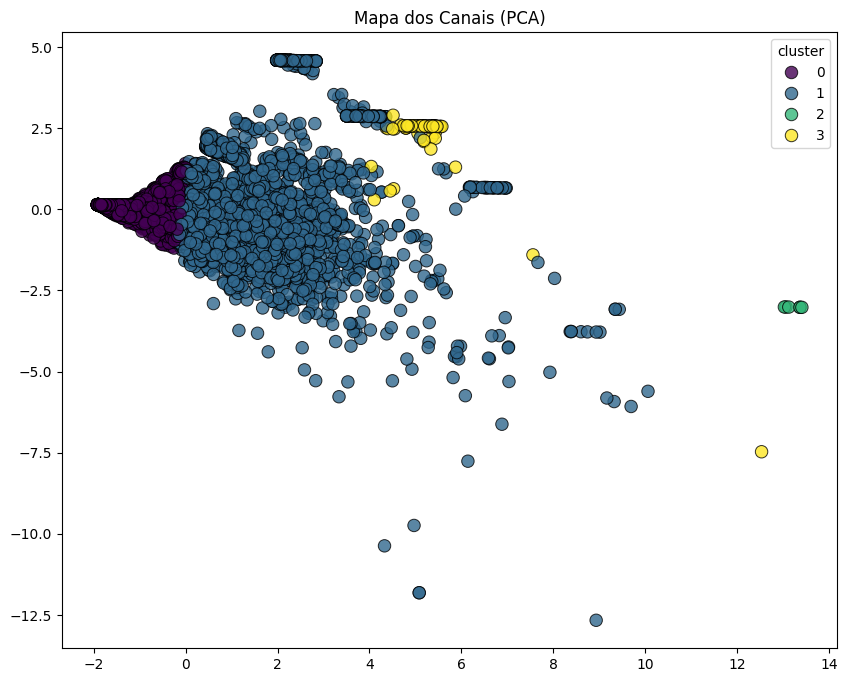

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1. FUNÇÃO BLINDADA CONTRA ERROS ---
def extract_granular_features(toxicity_list):
    # Verifica se é lista válida
    if not isinstance(toxicity_list, list):
        return pd.Series([0]*13)
    
    # [CORREÇÃO CRÍTICA]: Remove valores nulos (NaN) de DENTRO da lista
    # Se um vídeo falhou na coleta, ele não deve quebrar a média do canal
    clean_arr = np.array([x for x in toxicity_list if pd.notnull(x)])
    
    # Se após limpar não sobrou nada (canal só tinha erros), retorna zero
    if len(clean_arr) == 0:
        return pd.Series([0]*13)
    
    # 1. Estatísticas Básicas
    stats = [
        np.mean(clean_arr), 
        np.max(clean_arr),  
        np.std(clean_arr)   
    ]
    
    # 2. Criação das Faixas
    counts, _ = np.histogram(clean_arr, bins=10, range=(0, 1))
    props = counts / len(clean_arr)
    
    final_features = stats + list(props)
    return pd.Series(final_features)

# Aplica a função corrigida
features_df = df_folders_unique['perspective_toxicity'].apply(extract_granular_features)

col_names = ['tox_mean', 'tox_max', 'tox_std'] + [f'bin_{i/10:.1f}_{(i+1)/10:.1f}' for i in range(10)]
features_df.columns = col_names

# Junta com os dados originais
df_clustering = pd.concat([df_folders_unique[['folder', 'category' ,'dominant_topic','macrotopic_pred']], features_df], axis=1)

# --- 2. PREPARAÇÃO E LIMPEZA FINAL (AQUI QUEBRAVA) ---

X = df_clustering.drop(columns=['folder', 'dominant_topic', 'category', 'macrotopic_pred'])

# [CORREÇÃO CRÍTICA]: Preenche qualquer buraco que tenha sobrado com 0
X = X.fillna(0)

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# [CORREÇÃO CRÍTICA]: Se o scaler gerou NaN (divisão por zero em colunas constantes), substitui por 0
X_scaled = np.nan_to_num(X_scaled)

# --- 3. CLUSTERIZAÇÃO ---

k = 4 # Tente começar com 4 ou 5, 10 pode ser muito fragmentado para interpretar
kmeans = KMeans(n_clusters=k, random_state=42)
df_clustering['cluster'] = kmeans.fit_predict(X_scaled)

print("Clusterização concluída sem erros!")

# --- 4. VISUALIZAÇÃO (HEATMAP) ---
cluster_profile = df_clustering.groupby('cluster')[col_names].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(
    cluster_profile.iloc[:, 3:], # Pula as stats, mostra só os bins
    annot=True, 
    fmt=".1%", 
    cmap="Reds", 
    linewidths=.5
)
plt.title('Perfil de Toxicidade por Cluster', fontsize=18)
plt.xlabel('Faixa de Toxicidade', fontsize=14)
plt.ylabel('Cluster', fontsize=14)
plt.show()

# --- 5. PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df_clustering['cluster'], 
    palette='viridis', 
    s=80, alpha=0.8, edgecolor='black'
)
plt.title('Mapa dos Canais (PCA)')
plt.show()

Categorias encontradas: ['Politics' 'Non-Politics']


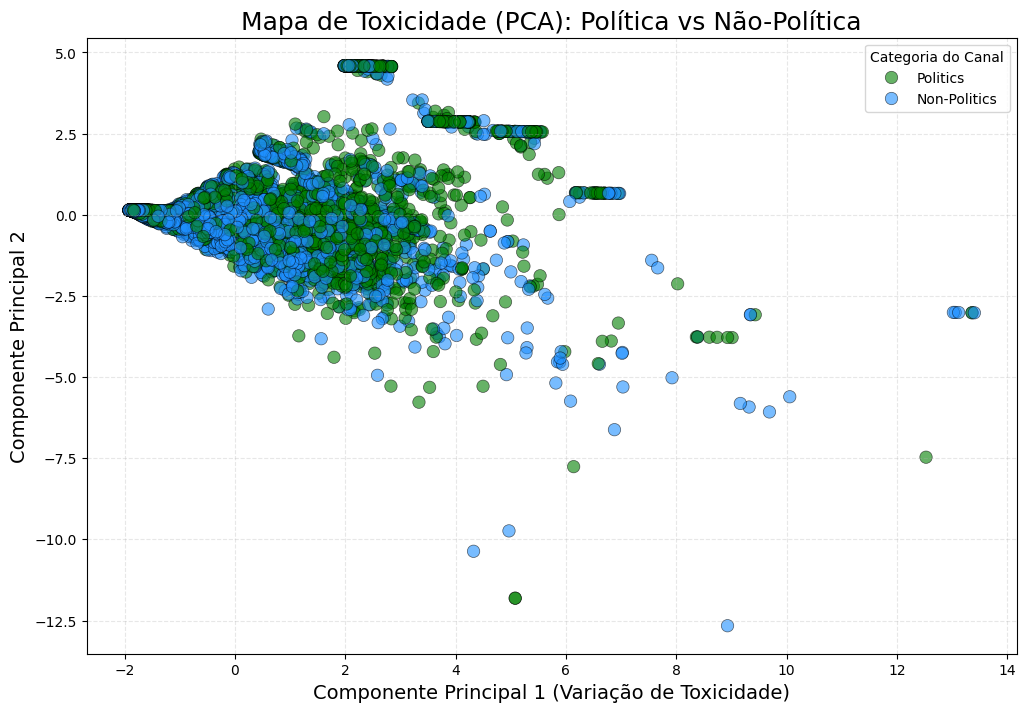

In [ ]:
# --- 5. PCA COM CORES POR CATEGORIA ---

# Primeiro, verifica quais são os nomes exatos que estão na coluna (para evitar erros de digitação)
print("Categorias encontradas:", df_clustering['category'].unique())

# Define as cores manualmente para garantir o padrão que você pediu
# (Adicionei variações de escrita caso seus dados tenham 'Politc' ou 'Politics')
custom_colors = {
    'Politics': 'green',
    'Politc': 'green',         # Caso esteja com o nome antigo
    'Non-Politics': 'dodgerblue',
    'Non_Politics': 'dodgerblue' # Caso esteja com o nome antigo
}

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=df_clustering['category'], # <--- AQUI MUDAMOS DE CLUSTER PARA CATEGORIA
    palette=custom_colors,         # Aplica as cores fixas
    s=80, 
    alpha=0.6,                     # Alpha menor ajuda a ver onde os pontos se sobrepõem
    edgecolor='black',
    linewidth=0.5
)

plt.title('Mapa de Toxicidade (PCA): Política vs Não-Política', fontsize=18)
plt.xlabel('Componente Principal 1 (Variação de Toxicidade)', fontsize=14)
plt.ylabel('Componente Principal 2', fontsize=14)
plt.legend(title='Categoria do Canal')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

<Figure size 1400x900 with 0 Axes>

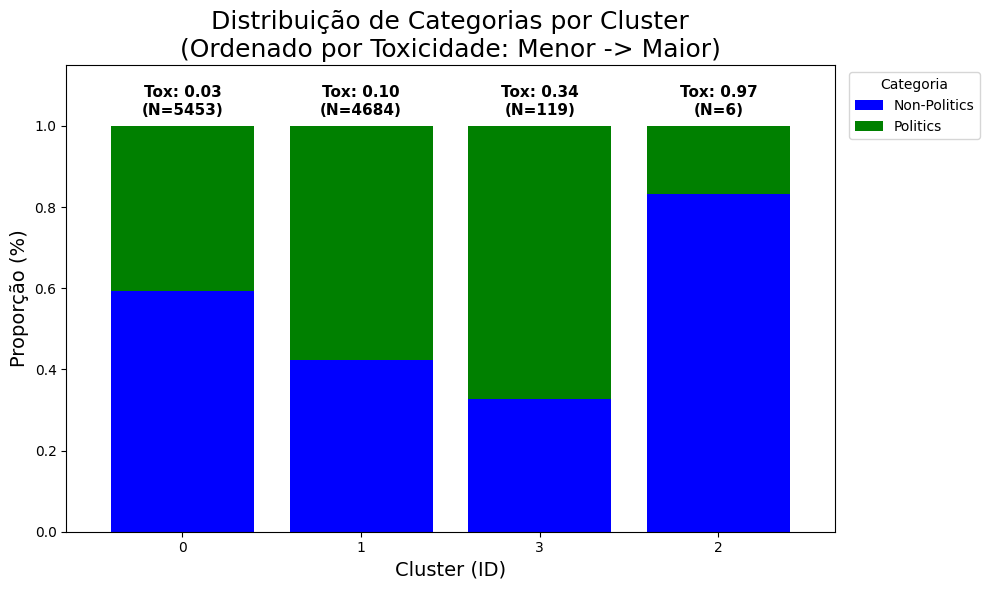


--- RESUMO DETALHADO (COM NÚMERO DE CANAIS) ---


,Toxicidade Média,Total Canais (N),% Politics,% Non-Politics
cluster,,,,
0,0.025827,5453,40.601504,59.398496
1,0.102755,4684,57.749787,42.250213
3,0.343966,119,67.226891,32.773109
2,0.967202,6,16.666667,83.333333



Teste Qui-Quadrado (Chi-Square): P-valor: 4.38235e-68
CONCLUSÃO: Dependência ESTATISTICAMENTE SIGNIFICATIVA entre Cluster e Categoria.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# --- 1. PREPARAÇÃO DOS DADOS ---

# Calcula a toxicidade média para ORDENAÇÃO
cluster_toxicity_order = df_clustering.groupby('cluster')['tox_mean'].mean().sort_values()

# Calcula a CONTAGEM de canais por cluster (Para exibir no gráfico)
cluster_counts = df_clustering['cluster'].value_counts()

# Cria a tabela cruzada
cross_tab = pd.crosstab(df_clustering['cluster'], df_clustering['category'], normalize='index')

# Reordena as linhas da tabela baseada na toxicidade
cross_tab_sorted = cross_tab.reindex(cluster_toxicity_order.index)

# --- 2. VISUALIZAÇÃO ---

colors = {"Politics": "green", "Non-Politics": "blue"}
# Garante que a ordem das cores bate com as colunas (Politics/Non)
plot_colors = [colors.get(c, 'gray') for c in cross_tab_sorted.columns]

plt.figure(figsize=(14, 9)) # Aumentei um pouco a altura para caber o texto

ax = cross_tab_sorted.plot(
    kind='bar', 
    stacked=True, 
    color=plot_colors, 
    figsize=(10, 6),
    width=0.8
)

plt.title('Distribuição de Categorias por Cluster\n(Ordenado por Toxicidade: Menor -> Maior)', fontsize=18)
plt.xlabel('Cluster (ID)', fontsize=14)
plt.ylabel('Proporção (%)', fontsize=14)
plt.xticks(rotation=0)
plt.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')

# --- AQUI ESTÁ A MUDANÇA: Loop de Anotação com N ---
# Iteramos sobre as barras ordenadas
for i, (cluster_idx, row) in enumerate(cross_tab_sorted.iterrows()):
    # Pega os valores correspondentes àquele cluster específico
    tox_val = cluster_toxicity_order[cluster_idx]
    count_val = cluster_counts[cluster_idx] # <--- Pega a quantidade de canais
    
    # Monta o texto: Média em cima, N embaixo
    label_text = f"Tox: {tox_val:.2f}\n(N={count_val})"
    
    # Escreve no gráfico
    plt.text(
        i, 
        1.02, # Posição Y (logo acima da barra de 1.0)
        label_text, 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        fontweight='bold',
        color='black'
    )

# Aumenta o teto do gráfico para o texto não cortar (vai até 1.15 em vez de 1.0)
plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()

# --- 3. ANÁLISE ESTATÍSTICA ---

print("\n--- RESUMO DETALHADO (COM NÚMERO DE CANAIS) ---")

summary_comparison = pd.DataFrame({
    'Toxicidade Média': cluster_toxicity_order,
    'Total Canais (N)': cluster_counts, # Adicionei aqui na tabela também
    '% Politics': cross_tab_sorted['Politics'] * 100, 
    '% Non-Politics': cross_tab_sorted['Non-Politics'] * 100
})

# Reordena o resumo pela toxicidade para bater com o gráfico visualmente
summary_comparison = summary_comparison.reindex(cluster_toxicity_order.index)

display(summary_comparison.style.background_gradient(cmap='Reds', subset=['Toxicidade Média']))

# Teste Qui-Quadrado
contingency_table_raw = pd.crosstab(df_clustering['cluster'], df_clustering['category'])
chi2, p, dof, expected = chi2_contingency(contingency_table_raw)

print(f"\nTeste Qui-Quadrado (Chi-Square): P-valor: {p:.5e}")
if p < 0.05:
    print("CONCLUSÃO: Dependência ESTATISTICAMENTE SIGNIFICATIVA entre Cluster e Categoria.")
else:
    print("CONCLUSÃO: NÃO há evidência estatística.")

In [ ]:
df_folders_unique.columns

Index(['folder', 'category', 'occurrences', 'dominant_topic', 'video_id',
       'macrotopic_pred', 'perspective_toxicity', 'num_unique_topics'],
      dtype='object')

___
## **RQ3 Analise temporal de envio do Telegram**

In [11]:
display(df_complete)

,video_id,text,channel_title,published_at,view_count,like_count,comment_count,toxicity,severe_toxicity,obscene,...,perspective_threat,macrotopic_pred,macrotopic_prob,lifetime,send_count,transfer_time,first_appearance,id,folder,date
0,xrGGce8cmx8,spiritual warfare charge commit unto thee timo...,WWURD,2023-10-18T14:39:18Z,65.0,6.0,1.0,0.295000,0.001137,0.003694,...,0.029415,Religion,0.000000,1.0,1,79.0,2024-01-06,60799.0,channel_1466271872,2024-01-06
1,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.002710,0.000104,0.000254,...,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27,449843.0,channel_1571505334,2024-10-27
2,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.002710,0.000104,0.000254,...,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27,205296.0,channel_1366456452,2024-10-28
3,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.002710,0.000104,0.000254,...,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27,123625.0,channel_2091154967,2024-10-27
4,A59ftbhsQUE,GALACTIC ALLIANCE MESSAGE NEWS REMAIN ALERT PR...,GALACTIC ALLIANCE,2024-10-27T04:30:04Z,806.0,136.0,18.0,0.002710,0.000104,0.000254,...,0.022509,Religion,0.005000,2.0,5,0.0,2024-10-27,462353.0,channel_1548295614,2024-10-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1183488,LwAVckmcj9k,know gaza bible israel jesus palestine youtube...,Aries Entertainment Podcast,2024-03-02T13:50:44Z,4215776.0,NaN,5746.0,0.119244,0.000962,0.007461,...,0.025271,War,0.013086,1.0,1,206.0,2024-09-25,132237.0,channel_1457622198,2024-09-25
1183489,Ty0MUwQ_DEU,white black bible gaza israel jesus palestine ...,Aries Entertainment Podcast,2024-03-02T13:47:14Z,8552948.0,NaN,24602.0,0.523331,0.008716,0.060892,...,0.035113,War,0.008839,1.0,1,20.0,2024-03-23,60381.0,channel_1655299350,2024-03-23
1183490,ABpufr8inCY,eruption kilauea volcano earthquake activity i...,TheEarthMaster,2024-09-17T19:15:25Z,10563.0,712.0,38.0,0.003324,0.000098,0.000358,...,0.008324,Environment,0.000000,1.0,1,0.0,2024-09-17,30195.0,channel_1177617529,2024-09-17
1183491,fNTfEPLoAik,clark county sheriff arrest felony count clark...,WLKY News Louisville,2023-11-09T09:24:16Z,358.0,5.0,NaN,0.007710,0.000096,0.000594,...,0.024235,"Crime, Security and Justice",0.869761,1.0,2,0.0,2023-11-09,86067.0,channel_1172210773,2023-11-09


In [69]:
politics_markers     = ["s", "^", "D", "P", "H", "X"]
non_politics_markers = ["o", "v", "*", "p", "8", "h"]

macro_styles = {}

for i, macro in enumerate(politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": "solid",
        "marker":    politics_markers[i % len(politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

for i, macro in enumerate(non_politics):
    macro_styles[macro] = {
        "color":     macro_colors.get(macro, "#333333"),
        "linestyle": (0, (2, 2)),
        "marker":    non_politics_markers[i % len(non_politics_markers)],
        "markersize": 13,
        "linewidth": 3.5
    }

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import MultipleLocator

def plot_weekly_toxicity_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    # Limpeza e conversão de datas
    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # Manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # Início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # Remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    # Agrupamento pela média de toxicidade
    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # Pegamos o valor da última semana disponível para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        if not m_df.empty:
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = 0
            
    # Reordena a lista baseada nos valores finais (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------------------------

    sns.set(style="whitegrid")
    plt.figure(figsize=(20, 10))
    plt.grid(axis='x', visible=False)
    # Plotagem (usa a lista original para garantir que todas as linhas sejam desenhadas)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style.get("linewidth"),
            marker=style["marker"],
            markersize = style.get("markersize"),
            label=macro
        )

    # Configuração das datas no eixo X
    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(ticks=week_list, labels=labels, rotation=90, fontsize=22)
    plt.yticks(fontsize=25)

    plt.title(f"Weekly Evolution of Toxicity", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Mean Toxicity", fontsize=30)

    plt.ylim(0, 0.18)
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.01))

    handles = [
        Line2D([0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=20, label=m)
        for m in macro_categories_sorted
    ]

    legend = plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    # Ajuste fino do espaçamento interno da legenda
    legend._legend_box.sep = 6

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_toxicity_macros.png")
    plt.show()

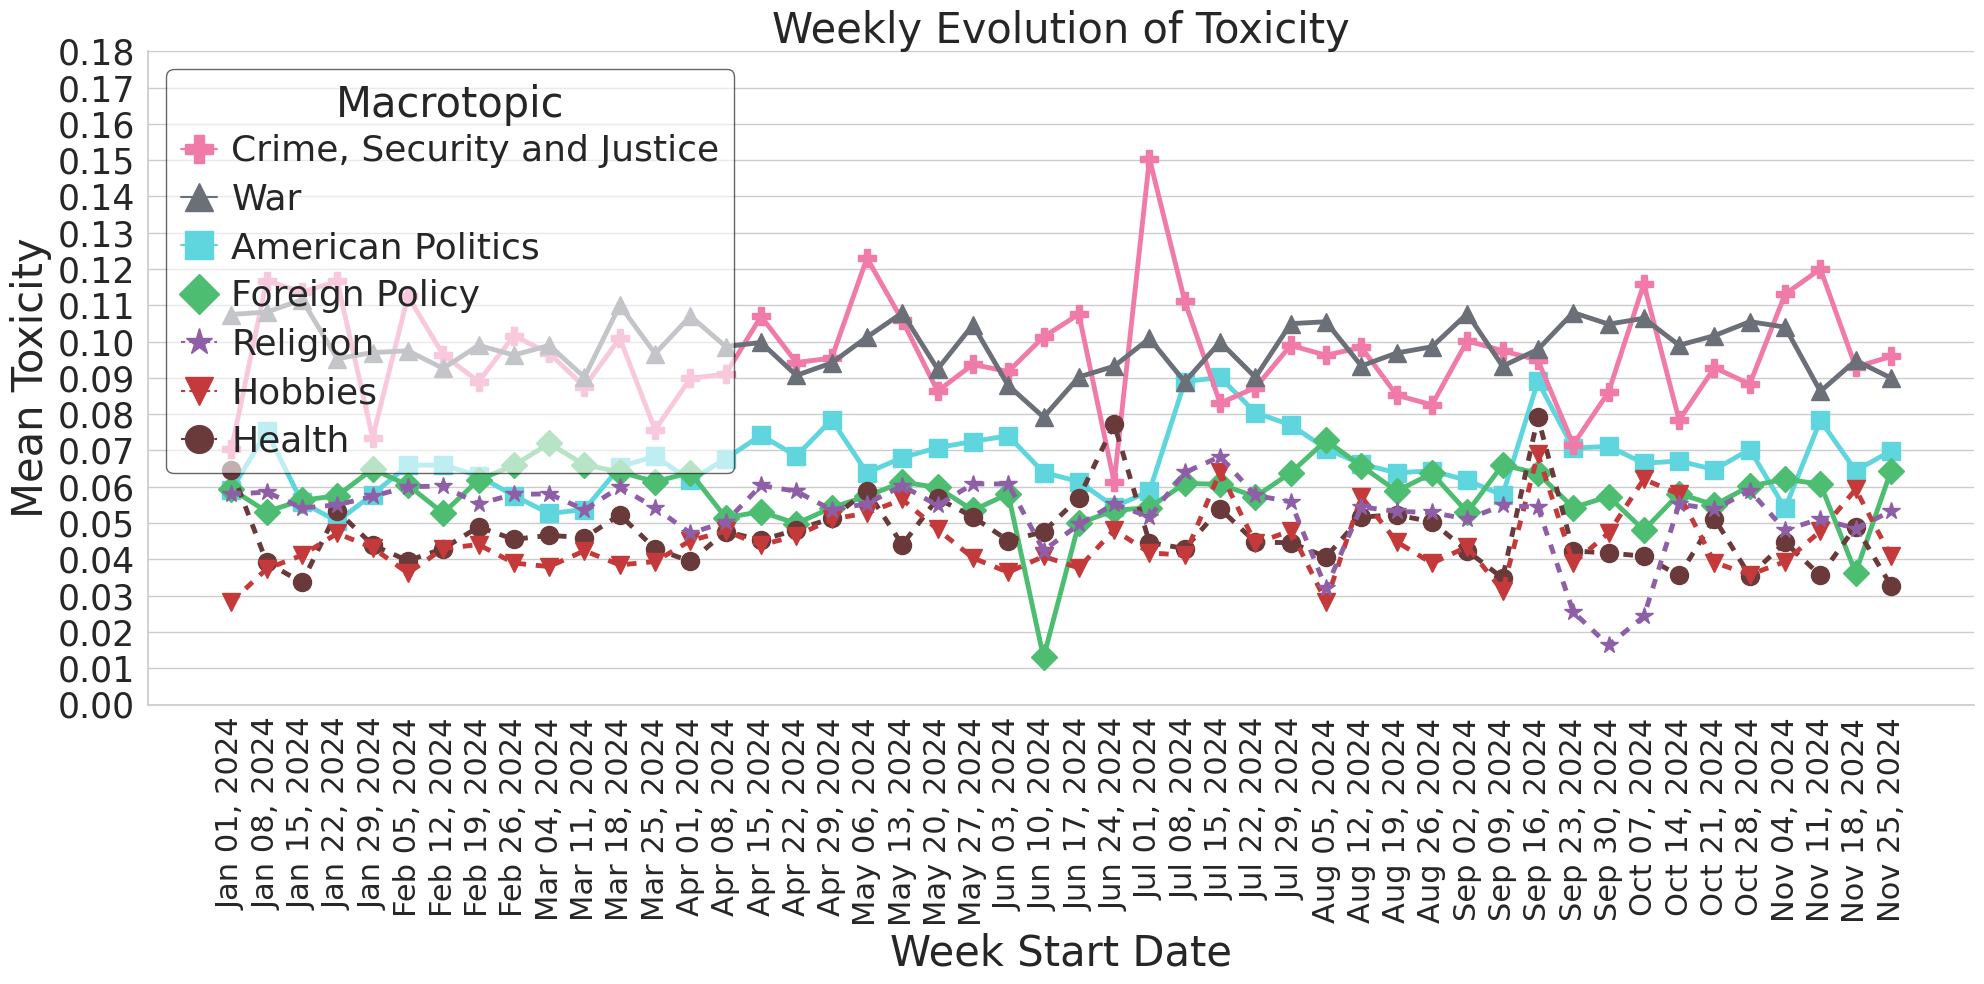

In [222]:
plot_weekly_toxicity_macros(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
)

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch

def plot_weekly_toxicity_macros_v1(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # 🔥 manter apenas uma ocorrência por vídeo
    df = df.drop_duplicates(subset=["video_id"]).copy()

    # início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Vamos pegar o valor da última semana disponível para cada tópico
    # para ordenar a legenda do maior (topo) para o menor (fundo).
    last_week = grouped["week_start"].max()
    
    # Cria um dicionário {topico: valor_ultima_semana}
    # Se um tópico não tiver dados na última semana exata, pegamos o último valor disponível dele.
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Pega o último valor registrado (iloc[-1]) assumindo que o DF está ordenado por data
            # Como agrupamos, garantimos a ordenação:
            m_df = m_df.sort_values("week_start")
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1 # Joga pro final se não tiver dados
            
    # Reordena a lista de categorias baseada nesses valores (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 12))

    # Plotamos usando a lista original ou ordenada (tanto faz pro plot, mas usarei a original para iterar)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            marker="o",
            label=macro,
            color=macro_colors.get(macro, "#333333"),
            linewidth=2
        )

    # 🔥 Datas no padrão inglês
    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(week_list, labels, rotation=90, fontsize=25)
    plt.yticks(fontsize=35)

    plt.title(f"Weekly Evolution of Toxicity — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Mean Toxicity (Unique Videos)", fontsize=30)

    plt.ylim(0, 0.15)

    # Cria handles usando a lista ORDENADA (macro_categories_sorted)
    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=20, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    plt.tight_layout()
    plt.show()

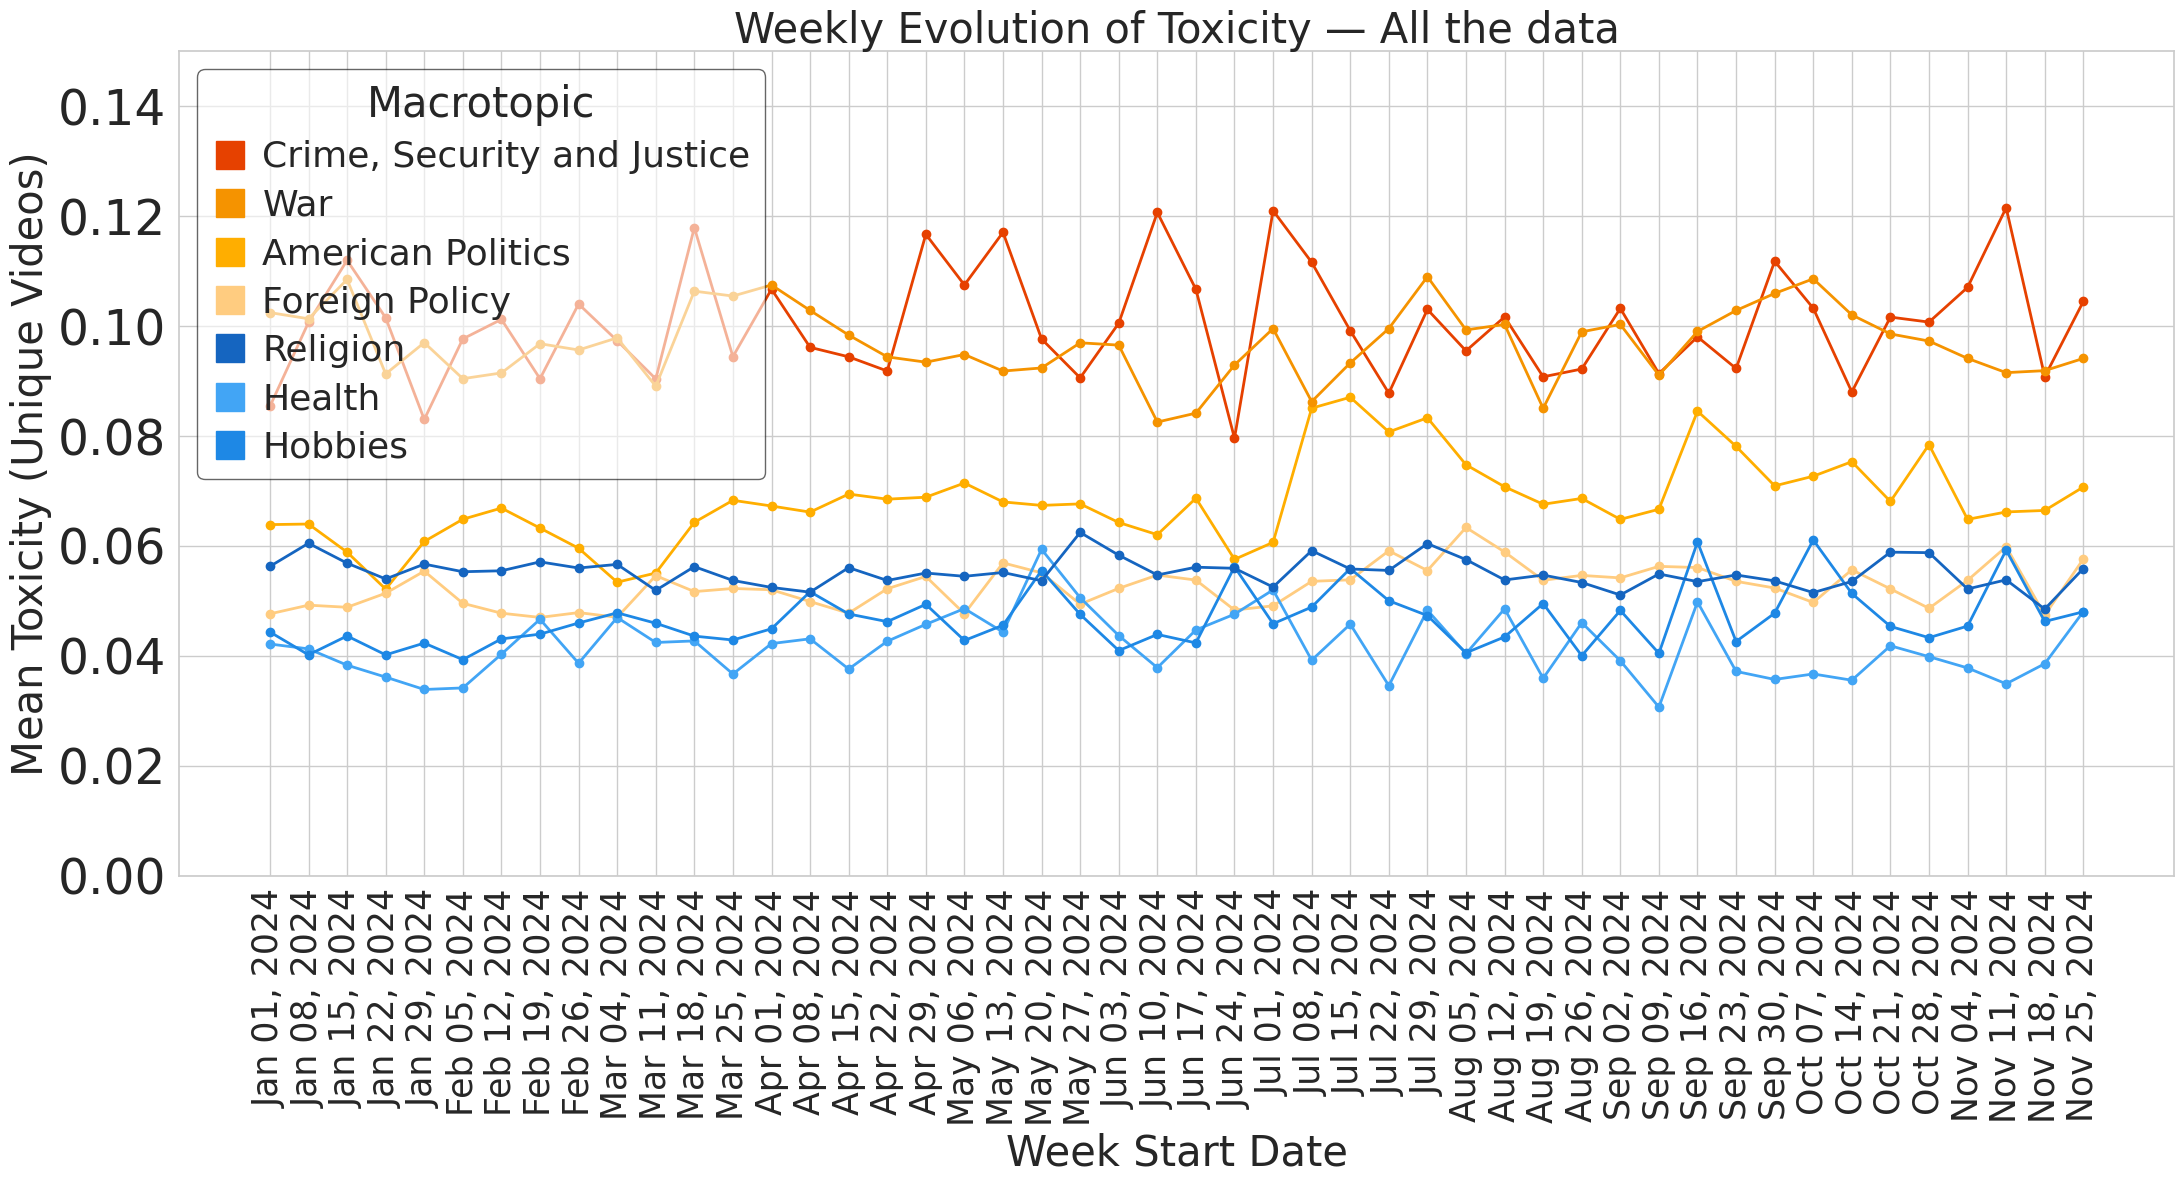

In [79]:
plot_weekly_toxicity_macros_v1(
    df_complete, 
    "All the data", 
    excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
)

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd
from matplotlib.patches import FancyBboxPatch

def plot_weekly_toxicity_macros_v2(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # 🔥 manter apenas uma ocorrência por vídeo
    df = df.drop_duplicates(subset=["video_id"]).copy()

    # início da semana real (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 remover tópicos indesejados
    df = df[~df["macrotopic_pred"].isin(excluded_topics)]

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["perspective_toxicity"]
          .mean()
          .reset_index()
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA ---
    # Vamos pegar o valor da última semana disponível para cada tópico
    # para ordenar a legenda do maior (topo) para o menor (fundo).
    last_week = grouped["week_start"].max()
    
    # Cria um dicionário {topico: valor_ultima_semana}
    # Se um tópico não tiver dados na última semana exata, pegamos o último valor disponível dele.
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Pega o último valor registrado (iloc[-1]) assumindo que o DF está ordenado por data
            # Como agrupamos, garantimos a ordenação:
            m_df = m_df.sort_values("week_start")
            last_val = m_df["perspective_toxicity"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1 # Joga pro final se não tiver dados
            
    # Reordena a lista de categorias baseada nesses valores (Decrescente)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------

    # --- estatísticas globais por macrotópico (ano todo) ---
    stats = (
        df.groupby("macrotopic_pred")["perspective_toxicity"]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean": "global_mean", "std": "global_std"})
    )

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 12))

    # Plotamos usando a lista original ou ordenada (tanto faz pro plot, mas usarei a original para iterar)
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        color = macro_colors.get(macro, "#333333")

        # linha temporal (média semanal)
        plt.plot(
            m_df["week_start"],
            m_df["perspective_toxicity"],
            marker="o",
            color=color,
            linewidth=2,
            zorder=3
        )

        # ---- média e desvio padrão anual do macrotópico ----
        row = stats[stats["macrotopic_pred"] == macro]

        if not row.empty:
            mu  = row["global_mean"].iloc[0]
            sd  = row["global_std"].iloc[0]

            # linha da média anual
            plt.hlines(
                y=mu,
                xmin=m_df["week_start"].min(),
                xmax=m_df["week_start"].max(),
                colors=color,
                linestyles="dashed",
                linewidth=4,
                alpha=1.0,
                zorder=2
            )


    # 🔥 Datas no padrão inglês
    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(week_list, labels, rotation=90, fontsize=25)
    plt.yticks(fontsize=35)

    plt.title(f"Weekly Evolution of Toxicity — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Mean Toxicity (Unique Videos)", fontsize=30)

    # Cria handles usando a lista ORDENADA (macro_categories_sorted)
    handles = [
        Line2D([0], [0], marker="s", linestyle="", 
               color=macro_colors[m], markersize=20, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    plt.ylim(0.03, 0.13)

    plt.tight_layout()
    plt.show()

In [95]:
plot_weekly_toxicity_macros_v2(df_complete, "All the data")

NameError: name 'plot_weekly_toxicity_macros_v2' is not defined

In [232]:
def plot_weekly_video_count_macros_v1(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    grouped = (
        df.groupby(["week_start", "macrotopic_pred"])["video_id"]
          .count()
          .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else 0

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis='x', visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro,
            {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 10),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(week_list, labels, rotation=90, fontsize=22)
    plt.yticks(fontsize=25)
    

    plt.title(f"Weekly Number of Videos", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Number of Videos", fontsize=30)

    plt.ylim(0, 15000)
    plt.gca().yaxis.set_major_locator(MultipleLocator(1500))

    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=20, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_send_count.png")
    plt.show()

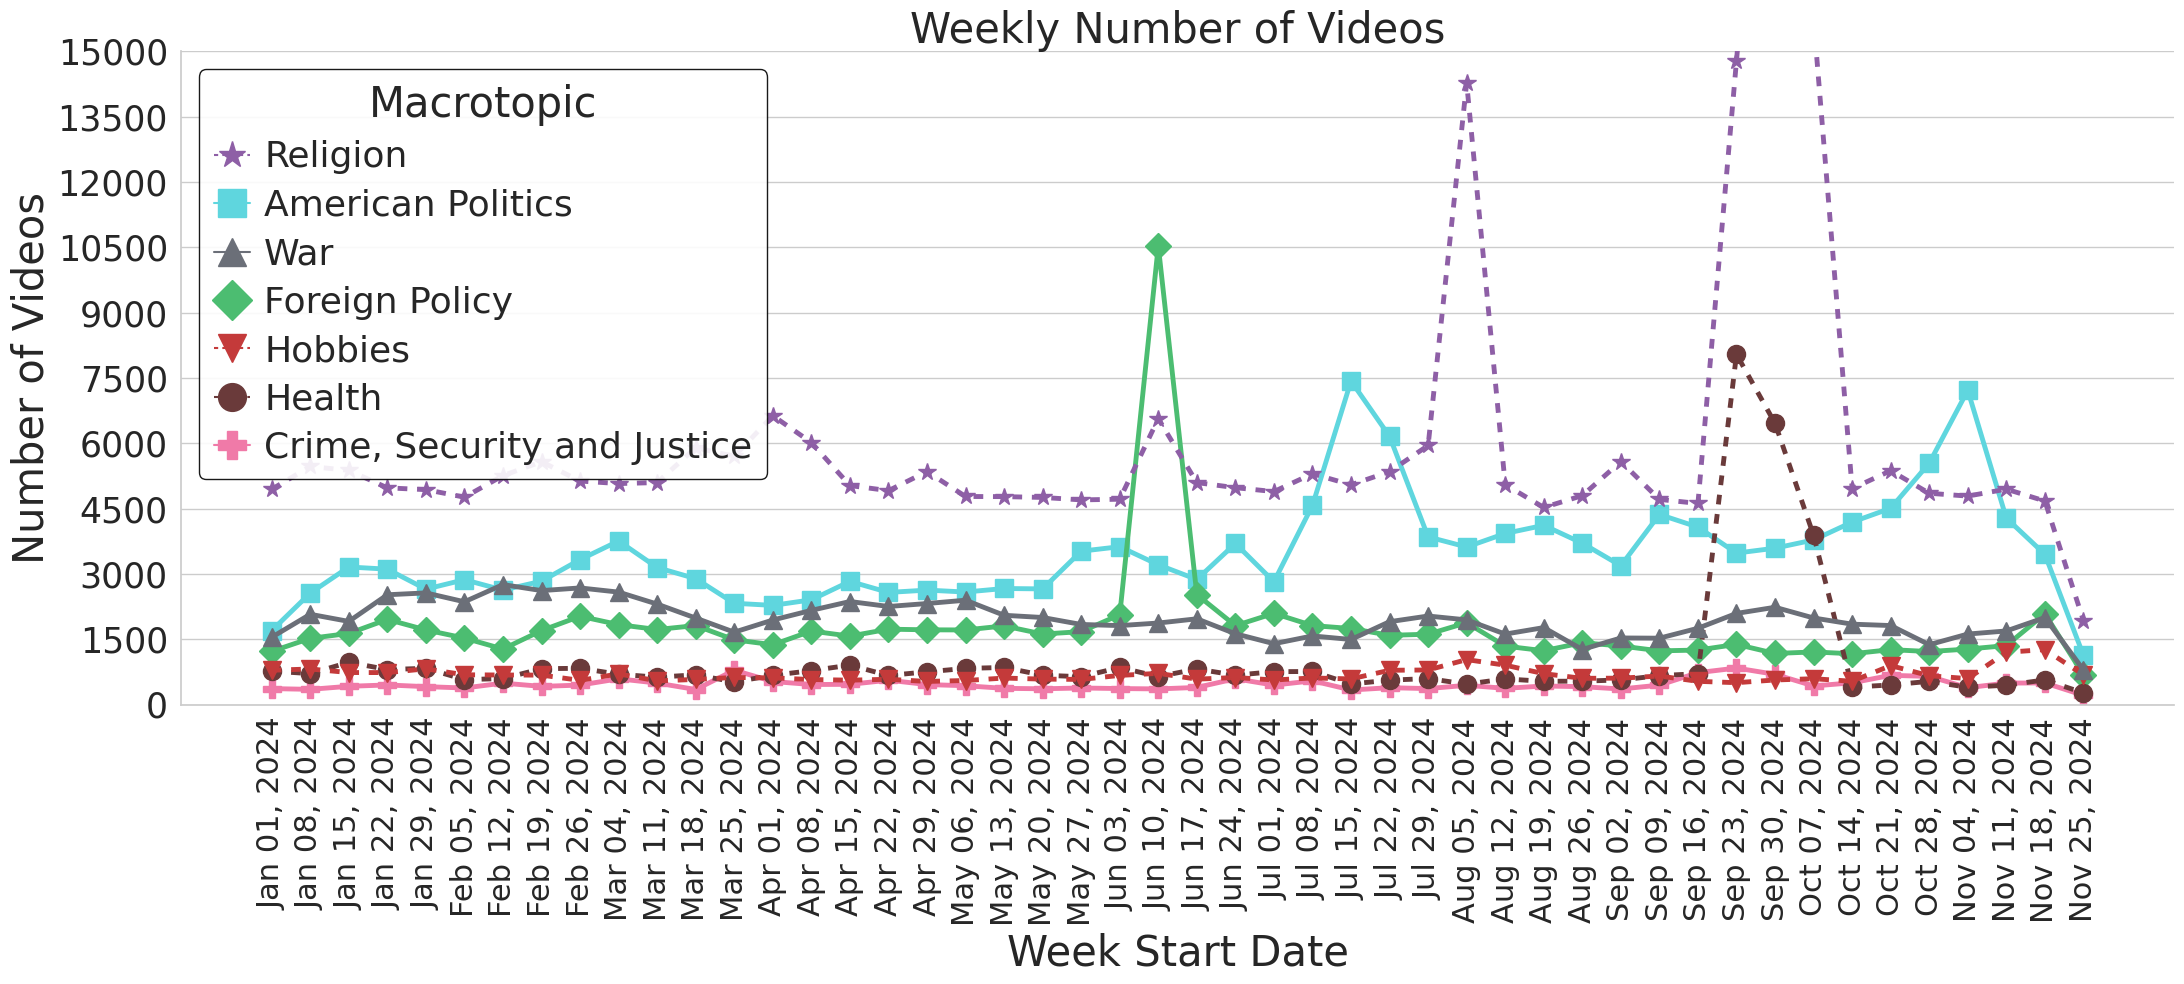

In [233]:
plot_weekly_video_count_macros_v1(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [209]:
def plot_weekly_video_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["video_id", "week_start", "macrotopic_pred"]).copy()

    week_list = sorted(df_unique["week_start"].unique())
    week_map  = {w: i + 1 for i, w in enumerate(week_list)}
    df_unique["week_num"] = df_unique["week_start"].map(week_map)

    grouped = (
        df_unique.groupby(["week_num", "macrotopic_pred"])["video_id"]
        .nunique()
        .reset_index(name="video_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_num")
        last_values[macro] = m_df["video_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis='x', visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_num"],
            m_df["video_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    labels = [w.strftime("%b %d, %Y") for w in week_list]
    plt.xticks(ticks=list(range(1, len(week_list)+1)), labels=labels, rotation=90, fontsize=22)
    plt.yticks(fontsize=25)

    plt.title(f"Weekly Number of Unique Videos", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Number of Unique Videos", fontsize=30)
    lim_y = 4000
    plt.ylim(0, lim_y)
    plt.gca().yaxis.set_major_locator(MultipleLocator(lim_y/10))

    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=20, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    legend = plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=26,
        title_fontsize=30,
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.0,
        handletextpad=0.4
    )

    legend._legend_box.sep = 6

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_unique_video_count.png")
    plt.show()

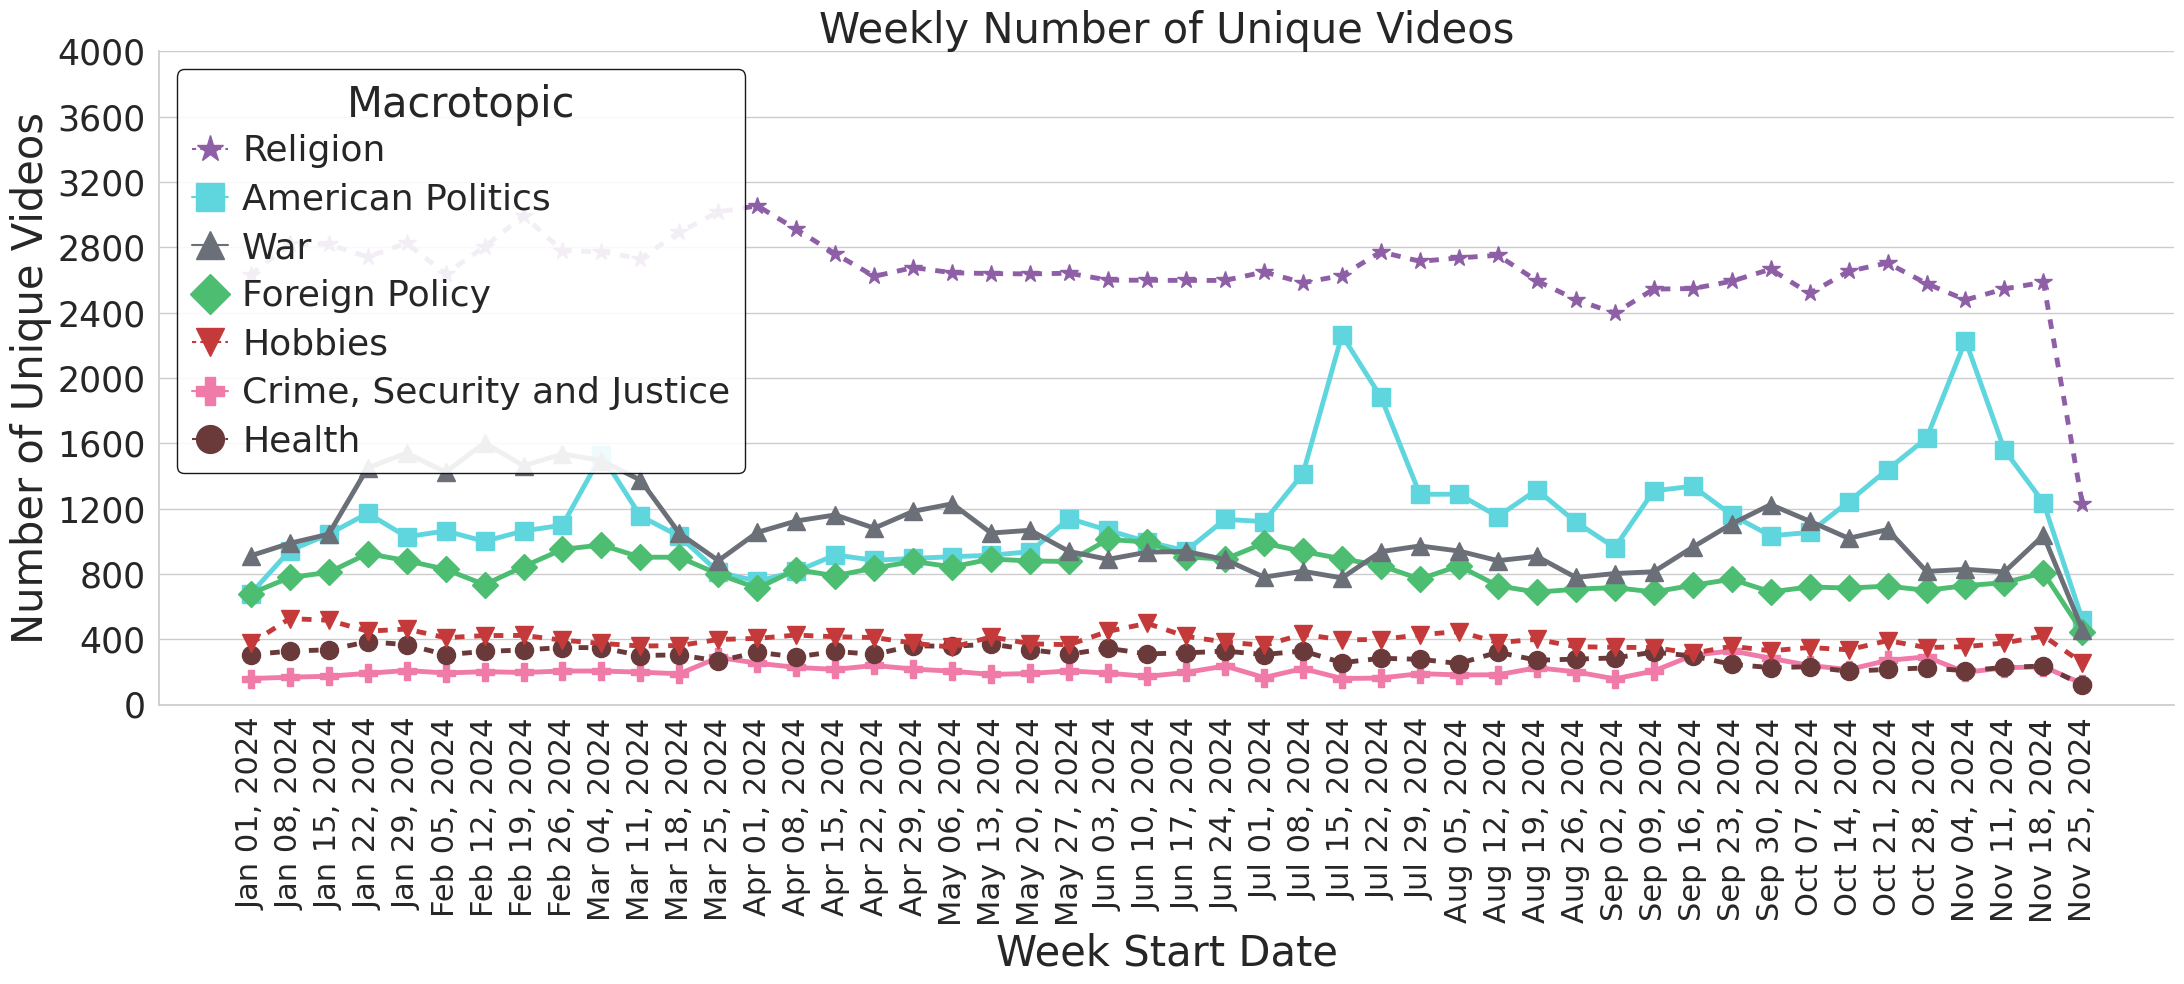

In [210]:
plot_weekly_video_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [211]:
def plot_weekly_channel_count_macros(df, title_label, excluded_topics=None):

    if excluded_topics is None:
        excluded_topics = []

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df = df[~df["macrotopic_pred"].isin(excluded_topics)].copy()

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])

    grouped = (
        df_unique
        .groupby(["week_start", "macrotopic_pred"])["folder"]
        .nunique()
        .reset_index(name="channel_count")
    )

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro].sort_values("week_start")
        last_values[macro] = m_df["channel_count"].iloc[-1] if not m_df.empty else -1

    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis='x', visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(ticks=week_list, labels=labels, rotation=90, fontsize=22)
    plt.yticks(fontsize=25)

    plt.title(f"Weekly Number of Active Channels", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Number of Channels", fontsize=30)

    plt.gca().yaxis.set_major_locator(MultipleLocator(140))
    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=24,
        title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_channel_count.png")
    plt.show()

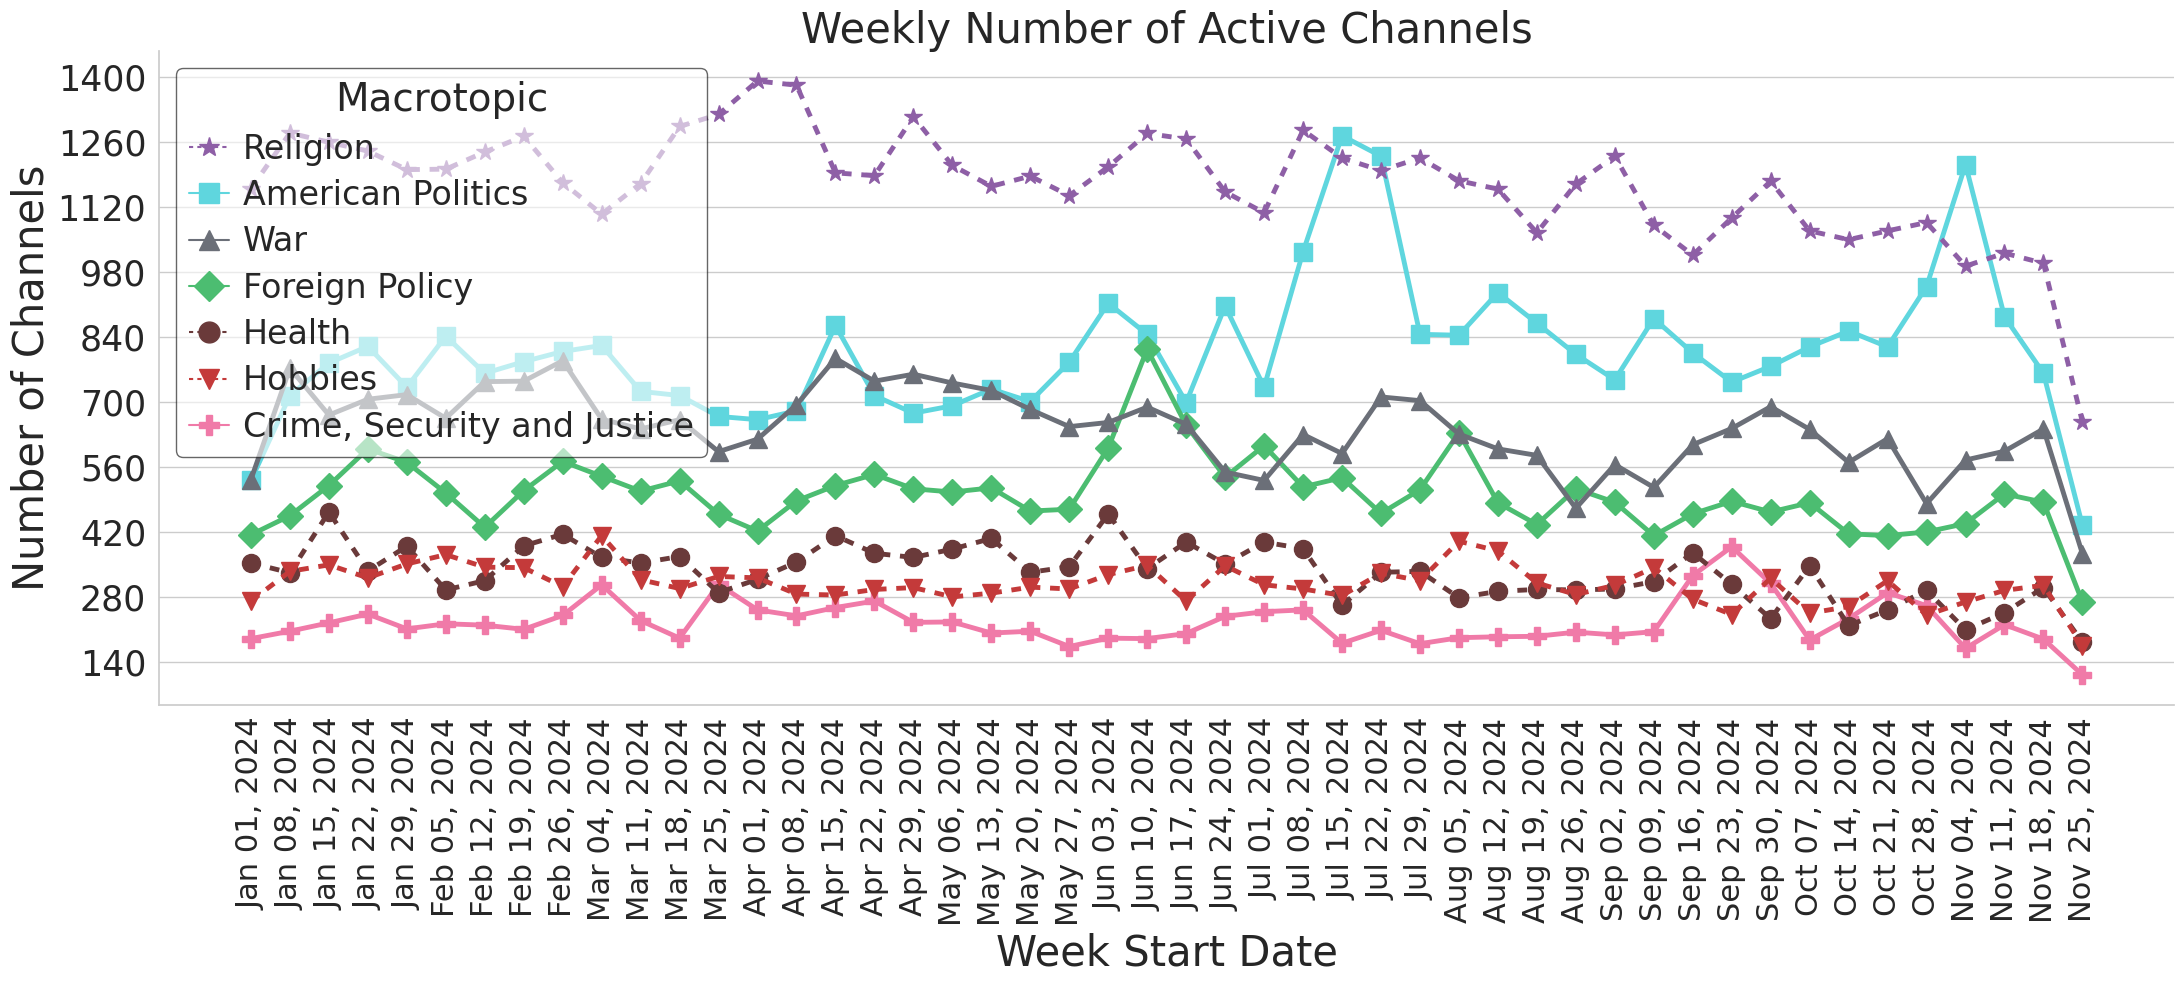

In [212]:
plot_weekly_channel_count_macros(df_complete, "All the data", excluded_topics=["Others", "Technology", "Entertainment", "Environment"]
                               )

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_channel_count_macros_2(df, title_label):
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()


    # início da semana (segunda-feira)
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 garantir uma ocorrência por canal por semana por tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    # Ordenar cronologicamente
    df_unique = df_unique.sort_values("week_start")

    # Tabela acumulativa
    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()
        weekly = []

        for week, w_df in m_df.groupby("week_start"):
            new_channels = set(w_df["folder"]) - seen_channels
            seen_channels |= set(w_df["folder"])

            weekly.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "channel_count": len(seen_channels)   # 🔥 acumulado
            })

        grouped.extend(weekly)

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --- LÓGICA DE ORDENAÇÃO DA LEGENDA (NOVO) ---
    # 1. Identifica o valor acumulado final para cada tópico
    last_values = {}
    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        if not m_df.empty:
            # Como é cumulativo e ordenado por data, o último registro é o máximo
            m_df = m_df.sort_values("week_start")
            last_val = m_df["channel_count"].iloc[-1]
            last_values[macro] = last_val
        else:
            last_values[macro] = -1

    # 2. Cria a lista ordenada (Decrescente pelo valor acumulado)
    macro_categories_sorted = sorted(macro_categories, key=lambda x: last_values.get(x, 0), reverse=True)
    # ---------------------------------------------

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis="x", visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(
            macro, {"color": "#333333", "linestyle": "solid", "marker": "o"}
        )

        plt.plot(
            m_df["week_start"],
            m_df["channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=style.get("markersize", 12),
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(
        ticks=week_list,
        labels=labels,
        rotation=90,
        fontsize=22
    )

    plt.yticks(fontsize=25)

    plt.title(f"Cumulative Number of Unique Channels", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("Cumulative Unique Channels", fontsize=30)
    plt.gca().yaxis.set_major_locator(MultipleLocator(600))

    # 👉 legenda no mesmo padrão do outro gráfico
    handles = [
        Line2D(
            [0], [0],
            color=macro_styles[m]["color"],
            linestyle=macro_styles[m]["linestyle"],
            marker=macro_styles[m]["marker"],
            markersize=macro_styles[m].get("markersize", 12),
            linewidth=macro_styles[m].get("linewidth", 2),
            label=m
        )
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=24,
        title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_cumulative_channel_count.png")
    plt.show()

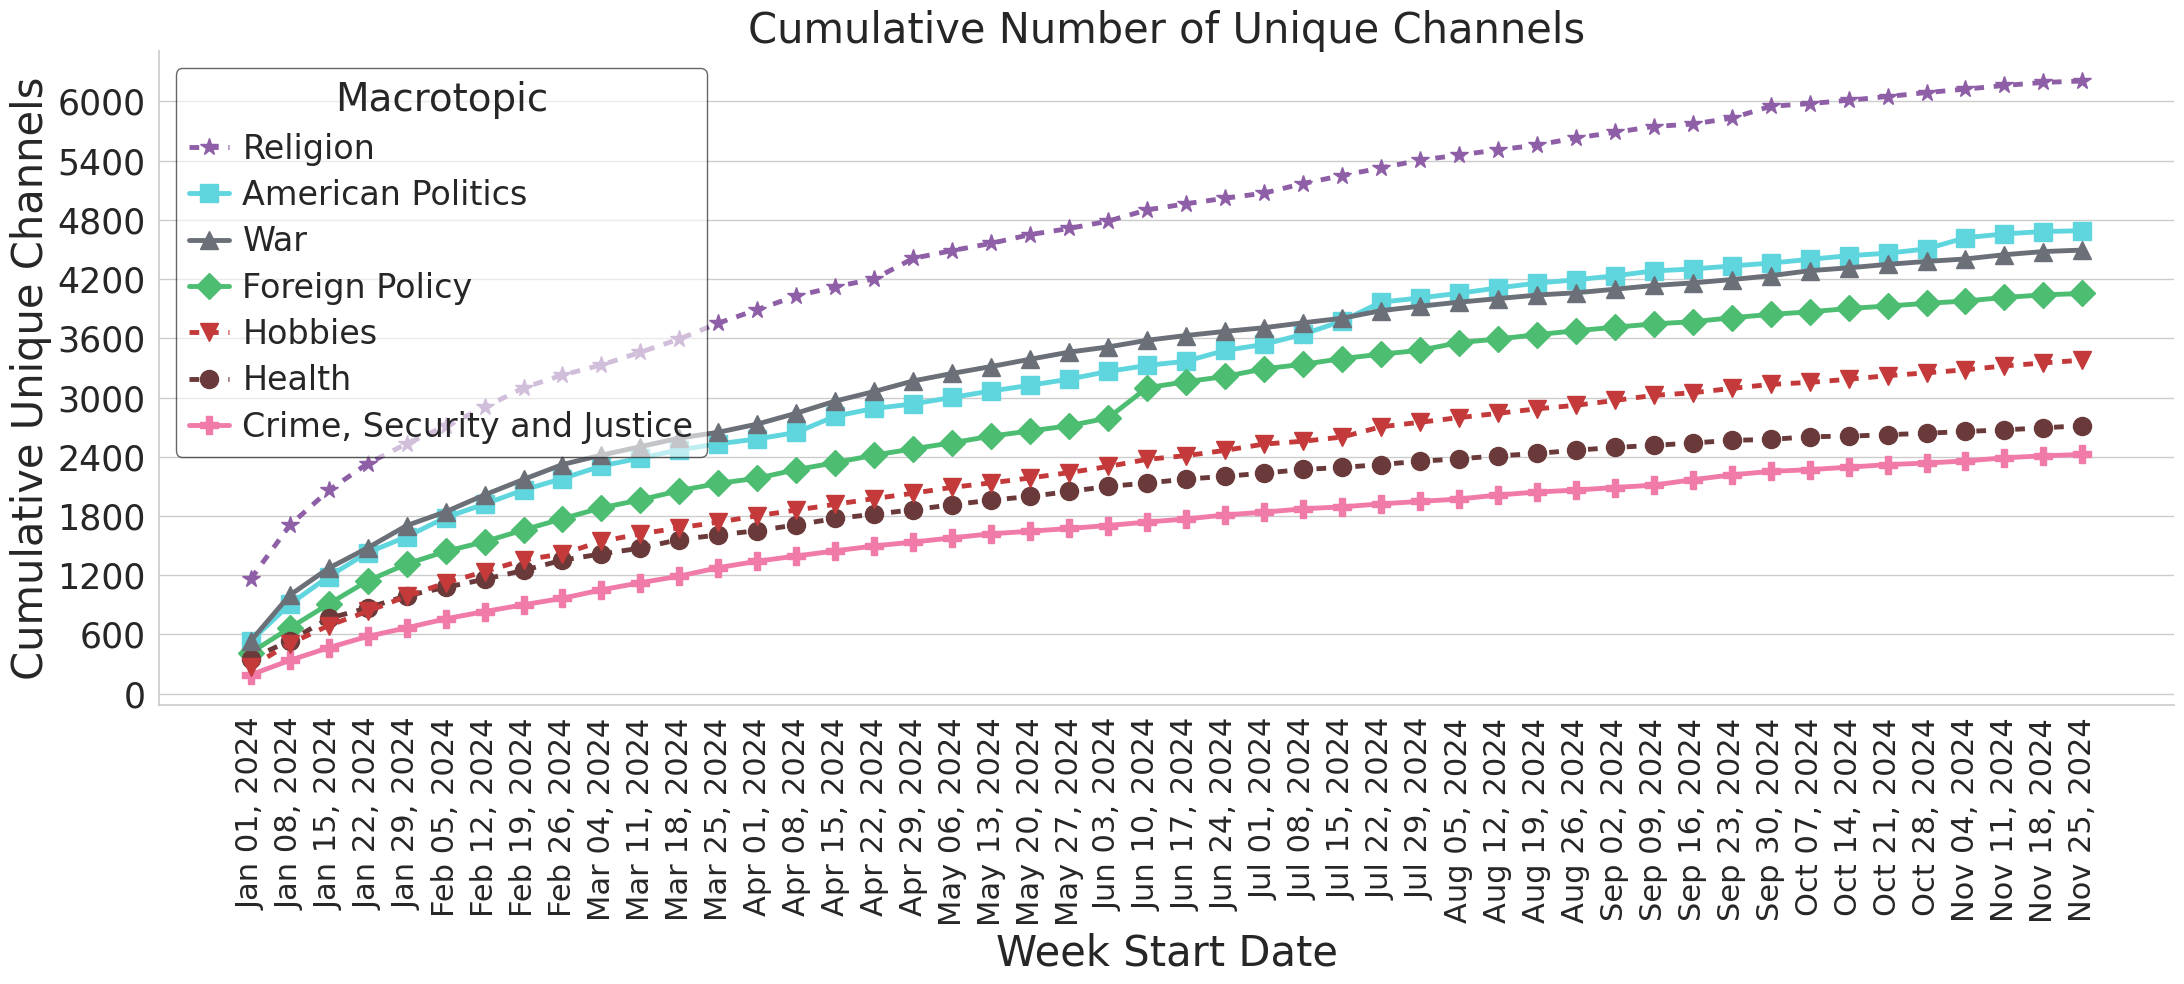

In [72]:
plot_weekly_channel_count_macros_2(df_complete, "All the data")

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import pandas as pd

def plot_weekly_new_channel_count_macros(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    # início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # uma ocorrência por canal / semana / tópico
    df_unique = df.drop_duplicates(
        subset=["folder", "week_start", "macrotopic_pred"]
    )

    df_unique = df_unique.sort_values("week_start")

    grouped = []

    for macro, m_df in df_unique.groupby("macrotopic_pred"):

        seen_channels = set()

        for week, w_df in m_df.groupby("week_start"):

            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels

            seen_channels |= current_channels

            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    # --------- ordenação da legenda (pela soma de novos canais no ano) ---------
    total_new = (
        grouped
        .groupby("macrotopic_pred")["new_channel_count"]
        .sum()
        .to_dict()
    )

    macro_categories_sorted = sorted(
        macro_categories,
        key=lambda x: total_new.get(x, 0),
        reverse=True
    )
    # --------------------------------------------------------------------------

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis='x', visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})

        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(
        ticks=week_list,
        labels=labels,
        rotation=90,
        fontsize=25
    )

    plt.yticks(fontsize=30)

    plt.title(f"Weekly New Unique Channels — {title_label}", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("New Unique Channels", fontsize=30)

    handles = [
        Line2D([0], [0], marker="s", linestyle="",
               color=macro_colors[m], markersize=15, label=m)
        for m in macro_categories_sorted
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=24,
        title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.show()


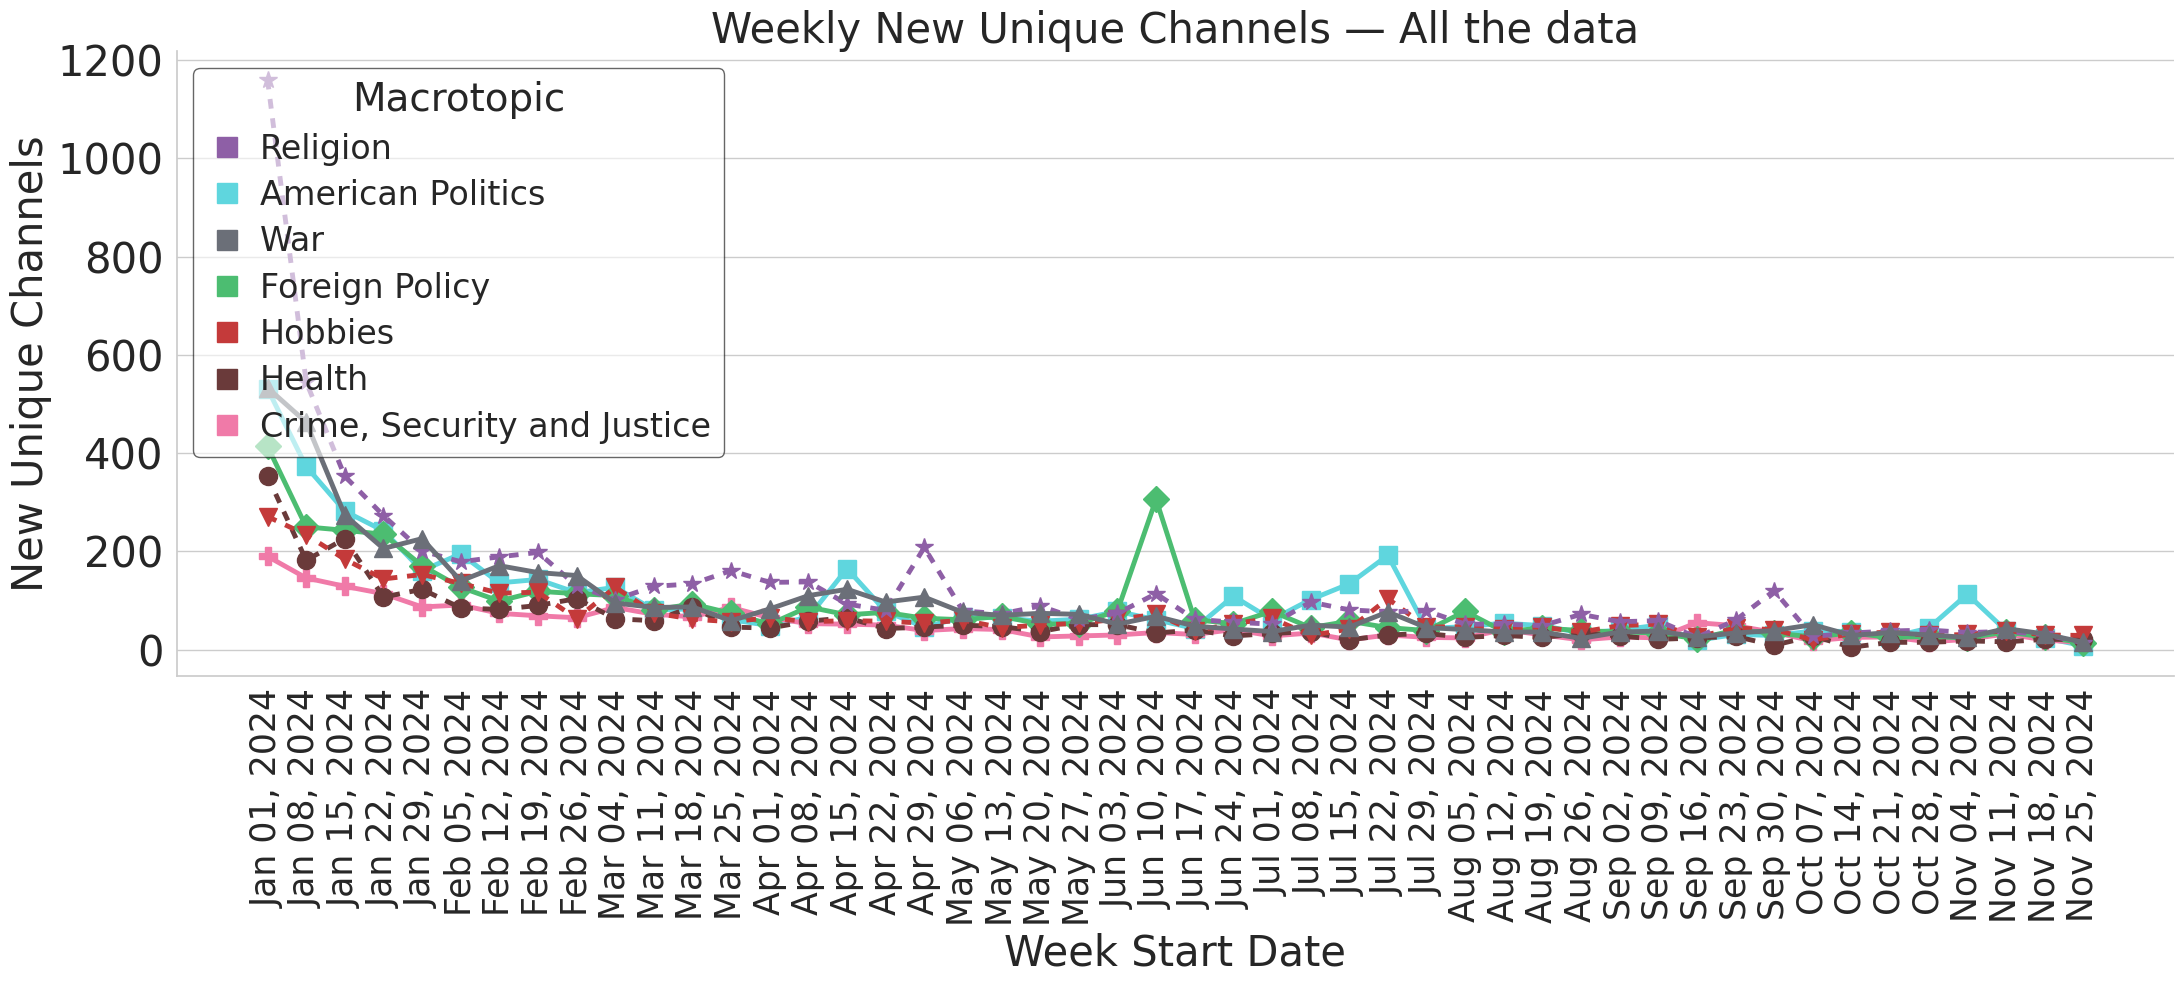

In [166]:
plot_weekly_new_channel_count_macros(df_complete, "All the data")

In [199]:
from matplotlib.ticker import MultipleLocator

def plot_weekly_new_channel_count_macros_zoom(df, title_label):

    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    df_unique = df.drop_duplicates(subset=["folder", "week_start", "macrotopic_pred"])
    df_unique = df_unique.sort_values("week_start")

    grouped = []
    for macro, m_df in df_unique.groupby("macrotopic_pred"):
        seen_channels = set()
        for week, w_df in m_df.groupby("week_start"):
            current_channels = set(w_df["folder"])
            new_channels = current_channels - seen_channels
            seen_channels |= current_channels
            grouped.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_channel_count": len(new_channels)
            })

    grouped = pd.DataFrame(grouped)

    macro_categories = sorted(grouped["macrotopic_pred"].unique())

    total_new = grouped.groupby("macrotopic_pred")["new_channel_count"].sum().to_dict()
    macro_categories_sorted = sorted(macro_categories, key=lambda x: total_new.get(x, 0), reverse=True)

    sns.set(style="whitegrid")
    plt.figure(figsize=(22, 10))
    plt.grid(axis='x', visible=False)

    for macro in macro_categories:
        m_df = grouped[grouped["macrotopic_pred"] == macro]
        style = macro_styles.get(macro, {"color": "#333333", "linestyle": "solid", "marker": "o"})
        plt.plot(
            m_df["week_start"],
            m_df["new_channel_count"],
            color=style["color"],
            linestyle=style["linestyle"],
            markersize=style.get("markersize", 12),
            marker=style["marker"],
            linewidth=style.get("linewidth", 2),
            label=macro
        )

    week_list = sorted(grouped["week_start"].unique())
    labels = [w.strftime("%b %d, %Y") for w in week_list]

    plt.xticks(ticks=week_list, labels=labels, rotation=90, fontsize=25)
    plt.yticks(fontsize=30)

    plt.title(f"Weekly New Unique Channels", fontsize=30)
    plt.xlabel("Week Start Date", fontsize=30)
    plt.ylabel("New Unique Channels", fontsize=30)
    plt.ylim(0, 500)
    plt.gca().yaxis.set_major_locator(MultipleLocator(50))

    handles = [
        Line2D([0], [0],
               color=macro_styles[m]["color"],
               linestyle=macro_styles[m]["linestyle"],
               marker=macro_styles[m]["marker"],
               markersize=15, label=m)
        for m in macro_categories_sorted
        if m in macro_styles
    ]

    plt.legend(
        handles=handles,
        title="Macrotopic",
        fontsize=24,
        title_fontsize=28,
        loc="upper left",
        frameon=True,
        framealpha=0.6,
        facecolor="white",
        edgecolor="black",
        borderpad=0.4,
        labelspacing=0.4,
        handlelength=1.2,
        handletextpad=0.4
    )

    plt.tight_layout()
    sns.despine(top=True, right=True)
    plt.savefig("gráficos/weekly_new_channel_count.png")
    plt.show()

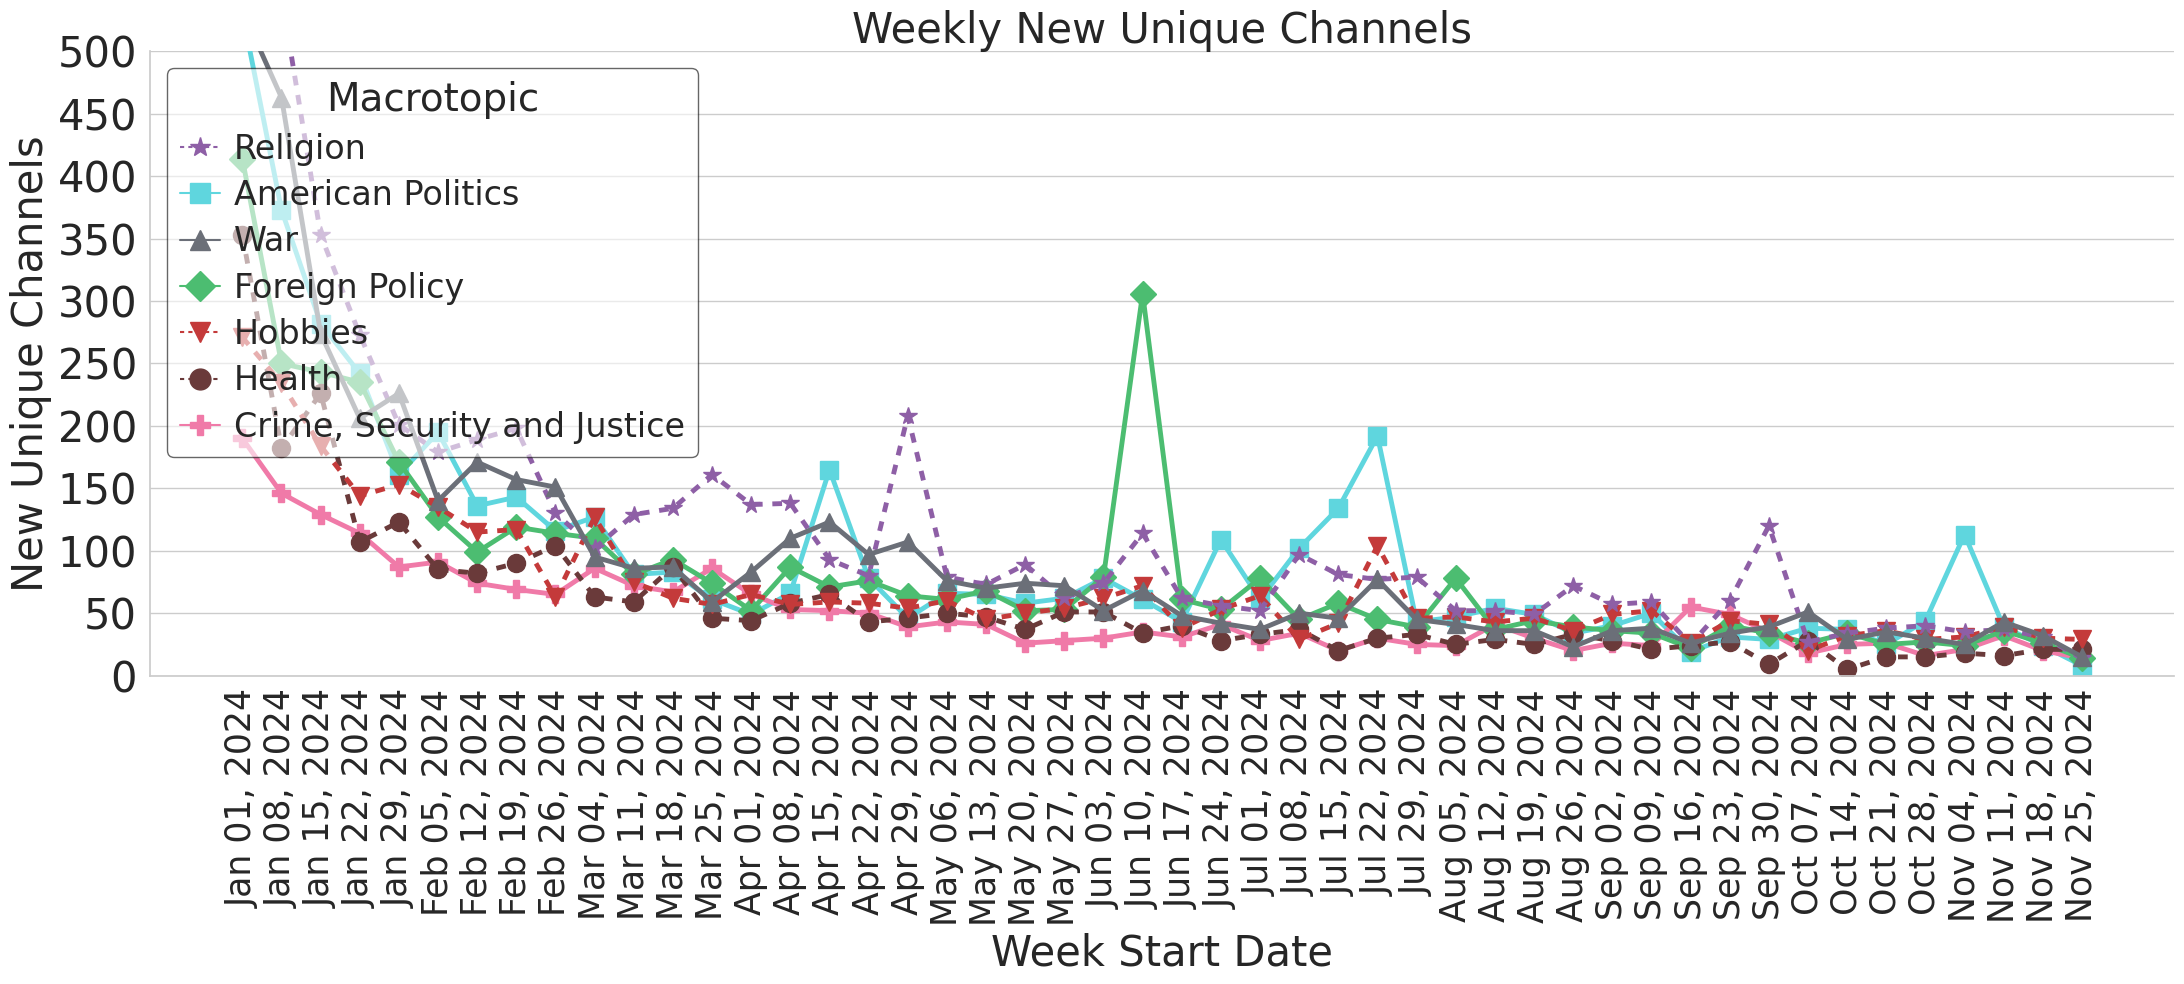

In [200]:
plot_weekly_new_channel_count_macros_zoom(df_complete, "All the data")

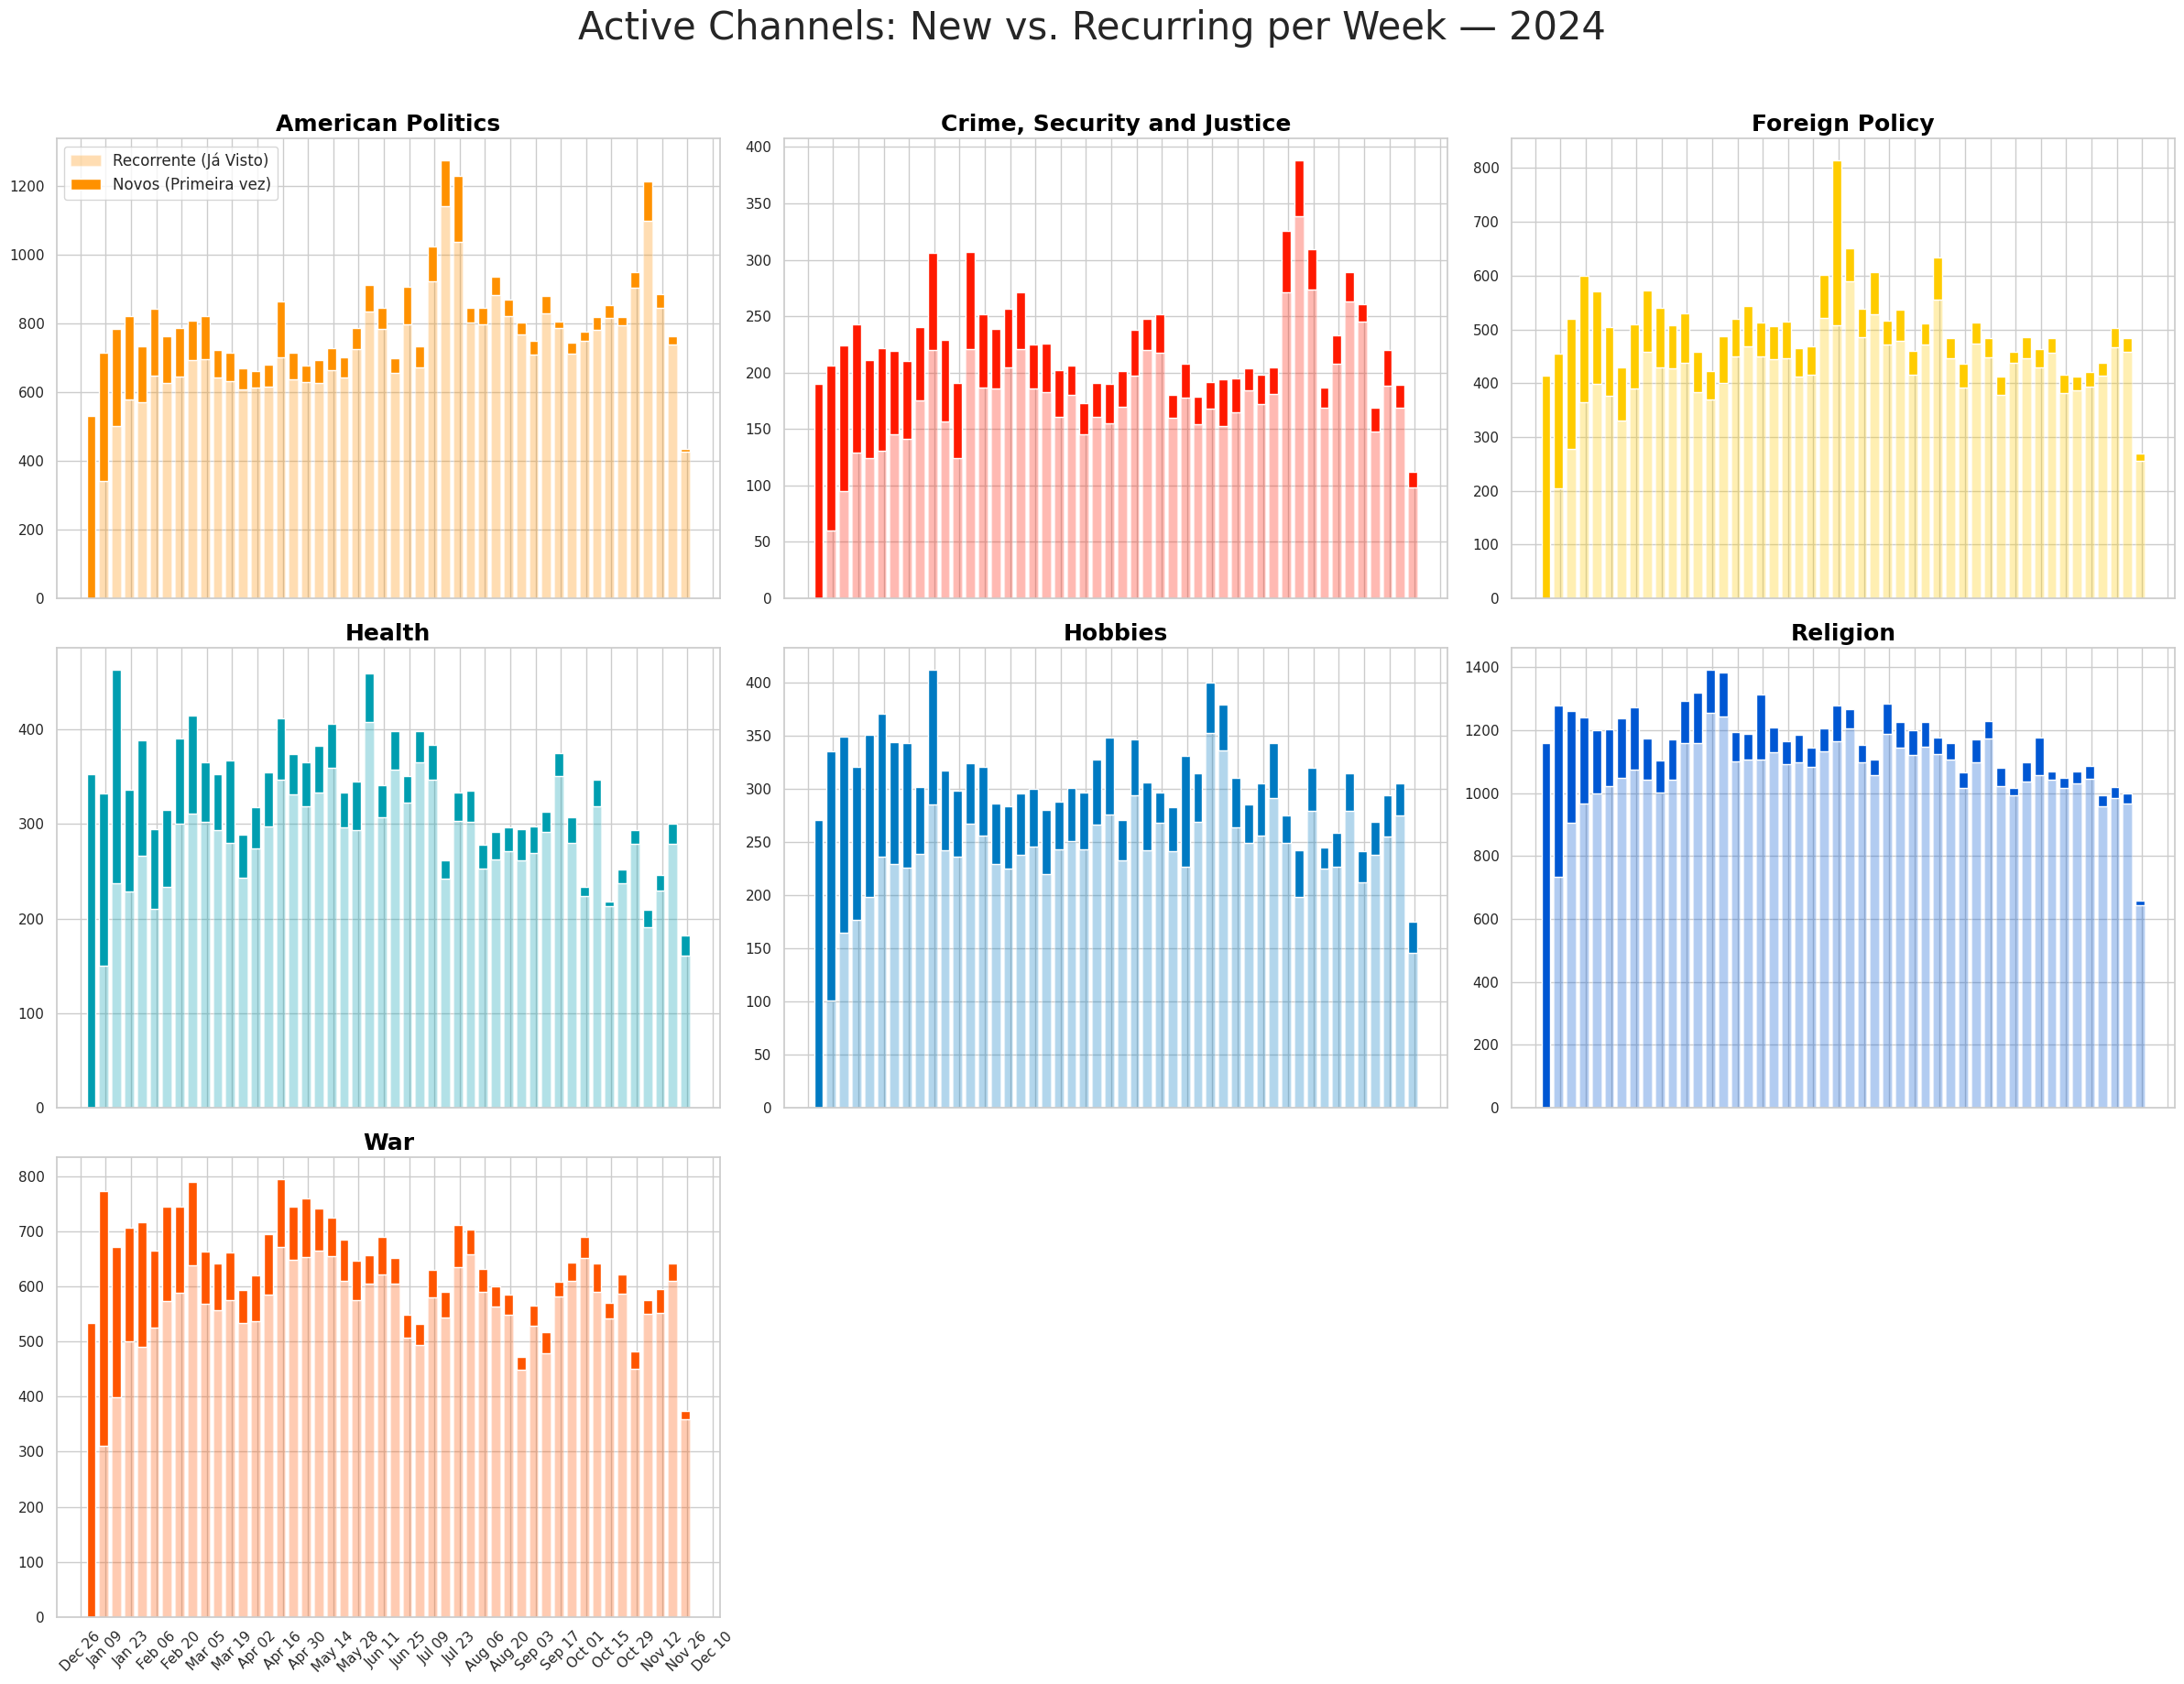

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.dates as mdates

def plot_weekly_new_vs_recurring(df, title_label):
    # --- 1. PREPARAÇÃO DOS DADOS (Igual ao anterior) ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    # Manter apenas 2024
    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    
    # Início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # --- 2. LÓGICA DE NOVOS vs. RECORRENTES ---
    processed_data = []

    # Ordenar cronologicamente é crucial para a lógica de "visto anteriormente"
    df = df.sort_values("week_start")

    for macro, group in df.groupby("macrotopic_pred"):
        seen_channels = set() # Reinicia a memória para cada tópico
        
        # Agrupa por semana dentro do tópico
        for week, week_data in group.groupby("week_start"):
            current_week_channels = set(week_data["folder"])
            
            # Lógica de Conjuntos
            new_channels = current_week_channels - seen_channels
            recurring_channels = current_week_channels.intersection(seen_channels)
            
            # Atualiza a memória de canais vistos
            seen_channels.update(current_week_channels)
            
            processed_data.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_count": len(new_channels),
                "recurring_count": len(recurring_channels),
                "total_active": len(current_week_channels)
            })

    plot_df = pd.DataFrame(processed_data)
    
    if plot_df.empty:
        print("Nenhum dado encontrado para plotar.")
        return

    # --- 3. PLOTAGEM (GRID DE SUBPLOTS) ---
    topics = sorted(plot_df["macrotopic_pred"].unique())
    n_topics = len(topics)
    
    # Define tamanho do grid (ex: 3 colunas)
    cols = 3
    rows = math.ceil(n_topics / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 6), sharex=True)
    axes = axes.flatten() # Facilita iterar se for matriz

    all_weeks = sorted(plot_df["week_start"].unique())

    for i, topic in enumerate(topics):
        ax = axes[i]
        subset = plot_df[plot_df["macrotopic_pred"] == topic]
        
        # Garante que todas as semanas apareçam, preenchendo com 0 se não houver dados
        subset = subset.set_index("week_start").reindex(all_weeks).fillna(0).reset_index()
        
        # Cor base do tópico
        topic_color = macro_colors.get(topic, "#333333")
        
        # Plota Barra de Recorrentes (Base) - Cor mais transparente/clara
        ax.bar(subset["week_start"], subset["recurring_count"], 
               label="Recorrente (Já Visto)", color=topic_color, alpha=0.3, width=5)
        
        # Plota Barra de Novos (Topo) - Cor sólida
        # O parametro 'bottom' faz a barra ficar em cima da anterior
        ax.bar(subset["week_start"], subset["new_count"], bottom=subset["recurring_count"],
               label="Novos (Primeira vez)", color=topic_color, alpha=1.0, width=5)
        
        ax.set_title(topic, fontsize=18, fontweight='bold', color='black')
        
        # Formatação do Eixo X apenas na última linha (opcional, ou em todos)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2)) # A cada 2 semanas
        ax.tick_params(axis='x', rotation=45)

        # Adiciona legenda apenas no primeiro gráfico para não poluir
        if i == 0:
            ax.legend(loc='upper left', fontsize=12)

    # Remove eixos vazios se houver
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Active Channels: New vs. Recurring per Week — {title_label}", fontsize=30, y=1.02)
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
plot_weekly_new_vs_recurring(df_complete,"2024")

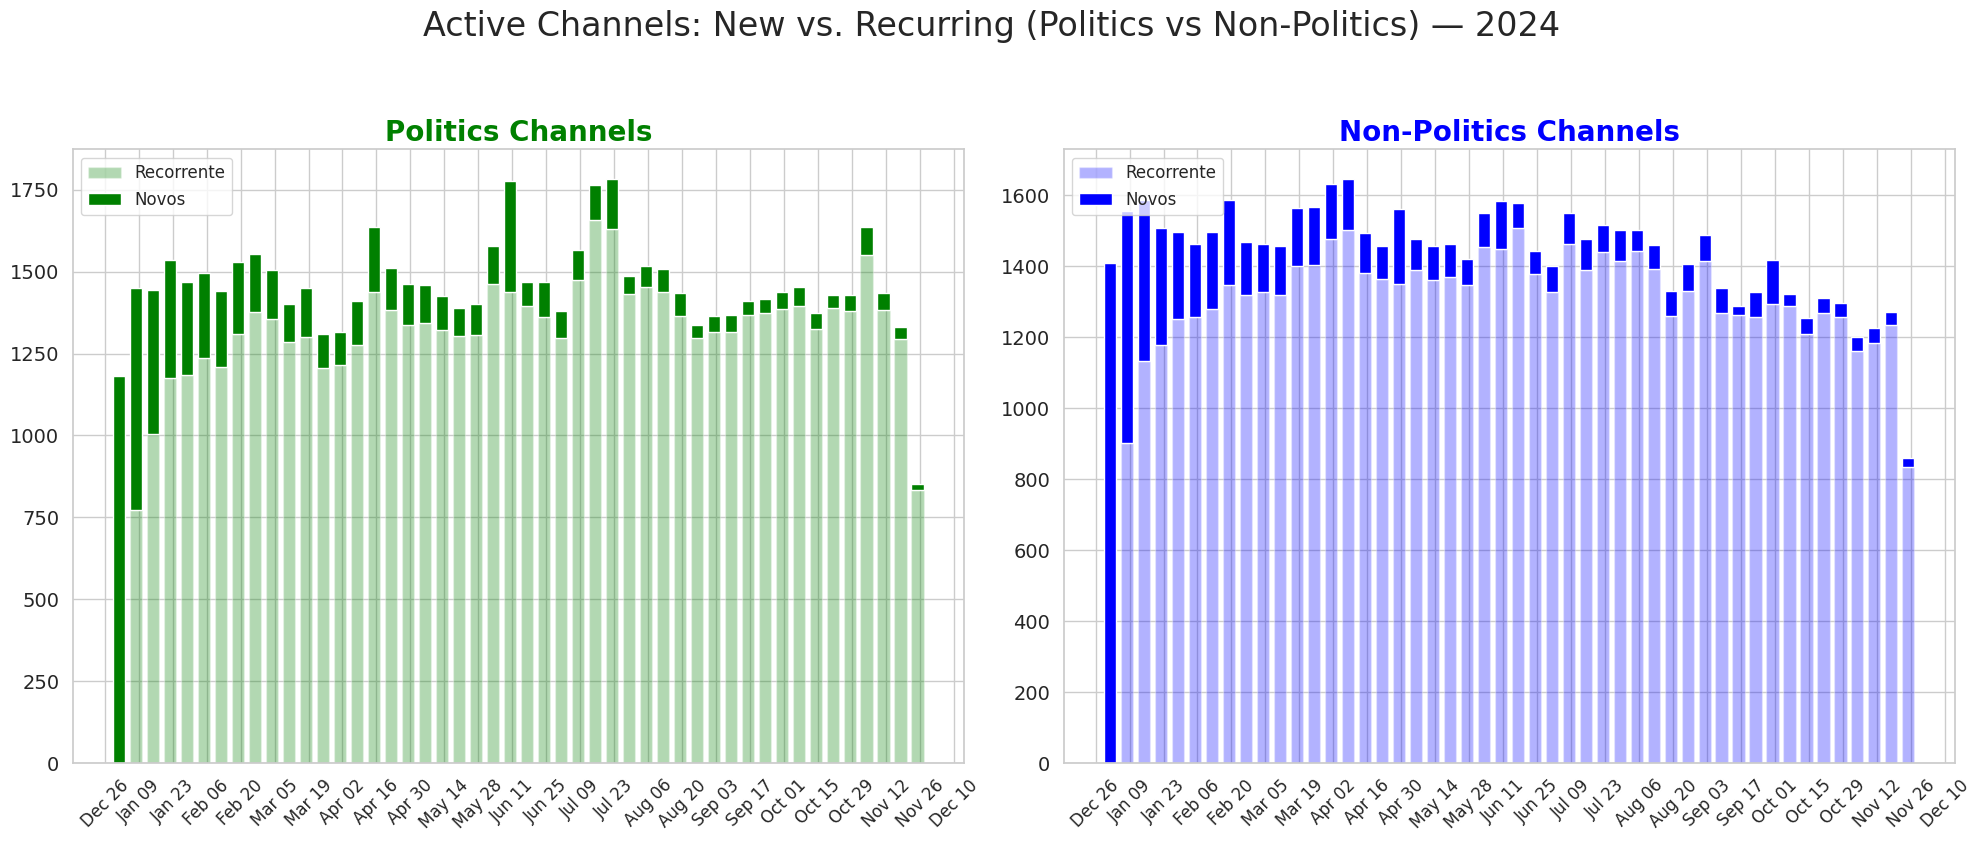

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_weekly_new_vs_recurring_by_category(df, title_label):

    # Função auxiliar para mapear o tópico para a categoria
    def get_category(topic):
        if topic in politics:
            return "Politics"
        elif topic in non_politics:
            return "Non-Politics"
        return None # Ignora se não estiver nas listas

    # Cores das Categorias
    category_colors = {
        "Politics": "green",
        "Non-Politics": "blue"
    }

    # --- 2. PREPARAÇÃO DOS DADOS ---
    df = df.dropna(subset=["macrotopic_pred", "folder"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    
    # Início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 Cria a coluna de Categoria (Politics vs Non-Politics)
    df["category_type"] = df["macrotopic_pred"].apply(get_category)
    
    # Remove o que não entrou em nenhuma categoria (None)
    df = df.dropna(subset=["category_type"])

    # --- 3. LÓGICA DE NOVOS vs. RECORRENTES (AGRUPADO POR CATEGORIA) ---
    processed_data = []

    # Ordenar cronologicamente
    df = df.sort_values("week_start")

    # 🔥 Agora agrupamos por 'category_type' em vez de 'macrotopic_pred'
    for category, group in df.groupby("category_type"):
        seen_channels = set() 
        
        for week, week_data in group.groupby("week_start"):
            current_week_channels = set(week_data["folder"])
            
            # Lógica de Conjuntos
            new_channels = current_week_channels - seen_channels
            recurring_channels = current_week_channels.intersection(seen_channels)
            
            seen_channels.update(current_week_channels)
            
            processed_data.append({
                "week_start": week,
                "category_type": category,
                "new_count": len(new_channels),
                "recurring_count": len(recurring_channels)
            })

    plot_df = pd.DataFrame(processed_data)
    
    if plot_df.empty:
        print("Nenhum dado encontrado.")
        return

    # --- 4. PLOTAGEM (2 SUBPLOTS LADO A LADO) ---
    categories = ["Politics", "Non-Politics"] # Ordem fixa para consistência
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True)
    
    all_weeks = sorted(plot_df["week_start"].unique())

    for i, category in enumerate(categories):
        ax = axes[i]
        subset = plot_df[plot_df["category_type"] == category]
        
        # Garante integridade das datas
        subset = subset.set_index("week_start").reindex(all_weeks).fillna(0).reset_index()
        
        base_color = category_colors.get(category, "gray")
        
        # Barra Recorrente (Base) - Transparente
        ax.bar(subset["week_start"], subset["recurring_count"], 
               label="Recorrente", color=base_color, alpha=0.3, width=5)
        
        # Barra Novos (Topo) - Sólida
        ax.bar(subset["week_start"], subset["new_count"], bottom=subset["recurring_count"],
               label="Novos", color=base_color, alpha=1.0, width=5)
        
        ax.set_title(f"{category} Channels", fontsize=20, fontweight='bold', color=base_color)
        
        # Formatação Eixo X
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        ax.tick_params(axis='y', labelsize=14)
        
        # Legenda individual para explicar o alpha
        ax.legend(loc='upper left', fontsize=12)

    plt.suptitle(f"Active Channels: New vs. Recurring (Politics vs Non-Politics) — {title_label}", fontsize=24, y=1.05)
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
plot_weekly_new_vs_recurring_by_category(df_complete, "2024")

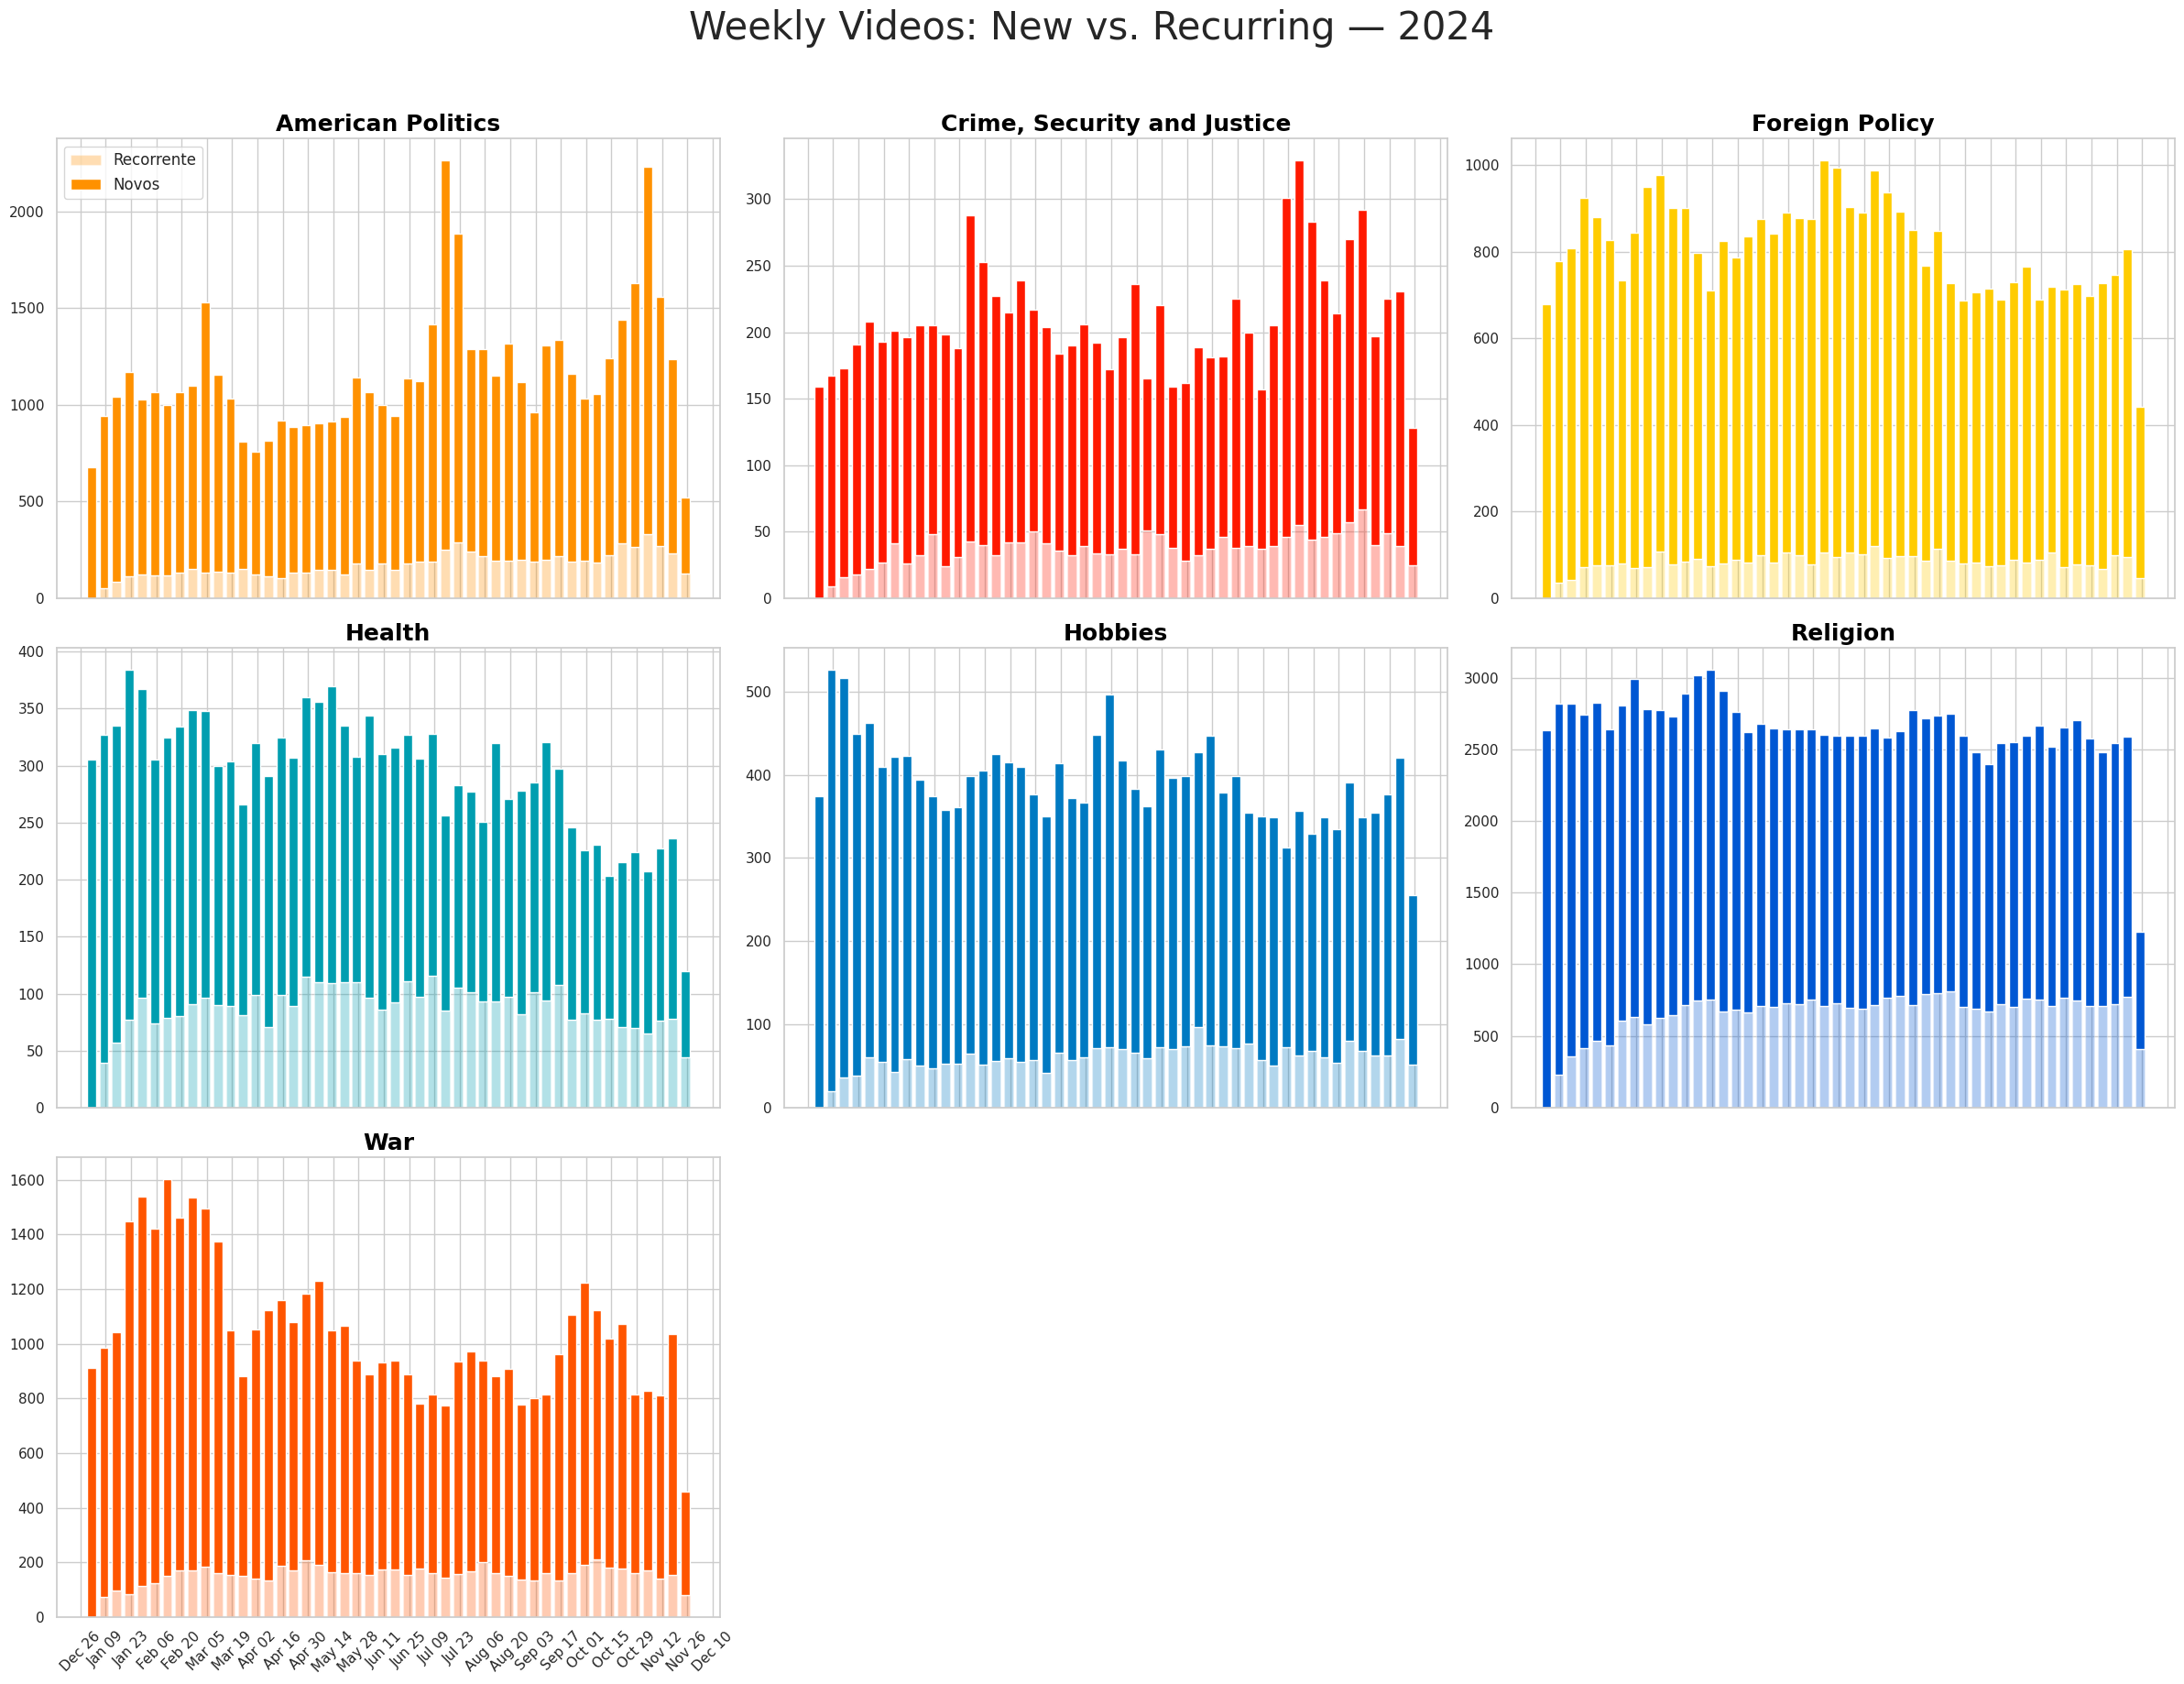

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import matplotlib.dates as mdates

def plot_weekly_new_vs_recurring_videos(df, title_label):

    # --- 1. PREPARAÇÃO DOS DADOS ---
    # Garantimos que temos video_id e macrotopico
    df = df.dropna(subset=["macrotopic_pred", "video_id"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    # Manter apenas 2024
    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    
    # Início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    processed_data = []

    # Ordenar cronologicamente
    df = df.sort_values("week_start")

    for macro, group in df.groupby("macrotopic_pred"):
        seen_videos = set() # Memória de VÍDEOS já vistos
        
        # Agrupa por semana dentro do tópico
        for week, week_data in group.groupby("week_start"):
            # Conjunto de vídeos únicos nesta semana específica
            current_week_videos = set(week_data["video_id"])
            
            # Lógica de Conjuntos
            # Novo: Vídeo que nunca apareceu antes no ano
            new_videos = current_week_videos - seen_videos
            
            # Recorrente: Vídeo que já apareceu em semanas anteriores e voltou a aparecer nesta
            recurring_videos = current_week_videos.intersection(seen_videos)
            
            # Atualiza a memória de vídeos vistos
            seen_videos.update(current_week_videos)
            
            processed_data.append({
                "week_start": week,
                "macrotopic_pred": macro,
                "new_count": len(new_videos),
                "recurring_count": len(recurring_videos),
                "total_active": len(current_week_videos)
            })

    plot_df = pd.DataFrame(processed_data)
    
    if plot_df.empty:
        print("Nenhum dado encontrado para plotar.")
        return

    # --- 3. PLOTAGEM (GRID DE SUBPLOTS) ---
    topics = sorted(plot_df["macrotopic_pred"].unique())
    n_topics = len(topics)
    
    cols = 3
    rows = math.ceil(n_topics / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(24, rows * 6), sharex=True)
    axes = axes.flatten()

    all_weeks = sorted(plot_df["week_start"].unique())

    for i, topic in enumerate(topics):
        ax = axes[i]
        subset = plot_df[plot_df["macrotopic_pred"] == topic]
        
        subset = subset.set_index("week_start").reindex(all_weeks).fillna(0).reset_index()
        
        topic_color = macro_colors.get(topic, "#333333")
        
        # Barra Recorrente (Base)
        ax.bar(subset["week_start"], subset["recurring_count"], 
               label="Recorrente", color=topic_color, alpha=0.3, width=5)
        
        # Barra Novos (Topo)
        ax.bar(subset["week_start"], subset["new_count"], bottom=subset["recurring_count"],
               label="Novos", color=topic_color, alpha=1.0, width=5)
        
        ax.set_title(topic, fontsize=18, fontweight='bold', color='black')
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.tick_params(axis='x', rotation=45)

        if i == 0:
            ax.legend(loc='upper left', fontsize=12)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(f"Weekly Videos: New vs. Recurring — {title_label}", fontsize=30, y=1.02)
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
plot_weekly_new_vs_recurring_videos(df_complete, "2024")

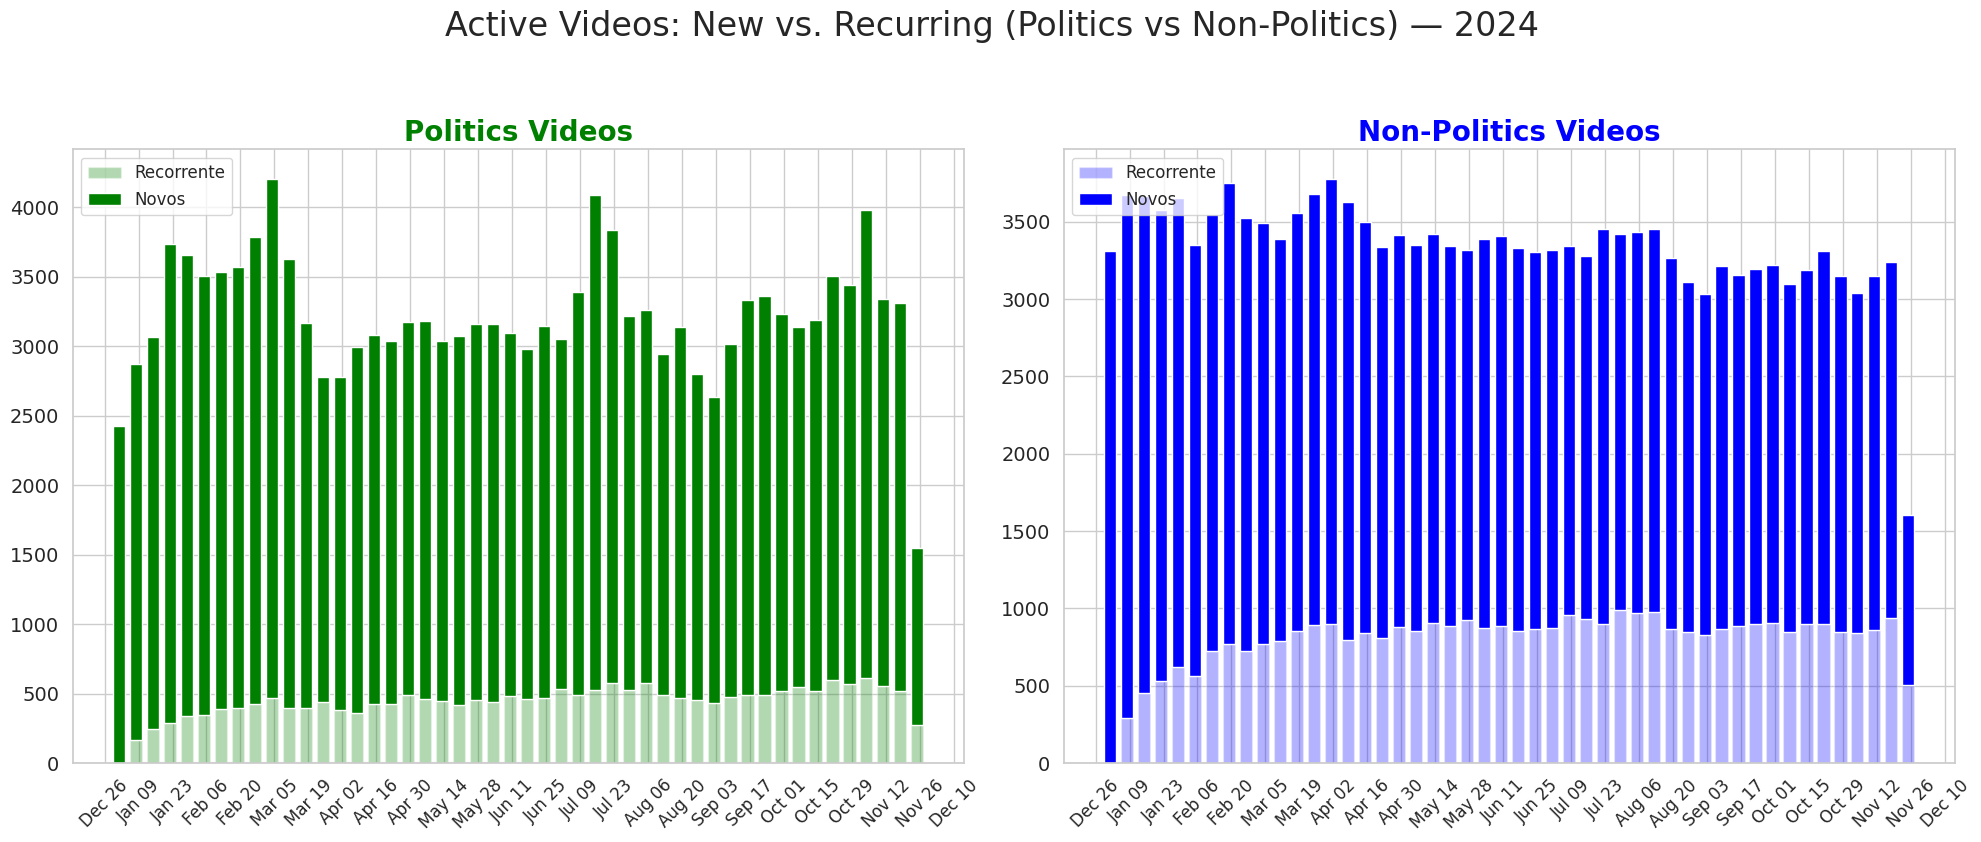

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_weekly_new_vs_recurring_videos_by_category(df, title_label):
    
    # Função auxiliar para mapear o tópico para a categoria
    def get_category(topic):
        if topic in politics:
            return "Politics"
        elif topic in non_politics:
            return "Non-Politics"
        return None 

    # Cores das Categorias
    category_colors = {
        "Politics": "green",
        "Non-Politics": "blue"
    }

    # --- 2. PREPARAÇÃO DOS DADOS ---
    # 🔥 Importante: Garantir que video_id não é nulo
    df = df.dropna(subset=["macrotopic_pred", "video_id"]).copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    
    # manter apenas janeiro → novembro de 2024
    df = df[
        (df["date"] >= "2024-01-01") &
        (df["date"] <  "2024-12-01")
    ].copy()

    
    # Início da semana
    df["week_start"] = df["date"].dt.to_period("W").dt.start_time
    df = df.dropna(subset=["week_start"])

    # 🔥 Cria a coluna de Categoria
    df["category_type"] = df["macrotopic_pred"].apply(get_category)
    
    # Remove o que não entrou em nenhuma categoria
    df = df.dropna(subset=["category_type"])

    # --- 3. LÓGICA DE NOVOS vs. RECORRENTES (AGRUPADO POR CATEGORIA) ---
    processed_data = []

    # Ordenar cronologicamente
    df = df.sort_values("week_start")

    # 🔥 Agrupamos por 'category_type'
    for category, group in df.groupby("category_type"):
        seen_videos = set() # Memória de VÍDEOS já vistos nesta categoria
        
        for week, week_data in group.groupby("week_start"):
            # Conjunto de IDs de vídeos únicos nesta semana
            current_week_videos = set(week_data["video_id"])
            
            # Lógica de Conjuntos
            # Novo: Vídeo que nunca apareceu antes nesta categoria
            new_videos = current_week_videos - seen_videos
            
            # Recorrente: Vídeo que já apareceu antes e continua circulando
            recurring_videos = current_week_videos.intersection(seen_videos)
            
            # Atualiza a memória
            seen_videos.update(current_week_videos)
            
            processed_data.append({
                "week_start": week,
                "category_type": category,
                "new_count": len(new_videos),
                "recurring_count": len(recurring_videos)
            })

    plot_df = pd.DataFrame(processed_data)
    
    if plot_df.empty:
        print("Nenhum dado encontrado.")
        return

    # --- 4. PLOTAGEM (2 SUBPLOTS LADO A LADO) ---
    categories = ["Politics", "Non-Politics"] 
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True)
    
    all_weeks = sorted(plot_df["week_start"].unique())

    for i, category in enumerate(categories):
        ax = axes[i]
        subset = plot_df[plot_df["category_type"] == category]
        
        # Garante integridade das datas
        subset = subset.set_index("week_start").reindex(all_weeks).fillna(0).reset_index()
        
        base_color = category_colors.get(category, "gray")
        
        # Barra Recorrente (Base) - Transparente
        # Representa vídeos antigos que ainda estão sendo compartilhados (Viralidade)
        ax.bar(subset["week_start"], subset["recurring_count"], 
               label="Recorrente", color=base_color, alpha=0.3, width=5)
        
        # Barra Novos (Topo) - Sólida
        # Representa vídeos frescos, recém-criados ou recém-chegados
        ax.bar(subset["week_start"], subset["new_count"], bottom=subset["recurring_count"],
               label="Novos", color=base_color, alpha=1.0, width=5)
        
        ax.set_title(f"{category} Videos", fontsize=20, fontweight='bold', color=base_color)
        
        # Formatação Eixo X
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.tick_params(axis='x', rotation=45, labelsize=12)
        ax.tick_params(axis='y', labelsize=14)
        
        ax.legend(loc='upper left', fontsize=12)

    plt.suptitle(f"Active Videos: New vs. Recurring (Politics vs Non-Politics) — {title_label}", fontsize=24, y=1.05)
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
plot_weekly_new_vs_recurring_videos_by_category(df_complete, "2024")